# Data Injection #
**Description**
This Jupyter notebook is used to inject Data in excel or CSV format into firebase DB 

In [90]:

!pip install pandas --quiet
!pip install geopy --quiet
!pip -q install pycountry --quiet

In [91]:

import pandas as pd
import re
import numpy as np
import pandas as pd
import pycountry
import matplotlib.pyplot as plt
data_path = './dataset'


## Feature Engineering Configuration

Configuration constants for comprehensive feature engineering pipeline.

## Load the Transport Cost Data


In [92]:
# TRANSPORT_PATH = f"{data_path}/TransportCosts.csv"
TRANSPORT_PATH = f"{data_path}/transport_cost_by_product.csv"
LSCI_PATH      = f"{data_path}/LSCI.csv"
LSBCI_PATH     = f"{data_path}/LSBCI.csv"
DIST_PATH      = f"{data_path}/dist_cepii.csv"
FUEL_PATH      = f"{data_path}/Daily_Bunker_Fuel_Prices.csv"


In [ ]:
# -------------------------
# (B) ISO3 mapping helper
# -------------------------
manual_iso3 = {
  'Brunei Darussalam': 'BRN',
  'Cabo Verde': 'CPV',
  'China, Hong Kong SAR': 'HKG',
  'China, Macao SAR': 'MAC',
  'China, Taiwan Province of': 'TWN',
  'Congo, Dem. Rep. of the': 'COD',
  "Cote d'Ivoire": 'CIV',
  'Curaçao': 'CUW',
  'Curacao': 'CUW',
  'Eswatini': 'SWZ',
  "Korea, Dem. People's Rep. of": 'PRK',
  "Lao People's Dem. Rep.": 'LAO',
  'Netherlands (Kingdom of the)': 'NLD',
  'Russian Federation': 'RUS',
  'State of Palestine': 'PSE',
  'Türkiye': 'TUR',
  'Turkiye': 'TUR',
  'Venezuela (Bolivarian Rep. of)': 'VEN',
  'Viet Nam': 'VNM',
  'Bolivia (Plurinational State of)': 'BOL',
  'Iran (Islamic Republic of)': 'IRN',
  'Syrian Arab Republic': 'SYR',
  'United Republic of Tanzania': 'TZA',
  'Micronesia (Federated States of)': 'FSM',
  'Dem. Rep. of the Congo': 'COD',
  'Democratic Republic of the Congo': 'COD',
  "Côte d'Ivoire": 'CIV',
  "Côte d'Ivoire": 'CIV',
}

def to_iso3(label: str):
    if pd.isna(label):
        return None
    s = str(label).strip()
    if s in manual_iso3:
        return manual_iso3[s]
    # minimal normalization
    repl = {
        "Côte d'Ivoire": "Cote d'Ivoire",
        "Côte d'Ivoire": "Cote d'Ivoire",
    }
    s2 = repl.get(s, s)
    try:
        return pycountry.countries.lookup(s2).alpha_3
    except Exception:
        return None

# -------------------------
# (C) Load + melt transport costs (wide -> long)
# -------------------------
YEAR_RE = re.compile(r"(20\d{2})_Advalorem_freight_rate_Value")

t = pd.read_csv(TRANSPORT_PATH)
year_cols = [c for c in t.columns if YEAR_RE.search(c)]
t.head()
if not year_cols:
    raise ValueError("No year columns matched pattern: 20xx_Advalorem_freight_rate_Value")

df_long = t.melt(
    id_vars=["Origin_Label","Destination_Label","Product_Code","Product_Label"],
    value_vars=year_cols,
    var_name="YearCol",
    value_name="Advalorem_freight_rate_Value"
)
df_long["Year"] = df_long["YearCol"].str.extract(r"(20\d{2})").astype(int)
df_long.drop(columns=["YearCol"], inplace=True)

df_obs = df_long.dropna(subset=["Advalorem_freight_rate_Value"]).copy()
df_obs["Advalorem_freight_rate_Value"] = pd.to_numeric(df_obs["Advalorem_freight_rate_Value"], errors="coerce")
df_obs = df_obs.dropna(subset=["Advalorem_freight_rate_Value"])
df_obs = df_obs[df_obs["Advalorem_freight_rate_Value"] >= 0].copy()
df_obs["y_log"] = np.log1p(df_obs["Advalorem_freight_rate_Value"])

# ISO codes for joining externals
df_obs["iso_o"] = df_obs["Origin_Label"].map(to_iso3)
df_obs["iso_d"] = df_obs["Destination_Label"].map(to_iso3)

df_obs

## Show Missing Destination Countries


In [ ]:

# Get unique country sets from origin and destination
orig_countries = set(df_obs["Origin_Label"].unique())
dest_countries = set(df_obs["Destination_Label"].unique())

# Full master list of countries
all_countries = sorted(orig_countries | dest_countries)

# Build table
country_table = pd.DataFrame({"Country": all_countries})

# ISO3 code for each country
country_table["ISO3"] = country_table["Country"].map(to_iso3)


# Put the country name in Origin_Label / Destination_Label only if it appears there, else NaN
country_table["Origin_Label"] = country_table["Country"].where(
    country_table["Country"].isin(orig_countries)
)
country_table["Destination_Label"] = country_table["Country"].where(
    country_table["Country"].isin(dest_countries)
)
# country_table
print("These are the countries whereby no routes have them as destination")
country_table[country_table["Destination_Label"].isna()]



These are the countries whereby no routes have them as destination


,Country,ISO3,Origin_Label,Destination_Label
3,American Samoa,ASM,American Samoa,NaN
6,Anguilla,AIA,Anguilla,NaN
16,Bangladesh,BGD,Bangladesh,NaN
23,Bhutan,BTN,Bhutan,NaN
25,"Bonaire, Sint Eustatius and Saba",BES,"Bonaire, Sint Eustatius and Saba",NaN
29,British Virgin Islands,VGB,British Virgin Islands,NaN
37,Canada,CAN,Canada,NaN
40,Chad,TCD,Chad,NaN
45,"China, Taiwan Province of",TWN,"China, Taiwan Province of",NaN
46,Christmas Island,CXR,Christmas Island,NaN


## Load LSCI

**LSCI (Liner Shipping Connectivity Index)** is a country-level indicator that measures how well countries are connected to global liner shipping networks. Higher values indicate better integration into global maritime trade networks through container liner services. This index is used as a feature to help predict freight rates, since countries with better shipping connectivity typically have lower transport costs and more route options.

In [ ]:
lsci = pd.read_csv(LSCI_PATH)

lsci
val_candidates = [c for c in lsci.columns if c.endswith("_Value")]

# sanity check: there should be only 1 column that ends with "_Value"
LSCI_VAL_COL = val_candidates[0]

# Extract year from Quarter_Label, convert LSCI value to numeric, and keep only relevant columns
lsci2 = lsci[["Economy_Label","Quarter_Label", LSCI_VAL_COL]].copy()
lsci2["Year"] = lsci2["Quarter_Label"].astype(str).str.extract(r"(20\d{2})").astype(int)
lsci2[LSCI_VAL_COL] = pd.to_numeric(lsci2[LSCI_VAL_COL], errors="coerce")

# Average LSCI per year per country computed from quarterly data, then mapped to ISO3 code
lsci_year = (
    lsci2.groupby(["Economy_Label","Year"], as_index=False)[LSCI_VAL_COL]
    .mean()
    .rename(columns={LSCI_VAL_COL:"lsci"})
)
lsci_year["iso3"] = lsci_year["Economy_Label"].map(to_iso3)
lsci_year
lsci_global_mean = float(lsci_year["lsci"].mean())


# Join to df_obs
tmp = df_obs.merge(
    lsci_year.rename(columns={"iso3":"iso_o","lsci":"lsci_o"})[["iso_o","Year","lsci_o"]],
    on=["iso_o","Year"], how="left"
).merge(
    lsci_year.rename(columns={"iso3":"iso_d","lsci":"lsci_d"})[["iso_d","Year","lsci_d"]],
    on=["iso_d","Year"], how="left"
)


# fill missing LSCI values with global mean, then compute sum and gap
# tmp["lsci_o"] = tmp["lsci_o"].fillna(lsci_global_mean)
# tmp["lsci_d"] = tmp["lsci_d"].fillna(lsci_global_mean)
# tmp["lsci_sum"] = tmp["lsci_o"] + tmp["lsci_d"]
# tmp["lsci_gap"] = (tmp["lsci_o"] - tmp["lsci_d"]).abs()

tmp

,Origin_Label,Destination_Label,Product_Code,Product_Label,Advalorem_freight_rate_Value,Year,y_log,iso_o,iso_d,lsci_o,lsci_d
0,Afghanistan,Australia,6109,"T-shirts, singlets and other vests; knitted or...",0.094,2016,0.089841,AFG,AUS,NaN,156.5775
1,Afghanistan,Australia,8517,"Telephone sets, including telephones for cellu...",0.157,2016,0.145830,AFG,AUS,NaN,156.5775
2,Afghanistan,Austria,6109,"T-shirts, singlets and other vests; knitted or...",0.079,2016,0.076035,AFG,AUT,NaN,NaN
3,Afghanistan,Austria,8517,"Telephone sets, including telephones for cellu...",0.031,2016,0.030529,AFG,AUT,NaN,NaN
4,Afghanistan,Bahrain,2106,Food preparations not elsewhere specified or i...,0.047,2016,0.045929,AFG,BHR,NaN,44.2250
...,...,...,...,...,...,...,...,...,...,...,...
277058,Zimbabwe,United Kingdom,3304,"Cosmetic and toilet preparations; beauty, make...",0.056,2021,0.054488,ZWE,GBR,NaN,384.4375
277059,Zimbabwe,United States of America,3304,"Cosmetic and toilet preparations; beauty, make...",0.034,2021,0.033435,ZWE,USA,NaN,517.3300
277060,Zimbabwe,Zambia,2106,Food preparations not elsewhere specified or i...,0.107,2021,0.101654,ZWE,ZMB,NaN,NaN
277061,Zimbabwe,Zambia,6109,"T-shirts, singlets and other vests; knitted or...",0.607,2021,0.474369,ZWE,ZMB,NaN,NaN


## Load LSBCI

**LSBCI (Liner Shipping Bilateral Connectivity Index)** measures the strength of shipping connectivity between pairs of countries (bilateral relationships). Unlike LSCI which is a country-level index, LSBCI captures the direct shipping links between origin and destination countries. Higher LSBCI values indicate stronger bilateral shipping connections, which typically result in lower freight costs and more efficient trade routes between those specific country pairs.

In [ ]:
lsbci = pd.read_csv(LSBCI_PATH)

lsbci

LSBCI_VAL_COL = [c for c in lsbci.columns if c.endswith("Index_Value")][0]

lsbci2 = lsbci[["Economy_Label","Partner_Label", LSBCI_VAL_COL]].copy()

lsbci2[LSBCI_VAL_COL] = pd.to_numeric(lsbci2[LSBCI_VAL_COL], errors="coerce")
lsbci2["iso_o"] = lsbci2["Economy_Label"].map(to_iso3)
lsbci2["iso_d"] = lsbci2["Partner_Label"].map(to_iso3)
lsbci2 = lsbci2.rename(columns={LSBCI_VAL_COL:"lsbci"})[["iso_o","iso_d","lsbci"]].dropna(subset=["iso_o","iso_d"])
lsbci2 = lsbci2.groupby(["iso_o","iso_d"], as_index=False)["lsbci"].mean()

tmp = tmp.merge(lsbci2, on=["iso_o","iso_d"], how="left")

# # fill missing
# tmp["lsbci"] = tmp["lsbci"].fillna(0.0)
tmp

,Origin_Label,Destination_Label,Product_Code,Product_Label,Advalorem_freight_rate_Value,Year,y_log,iso_o,iso_d,lsci_o,lsci_d,lsbci
0,Afghanistan,Australia,6109,"T-shirts, singlets and other vests; knitted or...",0.094,2016,0.089841,AFG,AUS,NaN,156.5775,NaN
1,Afghanistan,Australia,8517,"Telephone sets, including telephones for cellu...",0.157,2016,0.145830,AFG,AUS,NaN,156.5775,NaN
2,Afghanistan,Austria,6109,"T-shirts, singlets and other vests; knitted or...",0.079,2016,0.076035,AFG,AUT,NaN,NaN,NaN
3,Afghanistan,Austria,8517,"Telephone sets, including telephones for cellu...",0.031,2016,0.030529,AFG,AUT,NaN,NaN,NaN
4,Afghanistan,Bahrain,2106,Food preparations not elsewhere specified or i...,0.047,2016,0.045929,AFG,BHR,NaN,44.2250,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
277058,Zimbabwe,United Kingdom,3304,"Cosmetic and toilet preparations; beauty, make...",0.056,2021,0.054488,ZWE,GBR,NaN,384.4375,NaN
277059,Zimbabwe,United States of America,3304,"Cosmetic and toilet preparations; beauty, make...",0.034,2021,0.033435,ZWE,USA,NaN,517.3300,NaN
277060,Zimbabwe,Zambia,2106,Food preparations not elsewhere specified or i...,0.107,2021,0.101654,ZWE,ZMB,NaN,NaN,NaN
277061,Zimbabwe,Zambia,6109,"T-shirts, singlets and other vests; knitted or...",0.607,2021,0.474369,ZWE,ZMB,NaN,NaN,NaN


## Load Distance

In [ ]:
dist = pd.read_csv(DIST_PATH)


dist

# convert "." to NaN then numeric
for c in ["distw","distwces","dist","distcap"]:
    if c in dist.columns:
        dist[c] = pd.to_numeric(dist[c].replace(".", np.nan), errors="coerce")


# choose best distance
if "distw" in dist.columns:
    dist["dist_km"] = dist["distw"].fillna(dist.get("dist", np.nan))
else:
    dist["dist_km"] = dist.get("dist", np.nan)

# sanity check: there should be no zero or negative distances, if any, set to NaN
dist2 = dist[["iso_o","iso_d","dist_km"]].dropna(subset=["iso_o","iso_d"]).copy()
dist2.loc[dist2["dist_km"] <= 0, "dist_km"] = np.nan
dist_median = float(dist2["dist_km"].median())

tmp = tmp.merge(dist2, on=["iso_o","iso_d"], how="left")
print("Distance coverage (pre-fill):", tmp["dist_km"].notna().mean())

# Load country centroids for geographic distance calculation
centroids_path = f"{data_path}/country_centroids.csv"

from geopy.distance import geodesic

centroids = pd.read_csv(centroids_path)
centroids["iso3"] = centroids["Country"].map(to_iso3)

# Clean centroids: keep only rows with valid ISO3 codes and finite coordinates
centroids = centroids.dropna(subset=["iso3", "Lat", "Lon"])
centroids = centroids[
    (centroids["Lat"].notna()) & 
    (centroids["Lon"].notna()) &
    (np.isfinite(centroids["Lat"])) &
    (np.isfinite(centroids["Lon"]))
].copy()

# Create lookup dictionaries for coordinates
centroid_coords = dict(zip(centroids["iso3"], zip(centroids["Lat"], centroids["Lon"])))

print(f"Loaded {len(centroid_coords)} country centroids for distance calculation")

# Function to calculate geodesic distance
def calculate_geodesic_distance(iso_o, iso_d):
    # Check if both ISO codes are valid (not NaN) and exist in our lookup
    if pd.notna(iso_o) and pd.notna(iso_d) and iso_o in centroid_coords and iso_d in centroid_coords:
        origin_coords = centroid_coords[iso_o]
        dest_coords = centroid_coords[iso_d]
        # Double-check coordinates are finite before passing to geodesic
        if all(np.isfinite(c) for c in origin_coords + dest_coords):
            return geodesic(origin_coords, dest_coords).kilometers
    return np.nan

# Fill missing distances with calculated geographic distances
mask = tmp["dist_km"].isna()
if mask.sum() > 0:
    print(f"Calculating geographic distances for {mask.sum()} missing values...")
    tmp.loc[mask, "dist_km"] = tmp[mask].apply(
        lambda row: calculate_geodesic_distance(row["iso_o"], row["iso_d"]), 
        axis=1
    )
    print(f"Distance coverage (after centroid calculation):", tmp["dist_km"].notna().mean())

missing = tmp["dist_km"].isna().sum()
print(f"Number of missing distances after geographic calculation: {missing}")

# Fill any remaining missing distances with median
# tmp["dist_km"] = tmp["dist_km"].fillna(dist_median)
# tmp["log_dist"] = np.log1p(tmp["dist_km"])



# print(f"Final distance coverage: {tmp['dist_km'].notna().mean():.2%}")
# print(f"Distance statistics: min={tmp['dist_km'].min():.1f}, median={tmp['dist_km'].median():.1f}, max={tmp['dist_km'].max():.1f}")


Distance coverage (pre-fill): 0.7941262456553203
Loaded 211 country centroids for distance calculation
Calculating geographic distances for 57040 missing values...
Distance coverage (after centroid calculation): 0.8345033440047931
Number of missing distances after geographic calculation: 45853


## Load Fuel

**VLSFO (Very Low Sulfur Fuel Oil)** is a marine fuel with a maximum sulfur content of 0.5%, mandated by the International Maritime Organization (IMO) 2020 regulations. Prior to 2020, ships used higher sulfur fuels (up to 3.5% sulfur). VLSFO pricing directly affects shipping costs, as fuel represents a significant portion of total freight expenses. This feature captures fuel price fluctuations over time as a key cost driver in freight rate predictions.

In [ ]:

fuel = pd.read_csv(FUEL_PATH)

# detect VLSFO column
fuel_candidates = [c for c in fuel.columns if "VLSFO" in c]
FUEL_COL = fuel_candidates[0]

fuel[FUEL_COL] = pd.to_numeric(fuel[FUEL_COL].replace(r"[\$,]", "", regex=True), errors="coerce")
fuel_year = (
    fuel.groupby("Year", as_index=False)[FUEL_COL].mean()
    .rename(columns={FUEL_COL:"fuel_vlsfo_avg"})
)

# Fill 2016-2018 using 2019 average (Option B)
fuel_2019 = fuel_year.loc[fuel_year["Year"] == 2019, "fuel_vlsfo_avg"]
fuel_fill = float(fuel_2019.iloc[0]) if len(fuel_2019) else float(fuel_year["fuel_vlsfo_avg"].mean())

for y in [2016, 2017, 2018]:
    if y not in set(fuel_year["Year"]):
        fuel_year = pd.concat([fuel_year, pd.DataFrame({"Year":[y], "fuel_vlsfo_avg":[fuel_fill]})], ignore_index=True)

fuel_year = fuel_year.sort_values("Year").reset_index(drop=True)

tmp = tmp.merge(fuel_year, on="Year", how="left")
# tmp["fuel_vlsfo_avg"] = tmp["fuel_vlsfo_avg"].fillna(fuel_fill)


## Load CPI data by source and destination country

**CPI (Consumer Price Index)** measures the average change over time in the prices paid by consumers for a basket of goods and services. The annual average growth rate indicates inflation levels in each country. In freight modeling, CPI is important because inflation affects purchasing power, production costs, and ultimately trade volumes between countries. Higher inflation in source or destination countries can influence freight demand and pricing dynamics.

In [ ]:
cpi_data_path = f"{data_path}/CPI.csv"
df_cpi = pd.read_csv(cpi_data_path)

# Drop aggregate row that is not a real economy
df_cpi = df_cpi[df_cpi["Economy_Label"] != "Individual economies"].copy()

# Ensure Year is numeric/int so it matches tmp["Year"]
df_cpi["Year"] = pd.to_numeric(df_cpi["Year"], errors="coerce")
df_cpi = df_cpi.dropna(subset=["Year"])
df_cpi["Year"] = df_cpi["Year"].astype(int)

# Keep only the columns we need
df_cpi = df_cpi[["Economy_Label", "Year", "Annual_average_growth_rate_Value"]].copy()

# Merge source-country CPI onto tmp (Origin_Label + Year)
tmp = tmp.merge(
    df_cpi.rename(columns={"Annual_average_growth_rate_Value": "Source_CPI_Annual_average_growth_rate_Value"}),
    left_on=["Origin_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])

# Merge destination-country CPI onto tmp (Destination_Label + Year)
tmp = tmp.merge(
    df_cpi.rename(columns={"Annual_average_growth_rate_Value": "Destination_CPI_Annual_average_growth_rate_Value"}),
    left_on=["Destination_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])


## Load GDP data by source and destination country

**GDP (Gross Domestic Product)** is the total monetary value of all goods and services produced within a country over a specific time period. It's the primary indicator of economic size and activity. In freight modeling, GDP is crucial because larger economies typically generate more trade volumes, have greater import/export capacity, and can afford higher shipping costs. The GDP of both source and destination countries helps predict trade intensity and freight demand on specific routes.

In [ ]:
gdp_data_path = f"{data_path}/GDP.csv"
df_gdp = pd.read_csv(gdp_data_path)

# Drop aggregate row that is not a real economy
df_gdp = df_gdp[df_gdp["Economy_Label"] != "Individual economies"].copy()

# Ensure Year is numeric/int so it matches tmp["Year"]
df_gdp["Year"] = pd.to_numeric(df_gdp["Year"], errors="coerce")
df_gdp = df_gdp.dropna(subset=["Year"])
df_gdp["Year"] = df_gdp["Year"].astype(int)

# Keep only columns we need
df_gdp = df_gdp[["Economy_Label", "Year", "US_at_current_prices_in_millions_Value"]].copy()

# Merge source-country GDP onto tmp (Origin_Label + Year)
tmp = tmp.merge(
    df_gdp.rename(columns={"US_at_current_prices_in_millions_Value": "Source_GDP_US_at_current_prices_in_millions_Value"}),
    left_on=["Origin_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])

# Merge destination-country GDP onto tmp (Destination_Label + Year)
tmp = tmp.merge(
    df_gdp.rename(columns={"US_at_current_prices_in_millions_Value": "Destination_GDP_US_at_current_prices_in_millions_Value"}),
    left_on=["Destination_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])


## Load GNI data by source and destination country

**GNI (Gross National Income)** is the total income earned by a country's residents and businesses, including income from abroad, minus income paid to foreign entities. While GDP measures production within borders, GNI measures income belonging to a country's residents regardless of location. In freight modeling, GNI reflects a country's overall purchasing power and economic capacity for international trade, making it a complementary indicator to GDP for understanding trade potential and freight demand patterns.

In [ ]:
gni_data_path = f"{data_path}/GNI.csv"
df_gni = pd.read_csv(gni_data_path)

# Drop aggregate row that is not a real economy
df_gni = df_gni[df_gni["Economy_Label"] != "Individual economies"].copy()

# Ensure Year is numeric/int so it matches tmp["Year"]
df_gni["Year"] = pd.to_numeric(df_gni["Year"], errors="coerce")
df_gni = df_gni.dropna(subset=["Year"])
df_gni["Year"] = df_gni["Year"].astype(int)

# Keep only columns we need
df_gni = df_gni[["Economy_Label", "Year", "US_dollars_at_current_prices_in_millions_Value"]].copy()

# Merge source-country GNI onto tmp (Origin_Label + Year)
tmp = tmp.merge(
    df_gni.rename(columns={"US_dollars_at_current_prices_in_millions_Value": "Source_GNI_US_dollars_at_current_prices_in_millions_Value"}),
    left_on=["Origin_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])

 # Merge destination-country GNI onto tmp (Destination_Label + Year)
tmp = tmp.merge(
    df_gni.rename(columns={"US_dollars_at_current_prices_in_millions_Value": "Destination_GNI_US_dollars_at_current_prices_in_millions_Value"}),
    left_on=["Destination_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])


## Load Port Throughput (TEU) Data

**TEU (Twenty-foot Equivalent Unit)** is the standard unit for measuring container port throughput capacity. It represents the volume of 20-foot shipping containers handled by a port. Higher TEU throughput indicates larger, more active ports with better infrastructure, which typically correlates with lower freight costs and more efficient shipping operations.

In [ ]:
teu_path = f"{data_path}/container_port_throughput.csv"
# teu_path
# # Drop existing TEU columns if they exist (for idempotency)
# teu_cols = ['origin_teu', 'dest_teu', 'origin_teu_is_imputed', 'dest_teu_is_imputed', 'teu_log_product']
# tmp = tmp.drop(columns=[col for col in teu_cols if col in tmp.columns])

df_teu_raw = pd.read_csv(teu_path)
df_teu_raw = df_teu_raw[df_teu_raw["Economy_Label"] != "Individual economies"].copy()
df_teu_raw
# Extract year columns
teu_year_cols = [c for c in df_teu_raw.columns if "TEU_Twenty_foot_Equivalent_Unit_Value" in c and c[:4].isdigit()]

# Melt to long format
df_teu = df_teu_raw.melt(
    id_vars=["Economy_Label"],
    value_vars=teu_year_cols,
    var_name="_raw_col",
    value_name="teu"
)
df_teu["Year"] = df_teu["_raw_col"].str[:4].astype(int)
df_teu = df_teu[["Economy_Label", "Year", "teu"]].copy()
df_teu["teu"] = pd.to_numeric(df_teu["teu"], errors="coerce")


# Normalize country names
df_teu["iso3"] = df_teu["Economy_Label"].map(to_iso3)
df_teu = df_teu.dropna(subset=["iso3"])
df_teu
# Merge for origin
tmp = tmp.merge(
    df_teu.rename(columns={"iso3": "iso_o", "teu": "origin_teu"})[["iso_o", "Year", "origin_teu"]],
    on=["iso_o", "Year"],
    how="left"
)
# tmp["origin_teu_is_imputed"] = tmp["origin_teu"].isna().astype(int)

# Merge for destination
tmp = tmp.merge(
    df_teu.rename(columns={"iso3": "iso_d", "teu": "dest_teu"})[["iso_d", "Year", "dest_teu"]],
    on=["iso_d", "Year"],
    how="left"
)
# tmp["dest_teu_is_imputed"] = tmp["dest_teu"].isna().astype(int)

# # Fill missing with 0
# tmp["origin_teu"] = tmp["origin_teu"].fillna(0.0)
# tmp["dest_teu"] = tmp["dest_teu"].fillna(0.0)

# # Create derived feature: teu_log_product
# tmp["teu_log_product"] = np.log1p(tmp["origin_teu"]) * np.log1p(tmp["dest_teu"])

# print(f"TEU features added - Origin coverage: {(tmp['origin_teu_is_imputed'] == 0).mean():.2%}, Dest coverage: {(tmp['dest_teu_is_imputed'] == 0).mean():.2%}")



## Load Seaborne Trade Data

**Seaborne Trade** data captures the volume of cargo loaded and discharged at each country's ports, measured in thousands of metric tons. This reflects actual trade activity and port utilization. The difference between loaded and discharged volumes (trade imbalance) can indicate whether a country is primarily an exporter or importer, affecting return leg pricing and container repositioning costs.

In [ ]:
trade_path = f"{data_path}/seaborne_trade.csv"
df_trade_raw = pd.read_csv(trade_path)
df_trade_raw = df_trade_raw[df_trade_raw["Economy_Label"] != "Individual economies"].copy()
df_trade_raw = df_trade_raw.rename(columns={"CargoType_Label": "cargo_type"})

# Extract year columns
trade_year_cols = [c for c in df_trade_raw.columns if "Metric_tons_in_thousands_Value" in c and c[:4].isdigit()]

# Melt to long format
df_trade = df_trade_raw.melt(
    id_vars=["Economy_Label", "cargo_type"],
    value_vars=trade_year_cols,
    var_name="_raw_col",
    value_name="volume_kt"
)
df_trade["Year"] = df_trade["_raw_col"].str[:4].astype(int)
df_trade["volume_kt"] = pd.to_numeric(df_trade["volume_kt"], errors="coerce")

# Pivot to get loaded and discharged
df_trade_pivot = df_trade.pivot_table(
    index=["Economy_Label", "Year"],
    columns="cargo_type",
    values="volume_kt",
    aggfunc="sum"
).reset_index()
df_trade_pivot.columns.name = None

# Identify loaded/discharged columns
rename_map = {}
for c in df_trade_pivot.columns:
    if isinstance(c, str):
        if "loaded" in c.lower() and "discharged" not in c.lower():
            rename_map[c] = "loaded_kt"
        elif "discharged" in c.lower():
            rename_map[c] = "discharged_kt"

df_trade_pivot = df_trade_pivot.rename(columns=rename_map)
for col in ["loaded_kt", "discharged_kt"]:
    if col not in df_trade_pivot.columns:
        df_trade_pivot[col] = 0.0

# Normalize country names
df_trade_pivot["iso3"] = df_trade_pivot["Economy_Label"].map(to_iso3)
df_trade_pivot = df_trade_pivot.dropna(subset=["iso3"])

# Merge for origin and destination
tmp = tmp.merge(
    df_trade_pivot.rename(columns={
        "iso3": "iso_o",
        "loaded_kt": "origin_loaded_kt",
        "discharged_kt": "origin_discharged_kt"
    })[["iso_o", "Year", "origin_loaded_kt", "origin_discharged_kt"]],
    on=["iso_o", "Year"],
    how="left"
).merge(
    df_trade_pivot.rename(columns={
        "iso3": "iso_d",
        "loaded_kt": "dest_loaded_kt",
        "discharged_kt": "dest_discharged_kt"
    })[["iso_d", "Year", "dest_loaded_kt", "dest_discharged_kt"]],
    on=["iso_d", "Year"],
    how="left"
)

# # Fill missing with 0
# for col in ["origin_loaded_kt", "origin_discharged_kt", "dest_loaded_kt", "dest_discharged_kt"]:
#     tmp[col] = tmp[col].fillna(0.0)

# # Create derived feature: trade_imbalance
# tmp["trade_imbalance"] = (
#     (tmp["origin_loaded_kt"] - tmp["dest_loaded_kt"])
#     / (tmp["origin_loaded_kt"] + tmp["dest_loaded_kt"] + 1e-9)
# )

# print(f"✓ Seaborne trade features added")
# print(f"  Origin loaded coverage: {(tmp['origin_loaded_kt'] > 0).mean():.2%}")
    
# except Exception as e:
#     print(f"⚠ Seaborne trade error: {e}")
#     for col in ["origin_loaded_kt", "origin_discharged_kt", "dest_loaded_kt", "dest_discharged_kt"]:
#         tmp[col] = 0.0
#     tmp["trade_imbalance"] = 0.0


## Load Vessel Percentage Data

**Vessel Percentage** represents each country's share of the global fleet by vessel value. This differs from merchant fleet (which counts by tonnage) by considering the economic value of vessels. Countries with higher-value vessel fleets typically have more modern, efficient ships, which can provide better service quality and potentially lower operational costs.

In [ ]:
vessel_path = f"{data_path}/vessel_percent_of_global_fleet.csv"
df_vessel_raw = pd.read_csv(vessel_path)
df_vessel_raw = df_vessel_raw[df_vessel_raw["FlagOfRegistration_Label"] != "Individual economies"].copy()
df_vessel_raw = df_vessel_raw.rename(columns={"FlagOfRegistration_Label": "country"})

# Extract year columns
vessel_year_cols = [c for c in df_vessel_raw.columns if "Percentage_of_global_fleet_value_Value" in c and c[:4].isdigit()]

# Melt to long format
df_vessel = df_vessel_raw.melt(
    id_vars=["country"],
    value_vars=vessel_year_cols,
    var_name="_raw_col",
    value_name="vessel_pct"
)
df_vessel["Year"] = df_vessel["_raw_col"].str[:4].astype(int)
df_vessel["vessel_pct"] = pd.to_numeric(df_vessel["vessel_pct"], errors="coerce")

# Back-fill 2016-2018 with 2019 values
df_2019 = df_vessel[df_vessel["Year"] == 2019][["country", "vessel_pct"]].copy()
extra_rows = []
for yr in [2016, 2017, 2018]:
    tmp_yr = df_2019.copy()
    tmp_yr["Year"] = yr
    extra_rows.append(tmp_yr)

df_vessel = pd.concat([df_vessel] + extra_rows, ignore_index=True)
df_vessel["iso3"] = df_vessel["country"].map(to_iso3)
df_vessel = df_vessel.dropna(subset=["iso3"])

# Merge for origin and destination
tmp = tmp.merge(
    df_vessel.rename(columns={"iso3": "iso_o", "vessel_pct": "origin_vessel_pct"})[["iso_o", "Year", "origin_vessel_pct"]],
    on=["iso_o", "Year"],
    how="left"
).merge(
    df_vessel.rename(columns={"iso3": "iso_d", "vessel_pct": "dest_vessel_pct"})[["iso_d", "Year", "dest_vessel_pct"]],
    on=["iso_d", "Year"],
    how="left"
)

# # Fill missing with 0
# tmp["origin_vessel_pct"] = tmp["origin_vessel_pct"].fillna(0.0)
# tmp["dest_vessel_pct"] = tmp["dest_vessel_pct"].fillna(0.0)

# print(f"✓ Vessel percentage features added")
# print(f"  Origin vessel coverage: {(tmp['origin_vessel_pct'] > 0).mean():.2%}")
    
# except Exception as e:
#     print(f"⚠ Vessel percentage error: {e}")
#     tmp["origin_vessel_pct"] = 0.0
#     tmp["dest_vessel_pct"] = 0.0


## Derived Feature: Create Historical Mean Rate Feature

**Historical Mean Rate** is the average freight rate for each origin-destination-product combination over historical years (2016-2019). This serves as a baseline expectation for typical costs on established routes and helps the model understand normal pricing patterns before making predictions for future years. Routes without historical data are imputed using product-level medians.

In [ ]:

if "Advalorem_freight_rate_Value" in tmp.columns:
    historical_obs = tmp[
        tmp["Advalorem_freight_rate_Value"].notna() & tmp["Year"].isin([2016, 2017, 2018, 2019])
    ].copy()
    
    grp_mean = (
        historical_obs
        .groupby(["Origin_Label", "Destination_Label", "Product_Code"])["Advalorem_freight_rate_Value"]
        .mean()
        .rename("historical_mean_rate")
    )
    
    tmp = tmp.set_index(["Origin_Label", "Destination_Label", "Product_Code"]).join(grp_mean).reset_index()
    
    product_medians = (
        tmp[tmp["Advalorem_freight_rate_Value"].notna()]
        .groupby("Product_Code")["Advalorem_freight_rate_Value"]
        .median()
    )
    
    tmp["historical_mean_rate_is_imputed"] = tmp["historical_mean_rate"].isna().astype(int)
    
    for prod, med in product_medians.items():
        mask = (tmp["Product_Code"] == prod) & tmp["historical_mean_rate"].isna()
        tmp.loc[mask, "historical_mean_rate"] = med
    
    tmp["historical_mean_rate"] = tmp["historical_mean_rate"].fillna(tmp["Advalorem_freight_rate_Value"].median())
    
    print(f"✓ historical_mean_rate feature added")
    print(f"  Imputation rate: {tmp['historical_mean_rate_is_imputed'].mean():.2%}")
else:
    tmp["historical_mean_rate"] = 0.0
    tmp["historical_mean_rate_is_imputed"] = 1


✓ historical_mean_rate feature added
  Imputation rate: 2.59%


## Derived Feature: lsci_sum 
***lsci_sum*** - Combined Connectivity Strength
What it measures: Total shipping connectivity of both endpoints (origin + destination)
Why it's important:

Routes between two well-connected countries (high sum) typically have more shipping options, higher competition, and lower freight costs
High total connectivity suggests better infrastructure and more efficient logistics at both ends
Predicts overall route capacity and service availability

In [ ]:
tmp["lsci_sum"] = tmp["lsci_o"] + tmp["lsci_d"]

## Derived Feature: lsci_gap 
What it measures: Absolute difference in shipping connectivity between origin and destination

Why it's important:
Large gaps indicate asymmetric infrastructure - one country is much better connected than the other
Affects return cargo availability and container repositioning costs
High imbalance often means fewer direct routes and potential need for transshipment
Can lead to pricing premiums due to logistical complexity

In [ ]:
tmp["lsci_gap"] = (tmp["lsci_o"] - tmp["lsci_d"]).abs()

## Derived Feature: lsci_asymmetry
**lsci_asymmetry** - Absolute difference between origin and destination LSCI
Captures connectivity imbalance between trading partners
Higher asymmetry may indicate unequal shipping infrastructure

In [ ]:
tmp["lsci_asymmetry"] = (tmp["lsci_o"] - tmp["lsci_d"]).abs()

## Derived Feature: post_covid
**post_covid**  - Binary flag for years 2020 and later
Value: 1 for years ≥ 2020, 0 otherwise
Captures the pandemic's impact on shipping patterns and costs

In [ ]:
tmp["post_covid"] = (tmp["Year"] >= 2020).astype(int)
tmp

,Origin_Label,Destination_Label,Product_Code,Product_Label,Advalorem_freight_rate_Value,Year,y_log,iso_o,iso_d,lsci_o,...,dest_loaded_kt,dest_discharged_kt,origin_vessel_pct,dest_vessel_pct,historical_mean_rate,historical_mean_rate_is_imputed,lsci_sum,lsci_gap,lsci_asymmetry,post_covid
0,Afghanistan,Australia,6109,"T-shirts, singlets and other vests; knitted or...",0.094,2016,0.089841,AFG,AUS,NaN,...,1370066.0,93843.0,NaN,0.76,0.09400,0,NaN,NaN,NaN,0
1,Afghanistan,Australia,8517,"Telephone sets, including telephones for cellu...",0.157,2016,0.145830,AFG,AUS,NaN,...,1370066.0,93843.0,NaN,0.76,0.15700,0,NaN,NaN,NaN,0
2,Afghanistan,Austria,6109,"T-shirts, singlets and other vests; knitted or...",0.079,2016,0.076035,AFG,AUT,NaN,...,47022.0,48375.0,NaN,NaN,0.05025,0,NaN,NaN,NaN,0
3,Afghanistan,Austria,8517,"Telephone sets, including telephones for cellu...",0.031,2016,0.030529,AFG,AUT,NaN,...,47022.0,48375.0,NaN,NaN,0.03100,0,NaN,NaN,NaN,0
4,Afghanistan,Bahrain,2106,Food preparations not elsewhere specified or i...,0.047,2016,0.045929,AFG,BHR,NaN,...,10955.0,19995.0,NaN,0.06,0.04700,0,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277058,Zimbabwe,United Kingdom,3304,"Cosmetic and toilet preparations; beauty, make...",0.056,2021,0.054488,ZWE,GBR,NaN,...,127216.0,256853.0,NaN,1.28,0.03400,1,NaN,NaN,NaN,1
277059,Zimbabwe,United States of America,3304,"Cosmetic and toilet preparations; beauty, make...",0.034,2021,0.033435,ZWE,USA,NaN,...,883911.0,665927.0,NaN,0.94,0.03150,0,NaN,NaN,NaN,1
277060,Zimbabwe,Zambia,2106,Food preparations not elsewhere specified or i...,0.107,2021,0.101654,ZWE,ZMB,NaN,...,1434.0,3179.0,NaN,NaN,0.11725,0,NaN,NaN,NaN,1
277061,Zimbabwe,Zambia,6109,"T-shirts, singlets and other vests; knitted or...",0.607,2021,0.474369,ZWE,ZMB,NaN,...,1434.0,3179.0,NaN,NaN,0.28125,0,NaN,NaN,NaN,1


## Derived Feature: product_cat
**product_cat** - Categorical encoding of product types

Converts product codes to integer categories (0, 1, 2, ...)
Makes product types usable in numeric models

In [ ]:
if "Product_Code" in tmp.columns:
    unique_products = sorted(tmp["Product_Code"].unique())
    tmp["product_cat"] = (
        tmp["Product_Code"]
        .astype("category")
        .cat.set_categories(unique_products)
        .cat.codes
        .astype(int)
    )
else:
    tmp["product_cat"] = 0


## Derived Feature: teu_log_product
Why This Feature Is Important:

1. Measures Trade Volume Potential:
High × High = Very high product → Major trade corridor (e.g., Shanghai ↔ Los Angeles)
Low × Low = Low product → Small trade route with limited volumes
High × Low = Medium product → Mixed pairing

2. Economies of Scale Signal:
Routes between two large ports benefit from:
More frequent sailings
Larger vessels (lower per-unit costs)
Better infrastructure
Higher competition among carriers
Result: Lower freight rates

3. Non-linear Relationship:
Using the product (not sum) captures the multiplicative effect
Both ports need to be large for maximum efficiency gains
One small port limits the entire route's efficiency

In [ ]:
tmp["teu_log_product"] = np.log1p(tmp.get("origin_teu", 0).fillna(0)) * np.log1p(tmp.get("dest_teu", 0).fillna(0))

## Derived Feature: fleet_supply
Why This Feature Is Important:

1. Shipping Capacity Availability:
Countries with large merchant fleets have more vessels available for trade routes
High combined fleet percentage = better access to shipping capacity
More ships = more competition = potentially lower rates

2. National Flag Preference:
Some countries prefer or mandate using domestically-flagged vessels for certain cargoes
High fleet_supply means more options for flag requirements
Reduces reliance on third-party carriers

3. Strategic Control & Flexibility:
Countries with large fleets can better control their own trade logistics
During disruptions (like COVID-19), having domestic fleet capacity provides resilience
Less vulnerable to external shipping market fluctuations

4. Indicates Maritime Industry Strength:
High fleet ownership often correlates with:
Strong maritime infrastructure
Shipping expertise and services
Lower operational costs for domestic routes

In [ ]:
tmp["fleet_supply"] = tmp.get("origin_vessel_pct", 0).fillna(0) + tmp.get("dest_vessel_pct", 0).fillna(0)

## Derived feature: trade_imbalance 
Why This Feature Is Critically Important:
1. Empty Container Repositioning Costs:
The Core Problem: Containers need to return to their origin
Imbalanced routes mean shipping lines must move empty containers back
Empty repositioning = deadhead costs passed to customers
Example:

Imbalanced: China → USA (trade_imbalance = +0.7)

Massive exports from China, fewer imports
Ships arrive in USA full, return to China mostly empty
Result: Higher westbound (USA → China) rates to compensate for empty returns
Balanced: Netherlands ↔ Germany (trade_imbalance ≈ 0)

Similar cargo volumes both directions
Containers utilized efficiently in both directions
Result: Lower rates both ways

2. Return Leg Pricing Strategy:
Carriers offer discounted rates on the empty/low-volume direction to generate revenue
Routes with high imbalance have asymmetric pricing:
High-volume direction: Premium rates
Low-volume direction: Discounted rates

3. Equipment Availability:
High imbalance means:
Container shortages in exporting countries
Container surpluses in importing countries
Equipment surcharges during peak seasons

4. Service Frequency & Vessel Utilization:
Balanced routes attract more carriers (efficient both ways)
Imbalanced routes may have:
Fewer service options
Larger vessels one direction, smaller the other
Less competitive pricing

In [ ]:

# Ensure trade imbalance exists
if "trade_imbalance" not in tmp.columns:
    origin_loaded = tmp.get("origin_loaded_kt", 0).fillna(0)
    dest_loaded = tmp.get("dest_loaded_kt", 0).fillna(0)
    tmp["trade_imbalance"] = (origin_loaded - dest_loaded) / (origin_loaded + dest_loaded + 1e-9)

## Derived feature: lsbci per km
Why This Feature Is Important:
1. Measures "Connectivity Efficiency":
Raw LSBCI tells you the strength of shipping connections
Distance tells you geographic separation
LSBCI per km tells you how much connectivity you get per unit distance

2. Identifies Disproportionate Connectivity:
Routes can be:
Over-connected for their distance (high LSBCI/km)
Under-connected for their distance (low LSBCI/km)

In [ ]:
tmp["lsbci_per_km"] = tmp["lsbci"] / tmp["dist_km"]

## Derived feature: trade_exists

**trade_exists** - Binary indicator for availability of seaborne trade data

What it measures:
- Value: 1 if either origin or destination has recorded seaborne trade data (loaded cargo)
- Value: 0 if no trade data exists for both origin and destination

Why This Feature Is Important:

1. Data Quality Indicator:
   - Signals whether empirical trade volume data is available for the route
   - Routes with trade data have more reliable feature representations
   - Helps model distinguish between established trade corridors vs theoretical routes

2. Trade Route Validation:
   - Routes with trade_exists = 1 are confirmed active shipping corridors
   - Routes with trade_exists = 0 may be new, minor, or inland-only routes
   - Provides signal about route maturity and historical usage

3. Feature Engineering Signal:
   - Allows model to weight predictions differently based on data availability
   - Routes without trade data may require more conservative estimates
   - Helps identify when to rely more heavily on structural features (distance, connectivity) vs volume-based features

4. Missing Data Pattern:
   - Distinguishes between "truly zero trade" vs "no data collected"
   - Prevents model from misinterpreting missing data as zero trade volume
   - Improves handling of sparse data scenarios

In [ ]:
tmp["trade_exists"] = ( tmp[["origin_loaded_kt", "dest_loaded_kt"]].fillna(0).sum(axis=1) > 0).astype(int)

## Derived feature: distance_lsci_interaction

**distance_lsci_interaction** - Interaction term between route distance and bilateral connectivity

What it measures:
- The product of physical distance (distance_km) and bilateral shipping connectivity (bilateral_lsci)
- Captures the combined effect of geography and shipping infrastructure

Why This Feature Is Important:

1. Non-Linear Relationship Capture:
   - Distance and connectivity don't affect freight rates independently
   - The impact of distance depends on the quality of shipping connections
   - Long distances with high connectivity may cost less than short distances with poor connectivity

2. Infrastructure Premium/Discount:
   - High LSBCI routes can offset distance penalties through:
     * More frequent direct sailings
     * Economies of scale on busy corridors
     * Better port infrastructure
   - Low LSBCI routes amplify distance costs due to:
     * Need for transshipment
     * Irregular service schedules
     * Limited vessel options

3. Route Efficiency Signal:
   - Low distance × high LSBCI = efficient short corridor (e.g., Singapore-Malaysia)
   - High distance × high LSBCI = well-serviced long corridor (e.g., Shanghai-Los Angeles)
   - High distance × low LSBCI = expensive remote route (e.g., small island nations)
   - Low distance × low LSBCI = underserved local route

4. Model Flexibility:
   - Allows the model to learn different distance sensitivities for different connectivity levels
   - Captures that a 1000km increase matters more on poorly connected routes
   - Helps predict freight rates for routes with unusual distance-connectivity combinations

In [ ]:
tmp["distance_lsci_interaction"] = tmp["dist_km"] * tmp["lsbci"]

## Derived feature: distance_fleet_interaction

**distance_fleet_interaction** - Interaction term between route distance and fleet capacity

What it measures:
- The product of physical distance (distance_km) and combined fleet supply (fleet_supply)
- fleet_supply = origin_fleet_pct + dest_fleet_pct (% of global merchant fleet owned by both countries)
- Captures how national shipping capacity influences distance-based costs

Why This Feature Is Important:

1. Shipping Capacity Effect on Distance Costs:
   - Countries with large fleets can better absorb long-distance shipping costs
   - More fleet capacity = more vessel options, schedules, and route flexibility
   - Limited fleet capacity makes long routes disproportionately expensive

2. Strategic Shipping Control:
   - High fleet supply on long routes indicates:
     * Direct vessel availability without reliance on third-party carriers
     * National shipping lines with vested interest in efficiency
     * Better negotiating power for freight rates
   - Low fleet supply on long routes indicates:
     * Dependence on international carriers
     * Higher costs due to limited bargaining power
     * Potential supply chain vulnerability

3. Route Pattern Recognition:
   - High distance × high fleet = major maritime nation trade corridor
     * Example: China ↔ US routes (both have large fleets)
     * Lower per-km costs despite long distance
   - High distance × low fleet = vulnerable long route
     * Example: Landlocked/small nations trading globally
     * Higher per-km costs due to carrier dependence
   - Low distance × high fleet = regional maritime trade
     * Example: Regional trade in Asia or Europe
     * Very efficient due to proximity and capacity
   - Low distance × low fleet = underserviced short route
     * May still have reasonable costs due to short distance

4. Risk and Resilience Signal:
   - High fleet ownership provides:
     * Buffer during supply chain disruptions
     * Ability to redirect vessels when needed
     * Price stability through direct control
   - Low fleet ownership creates:
     * Vulnerability to spot market price fluctuations
     * Limited options during peak demand periods
     * Higher costs during disruptions (e.g., COVID-19, Suez Canal blockage)

In [ ]:
tmp["distance_fleet_interaction"] = tmp["dist_km"] * tmp["fleet_supply"]

## Derived feature: lsci_product

**lsci_product** - Multiplicative connectivity strength between trading partners

What it measures:
- Product of origin LSCI × destination LSCI
- Captures the synergistic effect of bilateral connectivity strength
- Complements `lsci_sum` which measures total connectivity

Why This Feature Is Important:

1. Synergistic Connectivity Effect:
   - Both endpoints need good connectivity for maximum route efficiency
   - Similar to `teu_log_product` but for connectivity infrastructure rather than port capacity
   - High × High = very strong bilateral corridor with excellent service options
   - Low × Low = weak bilateral corridor requiring significant infrastructure improvement
   - High × Low = limited by the weaker endpoint

2. Network Effects Amplification:
   - Connectivity benefits are multiplicative, not just additive
   - A route is only as strong as its weakest endpoint's connectivity
   - Well-connected countries trading with each other create economies of scale
   - Example: Singapore ↔ Rotterdam (both major hubs) has exponentially better service than Singapore ↔ small port

3. Route Quality Signal:
   - High product value indicates premium shipping corridors with:
     * Multiple carrier options
     * Frequent sailing schedules
     * Direct routes without transshipment
     * Competitive pricing due to high service availability
   - Low product value indicates challenging routes with:
     * Limited carrier options
     * Infrequent service
     * Likely transshipment requirements
     * Higher costs due to lack of competition

4. Complementary to Other LSCI Features:
   - `lsci_sum` shows total connectivity available (additive)
   - `lsci_gap` shows connectivity imbalance (difference)
   - `lsci_product` shows synergistic strength (multiplicative)
   - Together they provide complete picture of route connectivity dynamics

In [ ]:
tmp["lsci_product"] = tmp["lsci_o"] * tmp["lsci_d"]
# tmp.columns

## Derived feature: trade_intensity

**trade_intensity** - Cargo volume efficiency relative to port capacity

What it measures:
- Ratio of total cargo loaded (thousand tonnes) to total TEU capacity
- Formula: (origin_loaded_kt + dest_loaded_kt) / (origin_teu + dest_teu + 1e-6)
- Indicates how intensively the available port infrastructure is being utilized
- Higher values mean more cargo per unit of port capacity

Why This Feature Is Important:

1. Port Utilization Efficiency:
   - High intensity = Ports operating at or near capacity
     * Potential congestion and delays
     * Higher handling costs due to crowding
     * Increased freight rates during peak periods
     * Need for expanded infrastructure
   - Low intensity = Underutilized ports
     * Excess capacity available
     * Potentially lower costs
     * Room for growth without constraints
     * May indicate declining trade activity

2. Infrastructure Stress Signal:
   - Very high values (>threshold) indicate:
     * Port bottlenecks affecting freight movement
     * Longer vessel turnaround times
     * Risk of delays cascading through supply chain
     * Premium pricing due to capacity constraints
   - Moderate values indicate:
     * Healthy utilization of port facilities
     * Efficient cargo processing
     * Competitive pricing environment

3. Route Capacity Planning:
   - Helps identify routes where infrastructure may limit freight capacity
   - Routes with high trade intensity may need:
     * Alternative routing options
     * Additional vessels allocated
     * Premium pricing to manage demand
   - Routes with low trade intensity offer:
     * Spare capacity for growth
     * Opportunity for cost-effective shipping

4. Predictive Value for Freight Rates:
   - Captures the relationship between physical infrastructure and actual usage
   - High intensity correlates with:
     * Supply-demand imbalances
     * Potential for rate increases
     * Service reliability issues
   - Low intensity suggests:
     * Overcapacity in the market
     * Potential for rate competition
     * Reliable service availability

In [ ]:
tmp["trade_intensity"] = (tmp["origin_loaded_kt"] + tmp["dest_loaded_kt"]) / (tmp["origin_teu"] + tmp["dest_teu"] + 1e-6)

## Derived feature: port_pressure

**port_pressure** - Combined port utilization stress at both endpoints

What it measures:
- Sum of cargo-to-capacity ratios at origin and destination ports
- Formula: (origin_loaded_kt / origin_teu) + (dest_loaded_kt / dest_teu)
- Indicates cumulative infrastructure stress across the entire route
- Higher values mean greater pressure on port facilities at both ends

Why This Feature Is Important:

1. End-to-End Route Congestion:
   - Unlike `trade_intensity` which averages, this captures total pressure
   - High pressure at both ports = compounded delays and costs
   - High pressure at one port can affect the entire route's efficiency
   - Captures bottleneck effects that might not show in averaged metrics

2. Service Reliability Indicator:
   - High port_pressure signals:
     * Greater risk of vessel scheduling delays
     * Longer port stay times (waiting for berth, slower handling)
     * Cascading effects on vessel rotation schedules
     * Increased probability of missed connections
   - Low port_pressure signals:
     * Smoother cargo flow
     * Predictable vessel turnaround times
     * Lower operational risk
     * More reliable delivery schedules

3. Cost Structure Impact:
   - Ports under high pressure impose higher costs:
     * Congestion surcharges by carriers
     * Demurrage and detention fees increase
     * Premium pricing for guaranteed berth slots
     * Additional storage costs due to delays
   - Ports with low pressure offer:
     * Standard pricing without surcharges
     * Efficient cargo handling
     * Lower total logistics costs

4. Asymmetric vs Symmetric Pressure:
   - Can combine with other features to identify patterns:
     * High origin + High destination = systemic route pressure
     * High origin + Low destination = origin bottleneck (easier to manage)
     * Low origin + High destination = destination bottleneck
     * Low origin + Low destination = efficient route with spare capacity

5. Strategic Planning Signal:
   - Routes with sustained high port_pressure need:
     * Alternative port options
     * Off-peak shipping strategies
     * Long-term capacity investments
   - Helps logistics planners avoid congested routes
   - Important for risk management in supply chain resilience planning

In [ ]:
tmp["port_pressure"] = (tmp["origin_loaded_kt"] / (tmp["origin_teu"] + 1e-6) + tmp["dest_loaded_kt"] / (tmp["dest_teu"] + 1e-6))

## Derived feature: directional_imbalance

**directional_imbalance** - Net cargo flow imbalance between trading partners

What it measures:
- Difference between cargo loaded at origin and cargo discharged at destination
- Formula: origin_loaded_kt - dest_discharged_kt
- Captures the net directional flow of goods on the route
- Positive values = more cargo shipped from origin than delivered to destination
- Negative values = more cargo delivered to destination than shipped from origin

Why This Feature Is Important:

1. Container Repositioning Costs:
   - Large imbalances create empty container repositioning problems
   - Positive imbalance (origin > destination):
     * Containers accumulate at destination
     * Need to ship empties back to origin
     * Return leg has excess container capacity
     * Origin may face container shortages
   - Negative imbalance (destination > origin):
     * Containers accumulate at origin  
     * Need to ship empties back to destination
     * Return leg pricing affected
     * Destination may face container shortages

2. Rate Asymmetry Signal:
   - Routes with high directional imbalance have asymmetric pricing:
     * Heavy-flow direction: premium rates (high demand)
     * Light-flow direction: discounted rates (need to fill capacity)
     * Example: China → USA (heavy) vs USA → China (light)
   - Helps model understand why rates differ by direction on same route

3. Logistics Inefficiency Indicator:
   - High absolute values indicate:
     * Inefficient use of vessel capacity
     * Higher overall costs due to empty repositioning
     * Unbalanced trade relationships
     * Potential supply chain vulnerabilities
   - Values near zero indicate:
     * Efficient two-way trade
     * Better vessel utilization
     * More stable pricing
     * Healthier trade balance

4. Complementary to trade_imbalance:
   - `trade_imbalance` = (origin_loaded - dest_loaded) / (origin_loaded + dest_loaded)
     * Normalized ratio showing relative imbalance
   - `directional_imbalance` = origin_loaded - dest_discharged
     * Absolute difference showing magnitude of flow mismatch
   - Together they provide complete picture:
     * trade_imbalance shows proportional skew
     * directional_imbalance shows absolute volume mismatch

5. Seasonal and Cyclical Patterns:
   - Can identify routes with:
     * Persistent structural imbalances
     * Seasonal variation in flow direction
     * Economic cycle sensitivity
   - Important for capacity planning and rate forecasting

In [ ]:
tmp["directional_imbalance"] = (tmp["origin_loaded_kt"] - tmp["dest_discharged_kt"])


## Derived feature: capacity_gap

**capacity_gap** - Maritime fleet capacity relative to actual trade intensity

What it measures:
- Difference between fleet supply (fleet capacity) and trade intensity (cargo per TEU)
- Formula: fleet_supply - trade_intensity
- Indicates whether available shipping capacity exceeds or falls short of trade demand
- Positive values = excess fleet capacity relative to cargo volume
- Negative values = insufficient fleet capacity for cargo volume

Why This Feature Is Important:

1. Supply-Demand Balance Indicator:
   - Positive capacity_gap (fleet_supply > trade_intensity):
     * Overcapacity in the shipping market
     * More vessels available than needed
     * Downward pressure on freight rates
     * Competitive environment favoring shippers
     * Carriers may offer discounts to fill vessels
   - Negative capacity_gap (fleet_supply < trade_intensity):
     * Tight shipping capacity
     * High demand relative to available vessels
     * Upward pressure on freight rates
     * Seller's market favoring carriers
     * Potential delays and service issues

2. Rate Pressure Prediction:
   - Large positive gaps correlate with:
     * Lower freight rates due to carrier competition
     * Stable service availability
     * Favorable conditions for negotiating rates
     * Risk of carrier bankruptcies if sustained
   - Large negative gaps correlate with:
     * Higher freight rates due to capacity scarcity
     * Service allocation challenges
     * Spot market rate volatility
     * Need for advance booking and contracts

3. Market Cycle Indicator:
   - Tracks shipping market phases:
     * Expansion: gap shrinking (demand catching up to capacity)
     * Peak: negative gap (demand exceeds capacity)
     * Contraction: gap growing (capacity exceeds demand)
     * Trough: large positive gap (overcapacity crisis)
   - Helps identify where route is in supply-demand cycle

4. Route-Specific Capacity Management:
   - Routes with large positive gaps may see:
     * Service reductions by carriers
     * Vessel redeployment to other routes
     * Consolidation of shipping schedules
     * Mergers and alliances
   - Routes with negative gaps may attract:
     * New vessel deployments
     * New carrier entries
     * Increased sailing frequencies
     * Infrastructure investments

5. Risk and Investment Signal:
   - For shippers:
     * Positive gap = good time to negotiate long-term contracts
     * Negative gap = need to secure capacity early
   - For carriers:
     * Positive gap = reduce capacity or seek new markets
     * Negative gap = opportunity to deploy more vessels
   - For ports and infrastructure:
     * Negative gap signals need for expansion
     * Positive gap suggests adequate capacity

In [ ]:
tmp["capacity_gap"] = (tmp["fleet_supply"] - tmp["trade_intensity"])

## Other Auxiliary Actions

In [ ]:
# rename for clarity
''' 
lsci_o → origin_lsci
lsci_d → dest_lsci
lsbci → bilateral_lsci 
'''

if "Product_Code" in tmp.columns:
    unique_products = sorted(tmp["Product_Code"].unique())
    tmp["product_cat"] = (
        tmp["Product_Code"]
        .astype("category")
        .cat.set_categories(unique_products)
        .cat.codes
        .astype(int)
    )
else:
    tmp["product_cat"] = 0
tmp.head()

,Origin_Label,Destination_Label,Product_Code,Product_Label,Advalorem_freight_rate_Value,Year,y_log,iso_o,iso_d,lsci_o,...,trade_imbalance,lsbci_per_km,trade_exists,distance_lsci_interaction,distance_fleet_interaction,lsci_product,trade_intensity,port_pressure,directional_imbalance,capacity_gap
0,Afghanistan,Australia,6109,"T-shirts, singlets and other vests; knitted or...",0.094,2016,0.089841,AFG,AUS,NaN,...,-0.998490,NaN,1,NaN,8425.4664,NaN,NaN,NaN,-92808.0,NaN
1,Afghanistan,Australia,8517,"Telephone sets, including telephones for cellu...",0.157,2016,0.145830,AFG,AUS,NaN,...,-0.998490,NaN,1,NaN,8425.4664,NaN,NaN,NaN,-92808.0,NaN
2,Afghanistan,Austria,6109,"T-shirts, singlets and other vests; knitted or...",0.079,2016,0.076035,AFG,AUT,NaN,...,-0.956926,NaN,1,NaN,0.0000,NaN,NaN,NaN,-47340.0,NaN
3,Afghanistan,Austria,8517,"Telephone sets, including telephones for cellu...",0.031,2016,0.030529,AFG,AUT,NaN,...,-0.956926,NaN,1,NaN,0.0000,NaN,NaN,NaN,-47340.0,NaN
4,Afghanistan,Bahrain,2106,Food preparations not elsewhere specified or i...,0.047,2016,0.045929,AFG,BHR,NaN,...,-0.827356,NaN,1,NaN,116.4282,NaN,NaN,NaN,-18960.0,NaN


In [ ]:
tmp.head()

,Origin_Label,Destination_Label,Product_Code,Product_Label,Advalorem_freight_rate_Value,Year,y_log,iso_o,iso_d,lsci_o,...,trade_imbalance,lsbci_per_km,trade_exists,distance_lsci_interaction,distance_fleet_interaction,lsci_product,trade_intensity,port_pressure,directional_imbalance,capacity_gap
0,Afghanistan,Australia,6109,"T-shirts, singlets and other vests; knitted or...",0.094,2016,0.089841,AFG,AUS,NaN,...,-0.998490,NaN,1,NaN,8425.4664,NaN,NaN,NaN,-92808.0,NaN
1,Afghanistan,Australia,8517,"Telephone sets, including telephones for cellu...",0.157,2016,0.145830,AFG,AUS,NaN,...,-0.998490,NaN,1,NaN,8425.4664,NaN,NaN,NaN,-92808.0,NaN
2,Afghanistan,Austria,6109,"T-shirts, singlets and other vests; knitted or...",0.079,2016,0.076035,AFG,AUT,NaN,...,-0.956926,NaN,1,NaN,0.0000,NaN,NaN,NaN,-47340.0,NaN
3,Afghanistan,Austria,8517,"Telephone sets, including telephones for cellu...",0.031,2016,0.030529,AFG,AUT,NaN,...,-0.956926,NaN,1,NaN,0.0000,NaN,NaN,NaN,-47340.0,NaN
4,Afghanistan,Bahrain,2106,Food preparations not elsewhere specified or i...,0.047,2016,0.045929,AFG,BHR,NaN,...,-0.827356,NaN,1,NaN,116.4282,NaN,NaN,NaN,-18960.0,NaN


## Display the statistics of Nan

In [ ]:
# Set pandas display options to show all rows without collapsing
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Calculate NaN statistics for each feature
nan_stats = pd.DataFrame({
    'Feature': tmp.columns,
    'NaN_Count': tmp.isna().sum().values,
    'Total_Rows': len(tmp),
    'NaN_Percentage': (tmp.isna().sum().values / len(tmp) * 100).round(2)
})

# Sort by NaN count (descending) to show most problematic features first
nan_stats = nan_stats.sort_values('NaN_Count', ascending=False).reset_index(drop=True)

# Display all features with their NaN statistics
print("=" * 100)
print("NaN STATISTICS BY FEATURE (ALL ROWS DISPLAYED)")
print("=" * 100)
print(f"Total Rows in Dataset: {len(tmp):,}")
print(f"Total Features: {len(tmp.columns)}")
print("=" * 100)
print()

# Display the full dataframe without truncation
print(nan_stats.to_string(index=True))
print()
print("=" * 100)

# Summary statistics
total_features = len(tmp.columns)
features_with_nans = (nan_stats['NaN_Count'] > 0).sum()
features_complete = total_features - features_with_nans

print(f"SUMMARY:")
print(f"  Total Features: {total_features}")
print(f"  Features with NaNs: {features_with_nans}")
print(f"  Complete Features (no NaNs): {features_complete}")
print("=" * 100)

NaN STATISTICS BY FEATURE (ALL ROWS DISPLAYED)
Total Rows in Dataset: 277,063
Total Features: 47

                                                           Feature  NaN_Count  Total_Rows  NaN_Percentage
0                                                     capacity_gap     141154      277063           50.95
1                                                    port_pressure     141154      277063           50.95
2                                                  trade_intensity     141154      277063           50.95
3                                                     lsbci_per_km     117056      277063           42.25
4                                        distance_lsci_interaction     117056      277063           42.25
5                                                            lsbci     115566      277063           41.71
6                                                         dest_teu      94877      277063           34.24
7                                                     

In [ ]:
tmp.columns

Index(['Origin_Label', 'Destination_Label', 'Product_Code', 'Product_Label',
       'Advalorem_freight_rate_Value', 'Year', 'y_log', 'iso_o', 'iso_d',
       'lsci_o', 'lsci_d', 'lsbci', 'dist_km', 'fuel_vlsfo_avg',
       'Source_CPI_Annual_average_growth_rate_Value',
       'Destination_CPI_Annual_average_growth_rate_Value',
       'Source_GDP_US_at_current_prices_in_millions_Value',
       'Destination_GDP_US_at_current_prices_in_millions_Value',
       'Source_GNI_US_dollars_at_current_prices_in_millions_Value',
       'Destination_GNI_US_dollars_at_current_prices_in_millions_Value',
       'origin_teu', 'dest_teu', 'origin_loaded_kt', 'origin_discharged_kt',
       'dest_loaded_kt', 'dest_discharged_kt', 'origin_vessel_pct',
       'dest_vessel_pct', 'historical_mean_rate',
       'historical_mean_rate_is_imputed', 'lsci_sum', 'lsci_gap',
       'lsci_asymmetry', 'post_covid', 'product_cat', 'teu_log_product',
       'fleet_supply', 'trade_imbalance', 'lsbci_per_km', 'trade_exists

## Imputation of Features with Missing Data 

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# IMPUTATION STRATEGY FOR FEATURES WITH MISSING DATA
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 100)
print("STARTING IMPUTATION OF FEATURES WITH MISSING DATA")
print("=" * 100)

# Store original NaN counts for comparison
original_nan_counts = tmp.isna().sum()
features_with_missing = original_nan_counts[original_nan_counts > 0].sort_values(ascending=False)

print(f"\nFeatures requiring imputation: {len(features_with_missing)}")
print("\nFeatures with missing data (before imputation):")
for feat, count in features_with_missing.items():
    pct = (count / len(tmp) * 100)
    print(f"  {feat:60s}: {count:6d} ({pct:5.2f}%)")

print("\n" + "=" * 100)
print("APPLYING IMPUTATION STRATEGIES")
print("=" * 100)

# ──────────────────────────────────────────────────────────────────────────────
# STRATEGY 1: Economic features - Forward fill by country, then backward fill, then median
# ──────────────────────────────────────────────────────────────────────────────
economic_features = [
    'Source_CPI_Annual_average_growth_rate_Value',
    'Destination_CPI_Annual_average_growth_rate_Value',
    'Source_GDP_US_at_current_prices_in_millions_Value',
    'Destination_GDP_US_at_current_prices_in_millions_Value',
    'Source_GNI_US_dollars_at_current_prices_in_millions_Value',
    'Destination_GNI_US_dollars_at_current_prices_in_millions_Value'
]

print("\n1. Economic Features (Time-series forward/backward fill, then median):")
for feat in economic_features:
    if feat in tmp.columns and tmp[feat].isna().any():
        before = tmp[feat].isna().sum()
        
        # Determine if it's origin or destination feature
        if 'Source' in feat:
            group_col = 'Origin_Label'
        else:
            group_col = 'Destination_Label'
        
        # Sort by country and year for forward/backward fill
        tmp = tmp.sort_values([group_col, 'Year'])
        tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='ffill')
        tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='bfill')
        
        # Fill remaining with median
        tmp[feat] = tmp[feat].fillna(tmp[feat].median())
        
        after = tmp[feat].isna().sum()
        print(f"   {feat:60s}: {before:6d} → {after:6d} NaNs")

# ──────────────────────────────────────────────────────────────────────────────
# STRATEGY 2: Port throughput (TEU) - Fill with 0 (represents no data/small port)
# ──────────────────────────────────────────────────────────────────────────────
teu_features = ['origin_teu', 'dest_teu']

print("\n2. Port Throughput (TEU) Features (Fill with 0 for missing ports):")
for feat in teu_features:
    if feat in tmp.columns and tmp[feat].isna().any():
        before = tmp[feat].isna().sum()
        tmp[feat] = tmp[feat].fillna(0.0)
        after = tmp[feat].isna().sum()
        print(f"   {feat:60s}: {before:6d} → {after:6d} NaNs")

# Recalculate teu_log_product after filling TEU values
if 'teu_log_product' in tmp.columns:
    tmp['teu_log_product'] = np.log1p(tmp.get('origin_teu', 0).fillna(0)) * np.log1p(tmp.get('dest_teu', 0).fillna(0))
    print(f"   {'teu_log_product (recalculated)':60s}")

# ──────────────────────────────────────────────────────────────────────────────
# STRATEGY 3: Seaborne trade - Fill with 0 (represents no trade data)
# ──────────────────────────────────────────────────────────────────────────────
trade_features = ['origin_loaded_kt', 'origin_discharged_kt', 'dest_loaded_kt', 'dest_discharged_kt']

print("\n3. Seaborne Trade Features (Fill with 0 for missing data):")
for feat in trade_features:
    if feat in tmp.columns and tmp[feat].isna().any():
        before = tmp[feat].isna().sum()
        tmp[feat] = tmp[feat].fillna(0.0)
        after = tmp[feat].isna().sum()
        print(f"   {feat:60s}: {before:6d} → {after:6d} NaNs")

# Recalculate trade_imbalance after filling trade values
if 'trade_imbalance' in tmp.columns:
    origin_loaded = tmp.get('origin_loaded_kt', 0).fillna(0)
    dest_loaded = tmp.get('dest_loaded_kt', 0).fillna(0)
    tmp['trade_imbalance'] = (origin_loaded - dest_loaded) / (origin_loaded + dest_loaded + 1e-9)
    print(f"   {'trade_imbalance (recalculated)':60s}")

# ──────────────────────────────────────────────────────────────────────────────
# STRATEGY 4: Vessel percentage - Fill with 0 (represents no fleet data)
# ──────────────────────────────────────────────────────────────────────────────
vessel_features = ['origin_vessel_pct', 'dest_vessel_pct']

print("\n4. Vessel Percentage Features (Fill with 0 for missing data):")
for feat in vessel_features:
    if feat in tmp.columns and tmp[feat].isna().any():
        before = tmp[feat].isna().sum()
        tmp[feat] = tmp[feat].fillna(0.0)
        after = tmp[feat].isna().sum()
        print(f"   {feat:60s}: {before:6d} → {after:6d} NaNs")

# ──────────────────────────────────────────────────────────────────────────────
# STRATEGY 5: Historical mean rate - Fill with product median
# ──────────────────────────────────────────────────────────────────────────────
print("\n5. Historical Mean Rate (Fill with product-level median):")
if 'historical_mean_rate' in tmp.columns and tmp['historical_mean_rate'].isna().any():
    before = tmp['historical_mean_rate'].isna().sum()
    
    # Fill with product-level median
    if 'Product_Code' in tmp.columns:
        tmp['historical_mean_rate'] = tmp.groupby('Product_Code')['historical_mean_rate'].transform(
            lambda x: x.fillna(x.median())
        )
    
    # Fill remaining with global median
    tmp['historical_mean_rate'] = tmp['historical_mean_rate'].fillna(tmp['historical_mean_rate'].median())
    
    after = tmp['historical_mean_rate'].isna().sum()
    print(f"   {'historical_mean_rate':60s}: {before:6d} → {after:6d} NaNs")

# ──────────────────────────────────────────────────────────────────────────────
# STRATEGY 6: Any remaining features - Fill with median
# ──────────────────────────────────────────────────────────────────────────────
print("\n6. Remaining Features (Fill with median):")
remaining_features = tmp.columns[tmp.isna().any()]
processed_features = set(economic_features + teu_features + trade_features + vessel_features + ['historical_mean_rate', 'teu_log_product', 'trade_imbalance'])

for feat in remaining_features:
    if feat not in processed_features:
        before = tmp[feat].isna().sum()
        if tmp[feat].dtype in ['float64', 'int64']:
            tmp[feat] = tmp[feat].fillna(tmp[feat].median())
        else:
            # For categorical or object types, use mode
            tmp[feat] = tmp[feat].fillna(tmp[feat].mode()[0] if not tmp[feat].mode().empty else 'Unknown')
        after = tmp[feat].isna().sum()
        print(f"   {feat:60s}: {before:6d} → {after:6d} NaNs")

# ──────────────────────────────────────────────────────────────────────────────
# FINAL VERIFICATION
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 100)
print("IMPUTATION COMPLETE - FINAL VERIFICATION")
print("=" * 100)

final_nan_counts = tmp.isna().sum()
total_nans_remaining = final_nan_counts.sum()

print(f"\nTotal NaN values remaining: {total_nans_remaining:,}")

if total_nans_remaining > 0:
    print("\nFeatures still containing NaNs:")
    for feat, count in final_nan_counts[final_nan_counts > 0].items():
        pct = (count / len(tmp) * 100)
        print(f"  {feat:60s}: {count:6d} ({pct:5.2f}%)")
else:
    print("\n✓ SUCCESS: All features have been imputed. No NaN values remain!")

print(f"\nDataset shape: {tmp.shape}")
print("=" * 100)

STARTING IMPUTATION OF FEATURES WITH MISSING DATA

Features requiring imputation: 30

Features with missing data (before imputation):
  trade_intensity                                             : 141154 (50.95%)
  capacity_gap                                                : 141154 (50.95%)
  port_pressure                                               : 141154 (50.95%)
  lsbci_per_km                                                : 117056 (42.25%)
  distance_lsci_interaction                                   : 117056 (42.25%)
  lsbci                                                       : 115566 (41.71%)
  dest_teu                                                    :  94877 (34.24%)
  lsci_asymmetry                                              :  93416 (33.72%)
  lsci_gap                                                    :  93416 (33.72%)
  lsci_sum                                                    :  93416 (33.72%)
  lsci_product                                                :  9

C:\Users\xianj\AppData\Local\Temp\ipykernel_15400\3824311099.py:48: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='ffill')
C:\Users\xianj\AppData\Local\Temp\ipykernel_15400\3824311099.py:48: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='ffill')
C:\Users\xianj\AppData\Local\Temp\ipykernel_15400\3824311099.py:49: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='bfill')
C:\Us

   Source_CPI_Annual_average_growth_rate_Value                 :   2641 →      0 NaNs


C:\Users\xianj\AppData\Local\Temp\ipykernel_15400\3824311099.py:48: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='ffill')
C:\Users\xianj\AppData\Local\Temp\ipykernel_15400\3824311099.py:48: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='ffill')
C:\Users\xianj\AppData\Local\Temp\ipykernel_15400\3824311099.py:49: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='bfill')
C:\Us

   Source_GDP_US_at_current_prices_in_millions_Value           :  36466 →      0 NaNs


...

   Destination_GDP_US_at_current_prices_in_millions_Value      :  31793 →      0 NaNs


C:\Users\xianj\AppData\Local\Temp\ipykernel_15400\3824311099.py:48: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='ffill')
C:\Users\xianj\AppData\Local\Temp\ipykernel_15400\3824311099.py:48: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='ffill')
C:\Users\xianj\AppData\Local\Temp\ipykernel_15400\3824311099.py:49: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='bfill')
C:\Us

   Source_GNI_US_dollars_at_current_prices_in_millions_Value   :  48159 →      0 NaNs


C:\Users\xianj\AppData\Local\Temp\ipykernel_15400\3824311099.py:48: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='ffill')
C:\Users\xianj\AppData\Local\Temp\ipykernel_15400\3824311099.py:48: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='ffill')
C:\Users\xianj\AppData\Local\Temp\ipykernel_15400\3824311099.py:49: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  tmp[feat] = tmp.groupby(group_col)[feat].fillna(method='bfill')
C:\Us

   Destination_GNI_US_dollars_at_current_prices_in_millions_Value:  46335 →      0 NaNs

2. Port Throughput (TEU) Features (Fill with 0 for missing ports):
   origin_teu                                                  :  69764 →      0 NaNs
   dest_teu                                                    :  94877 →      0 NaNs
   teu_log_product (recalculated)                              

3. Seaborne Trade Features (Fill with 0 for missing data):
   origin_loaded_kt                                            :  28559 →      0 NaNs
   origin_discharged_kt                                        :  28559 →      0 NaNs
   dest_loaded_kt                                              :  22853 →      0 NaNs
   dest_discharged_kt                                          :  22853 →      0 NaNs
   trade_imbalance (recalculated)                              

4. Vessel Percentage Features (Fill with 0 for missing data):
   origin_vessel_pct                                           :  62541 →    

## Remove Duplications

In [ ]:
# Check for duplicates before removal
dup_count_before = tmp.duplicated(subset=["Origin_Label","Destination_Label","Product_Code","Year"]).sum()
print(f"Number of duplicates found: {dup_count_before}")
print(f"Total rows before removal: {len(tmp)}")

# Remove duplicates, keeping the first occurrence
tmp = tmp.drop_duplicates(subset=["Origin_Label","Destination_Label","Product_Code","Year"], keep='first')

# Verify duplicates are removed
dup_count_after = tmp.duplicated(subset=["Origin_Label","Destination_Label","Product_Code","Year"]).sum()
print(f"Total rows after removal: {len(tmp)}")
print(f"Duplicates remaining: {dup_count_after}")

Number of duplicates found: 37564
Total rows before removal: 277063
Total rows after removal: 239499
Duplicates remaining: 0


In [ ]:
df = tmp.copy()

## Sanity Check

In [ ]:
# No key duplication should occur
dup_rate = tmp.duplicated(subset=["Origin_Label","Destination_Label","Product_Code","Year"]).mean()
print("Duplicate rate on (Origin,Dest,Product,Year):", dup_rate)

# Quick coverage after fills (should be 0 missing for these)
check_cols = ["lsci_o","lsci_d","lsbci","dist_km","fuel_vlsfo_avg"]
print("Any NaN left in core engineered features?", tmp[check_cols].isna().any().any())

Duplicate rate on (Origin,Dest,Product,Year): 0.0
Any NaN left in core engineered features? False


## Pipeline Configuration

All hyper-parameters are defined here. The pipeline trains and compares three models — **XGBoost**, **CatBoost**, and **Random Forest** — using `sklearn.pipeline.Pipeline` to guarantee that `StandardScaler` is fit exclusively on training data, preventing any leakage of test-set statistics into the model.

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "catboost", "--quiet"], check=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All imports successful.")

All imports successful.


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  FEATURES & COLUMN NAMES
# ══════════════════════════════════════════════════════════════════

# Target: log1p of the advalorem freight rate. Back-transform with np.expm1().
TARGET = "y_log"

FEATURE_COLS = [
    # Economic indicators (source & destination)
    "Source_CPI_Annual_average_growth_rate_Value",
    "Destination_CPI_Annual_average_growth_rate_Value",
    "Source_GDP_US_at_current_prices_in_millions_Value",
    "Destination_GDP_US_at_current_prices_in_millions_Value",
    "Source_GNI_US_dollars_at_current_prices_in_millions_Value",
    "Destination_GNI_US_dollars_at_current_prices_in_millions_Value",
    # Connectivity and shipping cost features
    "lsbci", "dist_km", "fuel_vlsfo_avg",
    "lsci_o", "lsci_d", "lsci_sum", "lsci_gap",
    # Port throughput (TEU)
    "origin_teu", "dest_teu", "teu_log_product",
    # Seaborne trade volumes
    "origin_loaded_kt", "origin_discharged_kt",
    "dest_loaded_kt", "dest_discharged_kt", "trade_imbalance",
    # Vessel presence
    "origin_vessel_pct", "dest_vessel_pct",
    # Fleet capacity
    "fleet_supply",
    # Historical freight rate proxy (imputed for routes with missing history)
    "historical_mean_rate", "historical_mean_rate_is_imputed",
    # Derived/interaction features
    "lsci_asymmetry", "lsci_product", "lsbci_per_km",
    "trade_intensity", "port_pressure", "directional_imbalance",
    "distance_lsci_interaction", "distance_fleet_interaction",
    "capacity_gap", "trade_exists",
    "post_covid", "product_cat",
]

GROUP_COLS       = ["Origin_Label", "Destination_Label", "Product_Code"]
TIME_COL         = "Year"
TEST_SPLIT_YEARS = 1   # last N years held out as test set

Model Hyperparameters Configuration

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  MODEL HYPER-PARAMETERS
# ══════════════════════════════════════════════════════════════════

# XGBoost — gradient-boosted trees.
# Note: early_stopping_rounds is removed so the model is compatible with
# the sklearn Pipeline interface (Pipeline.fit does not support eval_set).
XGB_PARAMS = dict(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
)

# CatBoost — gradient boosting with native categorical support.
# verbose=0 silences per-iteration output.
CB_PARAMS = dict(
    iterations=300, learning_rate=0.05, depth=6,
    random_seed=42, verbose=0,
)

# Random Forest — bagged decision trees; strong non-parametric baseline.
RF_PARAMS = dict(
    n_estimators=300, max_depth=10, min_samples_leaf=3,
    random_state=42, n_jobs=-1,
)

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  DATA PREPARATION — Build df_model, encode categoricals, create lags
# ══════════════════════════════════════════════════════════════════

# Select only the columns needed for modelling
SELECT_COLS = GROUP_COLS + [TIME_COL] + FEATURE_COLS + [TARGET]
df_model = tmp[SELECT_COLS].copy()
df_model = df_model[df_model[TARGET].notna()].reset_index(drop=True)

# Sort chronologically within each route group (required for correct lag computation)
df_model = df_model.sort_values(GROUP_COLS + [TIME_COL]).reset_index(drop=True)

# ── Label-encode categorical route identifiers ────────────────────────────────
# LabelEncoders are fit on the full dataset so unseen test labels are handled
# gracefully via the _safe_encode helper used at prediction time.
le_origin  = LabelEncoder().fit(df_model["Origin_Label"])
le_dest    = LabelEncoder().fit(df_model["Destination_Label"])
le_product = LabelEncoder().fit(df_model["Product_Code"])

df_model["origin_enc"]  = le_origin.transform(df_model["Origin_Label"])
df_model["dest_enc"]    = le_dest.transform(df_model["Destination_Label"])
df_model["product_enc"] = le_product.transform(df_model["Product_Code"])

# ── Lag features — computed per route using only past observations ────────────
# .shift(n) moves values n steps forward in time, so each row only sees
# historical values — no future data is used at any point.
df_model["target_lag_1"] = df_model.groupby(GROUP_COLS)[TARGET].shift(1)
df_model["target_lag_2"] = df_model.groupby(GROUP_COLS)[TARGET].shift(2)
df_model["target_lag_3"] = df_model.groupby(GROUP_COLS)[TARGET].shift(3)
df_model["target_rolling_mean_3"] = (
    df_model.groupby(GROUP_COLS)[TARGET]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# ── Full model feature list ───────────────────────────────────────────────────
MODEL_FEATURES = (
    FEATURE_COLS
    + ["origin_enc", "dest_enc", "product_enc"]
    + ["target_lag_1", "target_lag_2", "target_lag_3", "target_rolling_mean_3"]
)

# Fill residual NaNs (e.g. first rows of a series with no lag history)
# using the global median computed across all rows — a safe, conservative choice.
df_model[MODEL_FEATURES] = df_model[MODEL_FEATURES].fillna(
    df_model[MODEL_FEATURES].median(numeric_only=True)
)

# ── Train / test split boundary ───────────────────────────────────────────────
max_year   = int(df_model[TIME_COL].max())
split_year = max_year - TEST_SPLIT_YEARS

print(f"df_model shape : {df_model.shape}")
print(f"Temporal split : train ≤ {split_year}  |  test = {max_year}")
print(f"MODEL_FEATURES : {len(MODEL_FEATURES)} features")

df_model shape : (239499, 50)
Temporal split : train ≤ 2020  |  test = 2021
MODEL_FEATURES : 45 features


In [ ]:
df_model.head()
df_model.columns

Index(['Origin_Label', 'Destination_Label', 'Product_Code', 'Year', 'Source_CPI_Annual_average_growth_rate_Value', 'Destination_CPI_Annual_average_growth_rate_Value', 'Source_GDP_US_at_current_prices_in_millions_Value', 'Destination_GDP_US_at_current_prices_in_millions_Value', 'Source_GNI_US_dollars_at_current_prices_in_millions_Value', 'Destination_GNI_US_dollars_at_current_prices_in_millions_Value', 'lsbci', 'dist_km', 'fuel_vlsfo_avg', 'lsci_o', 'lsci_d', 'lsci_sum', 'lsci_gap', 'origin_teu', 'dest_teu', 'teu_log_product', 'origin_loaded_kt', 'origin_discharged_kt', 'dest_loaded_kt', 'dest_discharged_kt', 'trade_imbalance', 'origin_vessel_pct', 'dest_vessel_pct', 'fleet_supply', 'historical_mean_rate', 'historical_mean_rate_is_imputed', 'lsci_asymmetry', 'lsci_product', 'lsbci_per_km', 'trade_intensity', 'port_pressure', 'directional_imbalance', 'distance_lsci_interaction', 'distance_fleet_interaction', 'capacity_gap', 'trade_exists', 'post_covid', 'product_cat', 'y_log',
       'or

## Step 1 — Per-Product Training Function

`train_product_models(product_code)` performs a temporal train/test split for a single product, then trains **XGBoost**, **CatBoost**, and **Random Forest** inside individual `sklearn.pipeline.Pipeline` objects. The Pipeline guarantees that `StandardScaler` is fit **only** on the training slice — when `Pipeline.predict()` is called on the test set, it applies the already-fit scaler without re-fitting, so no test-set statistics ever influence the scaler parameters.

In [ ]:
def train_product_models(product_code):
    """Train XGBoost, CatBoost, and RandomForest on a single product's data.

    Data Leakage Prevention
    -----------------------
    Each model is wrapped in a sklearn Pipeline:
        Pipeline([("scaler", StandardScaler()), ("model", <estimator>)])

    Pipeline.fit(X_train, y_train)
        → StandardScaler.fit_transform(X_train)   [scaler sees ONLY train data]
        → model.fit(scaled_X_train, y_train)

    Pipeline.predict(X_test)
        → StandardScaler.transform(X_test)        [applies train-fit params, NOT re-fit]
        → model.predict(scaled_X_test)

    Because the scaler is never re-fitted on test data, mean/std from the
    test set cannot influence any model parameter — leakage-free by design.

    Note: tree-based models (CatBoost, RF, XGBoost) are scale-invariant,
    but the Pipeline pattern is applied uniformly so the workflow remains
    consistent and extensible.

    Parameters
    ----------
    product_code : int or str
        Product code to filter from df_model.

    Returns
    -------
    dict keyed by model name ("XGBoost", "CatBoost", "RandomForest"), each
    containing:
        "pipeline"  : fitted sklearn Pipeline
        "y_pred"    : np.ndarray — predictions on test set (log scale)
        "y_test"    : np.ndarray — actuals on test set (log scale)
        "metrics"   : dict with keys mae_log, rmse_log, r2_log,
                      mae_advalorem, rmse_advalorem, mean_actual, n_test
    Returns None if either split has fewer than 2 rows.
    """
    # ── 1. Filter to product and perform temporal split ───────────────────────
    sub      = df_model[df_model["Product_Code"] == product_code].copy()
    df_train = sub[sub[TIME_COL] <= split_year]
    df_test  = sub[sub[TIME_COL] >  split_year]

    if len(df_train) < 2 or len(df_test) < 2:
        return None

    X_train = df_train[MODEL_FEATURES]
    y_train = df_train[TARGET]
    X_test  = df_test[MODEL_FEATURES]
    y_test  = df_test[TARGET]

    # ── 2. Define sklearn Pipelines ───────────────────────────────────────────
    # StandardScaler is the first step; the estimator is the second.
    # This structure enforces that scaling parameters come solely from training.
    pipelines = {
        "XGBoost": Pipeline([
            ("scaler", StandardScaler()),
            ("model",  xgb.XGBRegressor(**XGB_PARAMS)),
        ]),
        "CatBoost": Pipeline([
            ("scaler", StandardScaler()),
            ("model",  CatBoostRegressor(**CB_PARAMS)),
        ]),
        "RandomForest": Pipeline([
            ("scaler", StandardScaler()),
            ("model",  RandomForestRegressor(**RF_PARAMS)),
        ]),
    }

    # ── 3. Fit each pipeline and evaluate on the test set ────────────────────
    results = {}
    for name, pipe in pipelines.items():
        # fit: scaler.fit_transform(X_train) → model.fit(...)
        pipe.fit(X_train, y_train)
        # predict: scaler.transform(X_test) → model.predict(...)
        y_pred = pipe.predict(X_test)
        y_test_arr = y_test.values

        metrics = {
            "mae_log":        mean_absolute_error(y_test_arr, y_pred),
            "rmse_log":       np.sqrt(mean_squared_error(y_test_arr, y_pred)),
            "r2_log":         r2_score(y_test_arr, y_pred),
            # Back-transform predictions to original advalorem rate scale
            "mae_advalorem":  mean_absolute_error(
                                  np.expm1(y_test_arr), np.expm1(y_pred)),
            "rmse_advalorem": np.sqrt(mean_squared_error(
                                  np.expm1(y_test_arr), np.expm1(y_pred))),
            "mean_actual":    float(np.expm1(y_test_arr).mean()),
            "n_test":         int(len(y_test_arr)),
        }
        results[name] = {
            "pipeline": pipe,
            "y_pred":   y_pred,
            "y_test":   y_test_arr,
            "metrics":  metrics,
        }

    return results


print("train_product_models() ready.")

train_product_models() ready.


## Step 2 — Run Per-Product Pipeline

Iterates over every product code and calls `train_product_models()`. Results are stored in `pipeline_results`, keyed by product code, then by model name.

In [ ]:
PRODUCTS = sorted(df_model["Product_Code"].unique())
pipeline_results = {}   # { product_code: { "XGBoost": {...}, "CatBoost": {...}, "RandomForest": {...} } }

for _product in PRODUCTS:
    print(f"\n{'═' * 70}")
    print(f"  Product : {_product}")
    print(f"{'═' * 70}")

    _res = train_product_models(_product)
    if _res is None:
        print("  → Skipped (insufficient train or test rows).")
        continue

    pipeline_results[_product] = _res

    # One-line summary per model
    for _name, _r in _res.items():
        _m = _r["metrics"]
        print(f"  {_name:<14}  MAE(log)={_m['mae_log']:.4f}  "
              f"R²={_m['r2_log']:.4f}  MAE(advalorem)={_m['mae_advalorem']:.4f}")

print(f"\n{'═' * 70}")
print(f"Pipeline complete — {len(pipeline_results)} product(s) processed.")


══════════════════════════════════════════════════════════════════════
  Product : 2106
══════════════════════════════════════════════════════════════════════
  XGBoost         MAE(log)=0.0343  R²=0.1769  MAE(advalorem)=0.0452
  CatBoost        MAE(log)=0.0374  R²=0.1300  MAE(advalorem)=0.0486
  RandomForest    MAE(log)=0.0412  R²=0.1017  MAE(advalorem)=0.0527

══════════════════════════════════════════════════════════════════════
  Product : 3304
══════════════════════════════════════════════════════════════════════
  XGBoost         MAE(log)=0.0245  R²=0.3663  MAE(advalorem)=0.0316
  CatBoost        MAE(log)=0.0241  R²=0.3525  MAE(advalorem)=0.0313
  RandomForest    MAE(log)=0.0254  R²=0.3721  MAE(advalorem)=0.0325

══════════════════════════════════════════════════════════════════════
  Product : 6109
══════════════════════════════════════════════════════════════════════
  XGBoost         MAE(log)=0.0356  R²=0.3832  MAE(advalorem)=0.0446
  CatBoost        MAE(log)=0.0380  R²=0.3516

## Step 3 — Results Summary Table

Aggregates per-product metrics for all three models into a single comparison table.

In [ ]:
_model_names = ["XGBoost", "CatBoost", "RandomForest"]
_rows = []

for _prod, _res in pipeline_results.items():
    _row = {"Product_Code": _prod}
    for _name in _model_names:
        _m = _res[_name]["metrics"]
        _row[f"{_name}_MAE_log"]        = _m["mae_log"]
        _row[f"{_name}_RMSE_log"]       = _m["rmse_log"]
        _row[f"{_name}_R2_log"]         = _m["r2_log"]
        _row[f"{_name}_MAE_advalorem"]  = _m["mae_advalorem"]
        _row[f"{_name}_RMSE_advalorem"] = _m["rmse_advalorem"]
    # Attach dataset stats from any model (same for all)
    _row["n_test"]      = _res["XGBoost"]["metrics"]["n_test"]
    _row["mean_actual"] = _res["XGBoost"]["metrics"]["mean_actual"]
    _rows.append(_row)

df_summary = pd.DataFrame(_rows).set_index("Product_Code")

print("═" * 120)
print("Per-Product Results — XGBoost vs CatBoost vs RandomForest")
print("═" * 120)
print(df_summary.round(4).to_string())
df_summary.round(4)

════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Per-Product Results — XGBoost vs CatBoost vs RandomForest
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
              XGBoost_MAE_log  XGBoost_RMSE_log  XGBoost_R2_log  XGBoost_MAE_advalorem  XGBoost_RMSE_advalorem  CatBoost_MAE_log  CatBoost_RMSE_log  CatBoost_R2_log  CatBoost_MAE_advalorem  CatBoost_RMSE_advalorem  RandomForest_MAE_log  RandomForest_RMSE_log  RandomForest_R2_log  RandomForest_MAE_advalorem  RandomForest_RMSE_advalorem  n_test  mean_actual
Product_Code                                                                                                                                                                                                                                                                                                                                          

,XGBoost_MAE_log,XGBoost_RMSE_log,XGBoost_R2_log,XGBoost_MAE_advalorem,XGBoost_RMSE_advalorem,CatBoost_MAE_log,CatBoost_RMSE_log,CatBoost_R2_log,CatBoost_MAE_advalorem,CatBoost_RMSE_advalorem,RandomForest_MAE_log,RandomForest_RMSE_log,RandomForest_R2_log,RandomForest_MAE_advalorem,RandomForest_RMSE_advalorem,n_test,mean_actual
Product_Code,,,,,,,,,,,,,,,,,
2106,0.0343,0.0937,0.1769,0.0452,0.2220,0.0374,0.0964,0.1300,0.0486,0.2244,0.0412,0.0979,0.1017,0.0527,0.2245,8287,0.1045
3304,0.0245,0.0697,0.3663,0.0316,0.1515,0.0241,0.0704,0.3525,0.0313,0.1528,0.0254,0.0694,0.3721,0.0325,0.1507,7700,0.0681
6109,0.0356,0.0766,0.3832,0.0446,0.1198,0.0380,0.0785,0.3516,0.0471,0.1193,0.0425,0.0833,0.2701,0.0523,0.1257,8689,0.1309
8517,0.1082,0.1977,0.4638,0.1812,0.5377,0.1171,0.2062,0.4165,0.1948,0.5478,0.1239,0.2123,0.3817,0.2050,0.5498,9833,0.3507
9404,0.0857,0.1354,0.2242,0.1147,0.3206,0.0858,0.1354,0.2242,0.1145,0.3202,0.0875,0.1369,0.2062,0.1163,0.3210,6296,0.2278


## Step 4 — Comparison Plots

Two sets of plots:
- **(A) MAE bar chart** — side-by-side comparison of MAE (log scale and advalorem rate scale) across products and models.
- **(B) Predicted vs Actual scatter** — one panel per model × product combination, with the perfect-prediction diagonal in red.

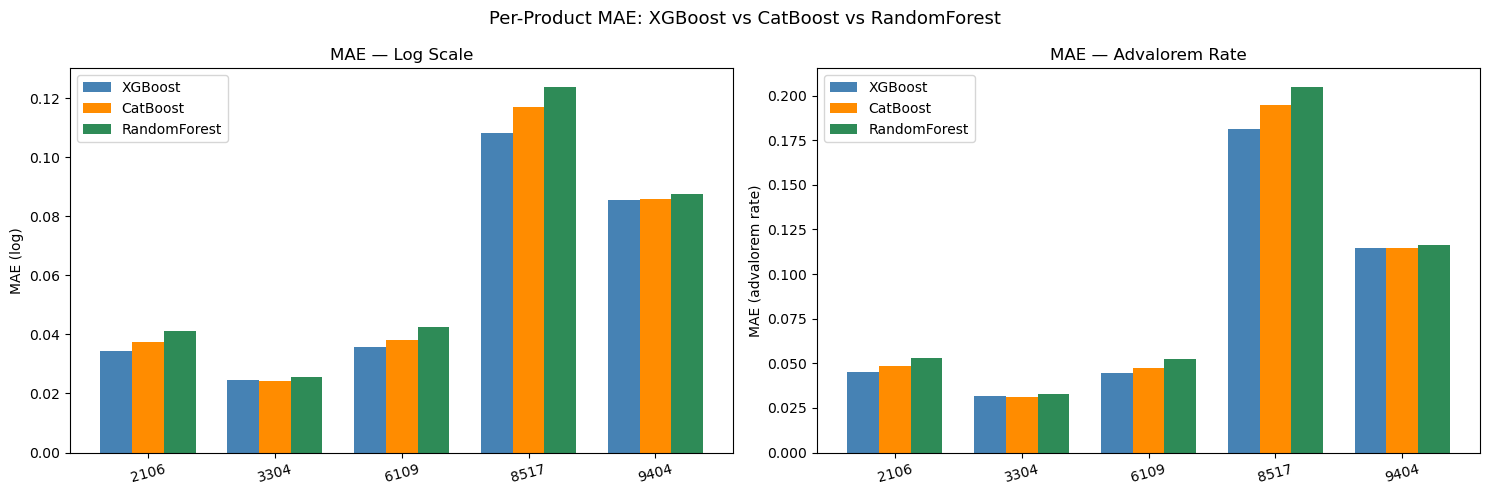

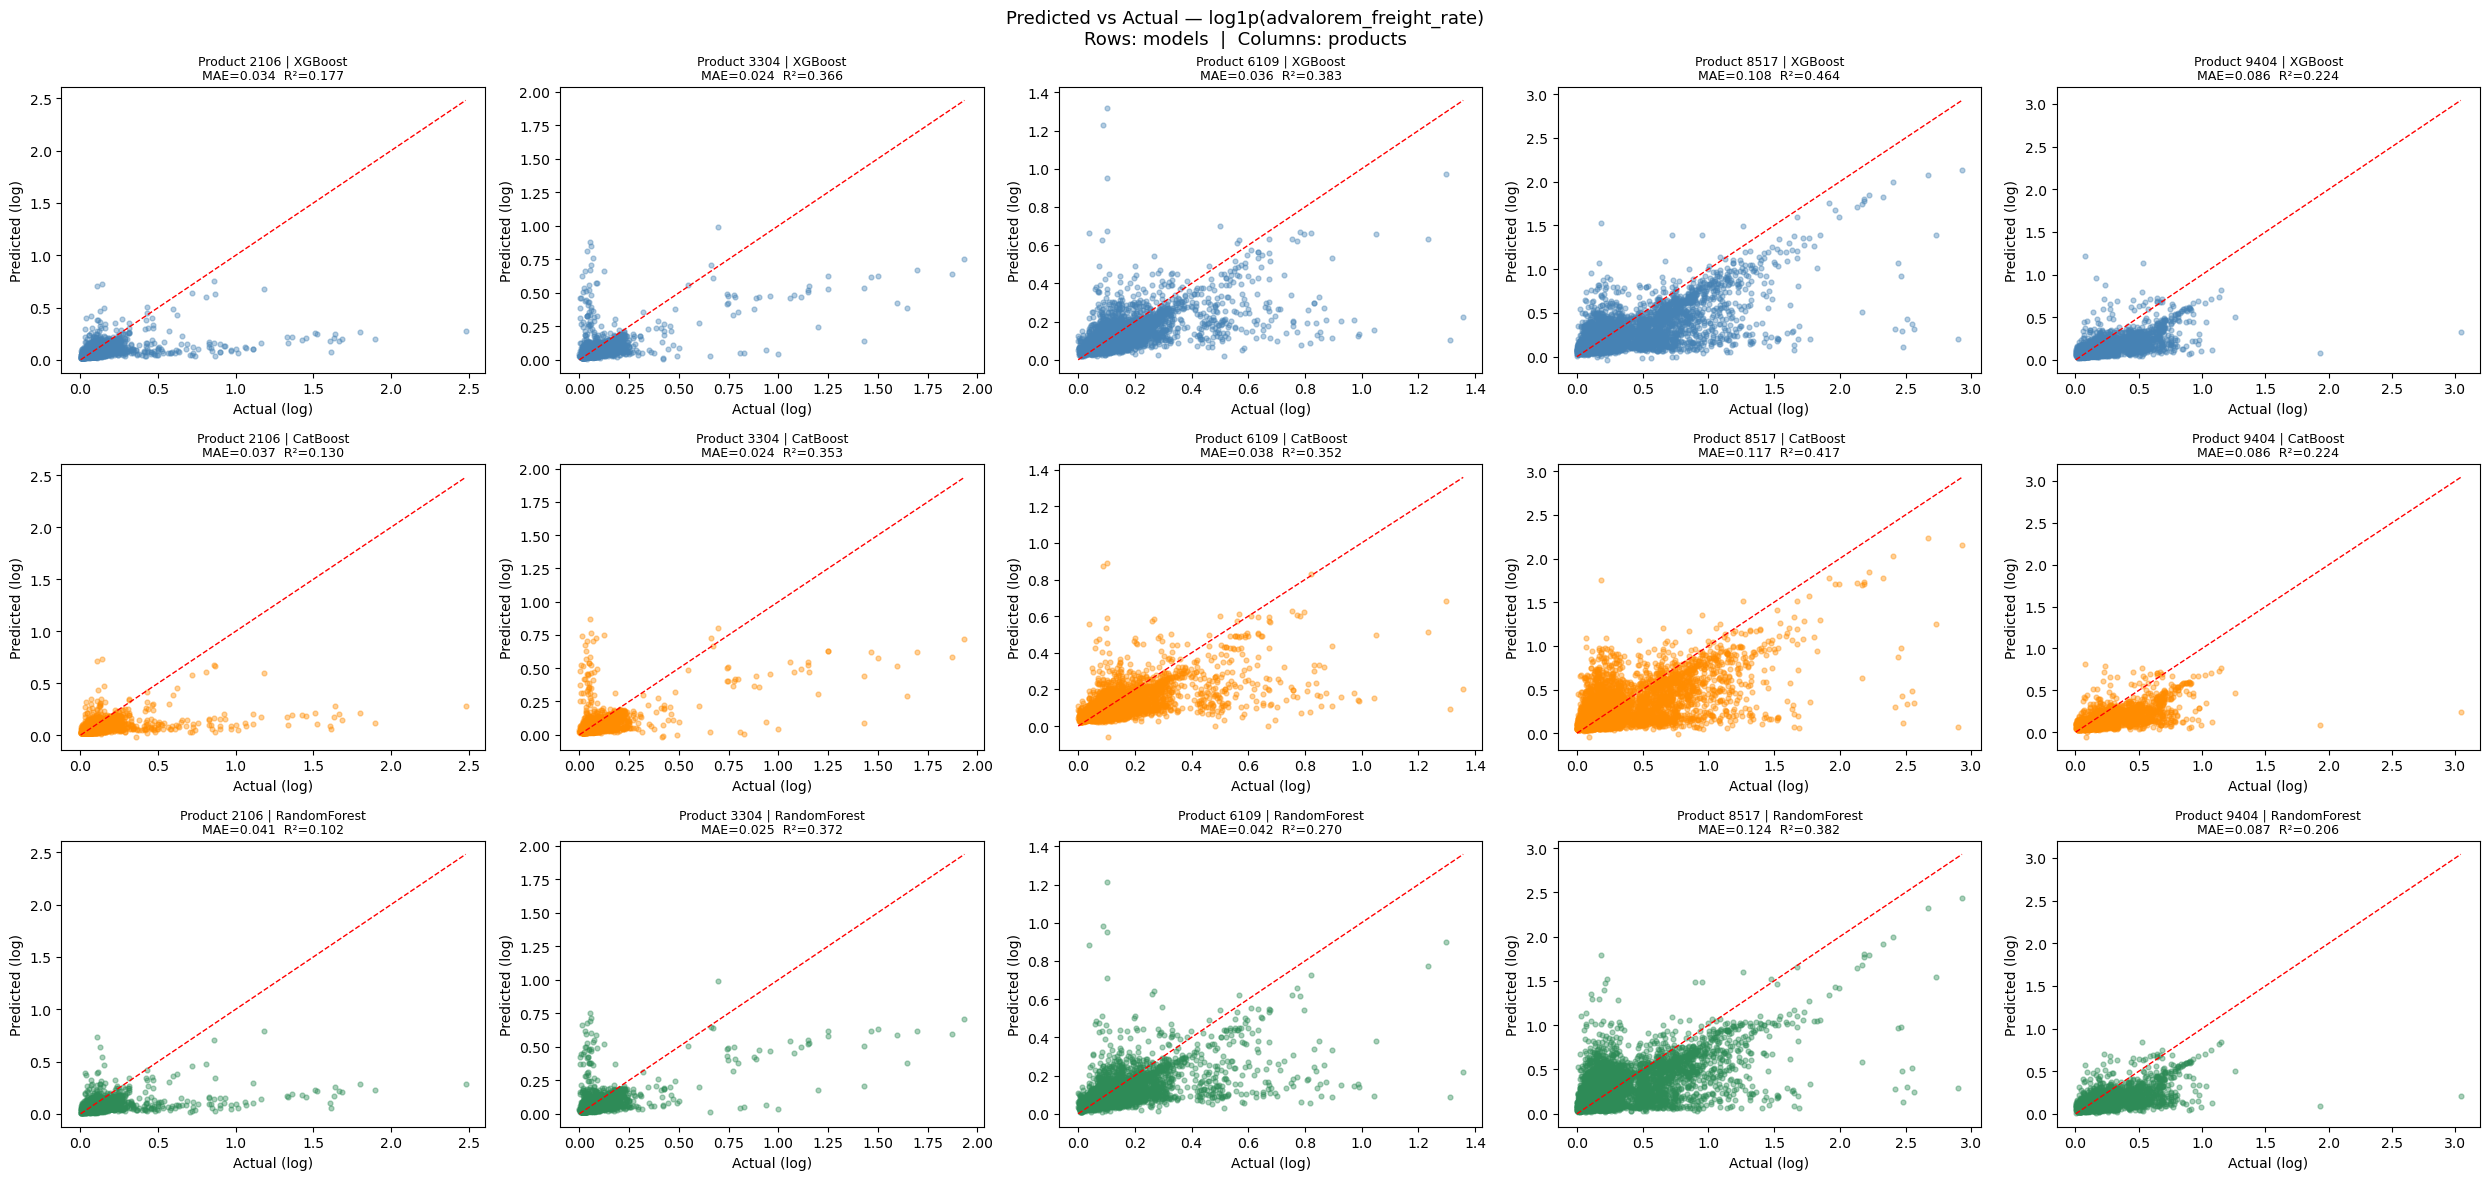

In [ ]:
_prods   = list(pipeline_results.keys())
_x       = np.arange(len(_prods))
_w       = 0.25
_colors  = {"XGBoost": "steelblue", "CatBoost": "darkorange", "RandomForest": "seagreen"}
_offsets = {"XGBoost": -_w, "CatBoost": 0, "RandomForest": _w}

# ── (A) MAE bar chart: log scale and advalorem scale ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(max(12, len(_prods) * 3), 5))

for _name in _model_names:
    _mae_log = [pipeline_results[p][_name]["metrics"]["mae_log"]       for p in _prods]
    _mae_adv = [pipeline_results[p][_name]["metrics"]["mae_advalorem"] for p in _prods]
    _off     = _offsets[_name]
    axes[0].bar(_x + _off, _mae_log, _w, label=_name, color=_colors[_name])
    axes[1].bar(_x + _off, _mae_adv, _w, label=_name, color=_colors[_name])

for _ax, _title, _ylabel in zip(
    axes,
    ["MAE — Log Scale", "MAE — Advalorem Rate"],
    ["MAE (log)",        "MAE (advalorem rate)"],
):
    _ax.set_xticks(_x)
    _ax.set_xticklabels(_prods, rotation=15)
    _ax.set_ylabel(_ylabel)
    _ax.set_title(_title)
    _ax.legend()

plt.suptitle("Per-Product MAE: XGBoost vs CatBoost vs RandomForest", fontsize=13)
plt.tight_layout()
plt.show()

# ── (B) Predicted vs Actual scatter ──────────────────────────────────────────
# Grid layout: rows = models, columns = products
_n_models = len(_model_names)
_n_prods  = len(_prods)
fig, axes = plt.subplots(
    _n_models, _n_prods,
    figsize=(5 * _n_prods, 4 * _n_models),
    squeeze=False,
)

for _j, _prod in enumerate(_prods):
    for _i, _name in enumerate(_model_names):
        _r  = pipeline_results[_prod][_name]
        _yt = _r["y_test"]
        _yp = _r["y_pred"]
        _m  = _r["metrics"]
        _lo, _hi = float(_yt.min()), float(_yt.max())

        axes[_i, _j].scatter(_yt, _yp, alpha=0.4, s=12, color=_colors[_name])
        # Perfect-prediction diagonal
        axes[_i, _j].plot([_lo, _hi], [_lo, _hi], "r--", lw=1)
        axes[_i, _j].set_title(
            f"Product {_prod} | {_name}\n"
            f"MAE={_m['mae_log']:.3f}  R²={_m['r2_log']:.3f}",
            fontsize=9,
        )
        axes[_i, _j].set_xlabel("Actual (log)")
        axes[_i, _j].set_ylabel("Predicted (log)")

plt.suptitle(
    "Predicted vs Actual — log1p(advalorem_freight_rate)\n"
    "Rows: models  |  Columns: products",
    fontsize=13,
)
plt.tight_layout()
plt.show()

## Step 5 — Temporal Fusion Transformer (TFT)

TFT is a sequence-to-sequence deep learning architecture designed for multi-horizon time-series forecasting. Unlike the tree-based models above, TFT:

- Treats each **Origin → Destination route** as a separate time series (identified by `group_id`).
- Uses a `GroupNormalizer` for per-series scaling rather than a global `StandardScaler`.
- Learns temporal patterns via multi-head attention over the encoder window.
- Is trained with a **quantile loss** but evaluated here on the point forecast (median quantile, index 3).

**Setup:** each product gets its own TFT model. Series shorter than `TFT_MIN_LEN` years are excluded. Training uses the same temporal split as the tree models (`split_year`).

> **Note:** TFT requires `pytorch-forecasting` and `lightning`. These are installed in the next cell.

In [ ]:
import subprocess, sys

# Install pytorch-forecasting (includes lightning as a dependency)
subprocess.run(
    [sys.executable, "-m", "pip", "install", "pytorch-forecasting", "lightning", "--quiet"],
    check=True,
)

import torch
import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

print(f"pytorch-forecasting ready  |  torch={torch.__version__}  |  "
      f"GPU={'yes' if torch.cuda.is_available() else 'no (CPU)'}")

pytorch-forecasting ready  |  torch=2.10.0+cpu  |  GPU=no (CPU)


In [ ]:
# ── TFT Hyper-parameters ─────────────────────────────────────────────────────
TFT_PARAMS = dict(
    learning_rate           = 3e-3,
    hidden_size             = 32,
    attention_head_size     = 2,
    dropout                 = 0.1,
    hidden_continuous_size  = 16,
    output_size             = 7,    # 7 quantiles (0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98)
    log_interval            = -1,
    reduce_on_plateau_patience = 4,
)
TFT_MAX_ENCODER = 4   # look-back window (years)
TFT_MAX_PRED    = 1   # predict exactly 1 year ahead (only 1 test year available)
TFT_MIN_LEN     = TFT_MAX_ENCODER + TFT_MAX_PRED + 1  # minimum series length = 6
TFT_N_EPOCHS    = 5
TFT_BATCH_SIZE  = 64
QUANTILE_IDX    = 3   # index of the 0.5 (median) quantile in 7-quantile output

print(f"TFT hyper-parameters configured. MIN_SERIES_LEN={TFT_MIN_LEN}")

TFT hyper-parameters configured. MIN_SERIES_LEN=6


In [ ]:
import traceback
import warnings
warnings.filterwarnings("ignore")


def _predict_with_index(model, val_loader):
    """Run TFT inference and return predictions plus the decoded index dataframe when available."""
    out = model.predict(
        val_loader,
        mode="prediction",
        return_index=True,
        trainer_kwargs={
            "accelerator": "auto",
            "logger": False,
            "enable_progress_bar": False,
        },
    )

    preds_t, idx_df = None, None

    if hasattr(out, "prediction") and hasattr(out, "index"):
        preds_t, idx_df = out.prediction, out.index
    elif hasattr(out, "output") and hasattr(out, "index"):
        preds_t, idx_df = out.output, out.index
    elif isinstance(out, tuple):
        for item in out:
            if isinstance(item, pd.DataFrame) and idx_df is None:
                idx_df = item
            elif preds_t is None:
                preds_t = item
    else:
        preds_t = out

    if preds_t is None:
        return None, idx_df

    if torch.is_tensor(preds_t):
        preds_np = preds_t.detach().cpu().numpy()
    else:
        preds_np = np.asarray(preds_t)

    if preds_np.ndim == 1:
        preds_np = preds_np[:, None]

    return preds_np, idx_df


def _align_predictions_to_actuals(preds_np, idx_df, df_p, training_cutoff):
    """Align TFT predictions with the true held-out target rows using decoded group ids when available."""
    if preds_np is None or len(preds_np) == 0:
        return None

    pred_df = pd.DataFrame({
        "y_pred": preds_np[:, -1],
    })

    group_col = None
    if isinstance(idx_df, pd.DataFrame) and len(idx_df) == len(pred_df):
        for col in idx_df.columns:
            sample = str(idx_df[col].iloc[0]) if len(idx_df) else ""
            if "||" in sample:
                group_col = col
                break
        if group_col is None:
            object_cols = [col for col in idx_df.columns if idx_df[col].dtype == object]
            if object_cols:
                group_col = object_cols[0]
        if group_col is not None:
            pred_df["group_id"] = idx_df[group_col].astype(str).values

    actual_df = (
        df_p[df_p["time_idx"] > training_cutoff]
        .sort_values(["group_id", "time_idx"])
        .groupby("group_id", as_index=False)
        .tail(1)[["group_id", "time_idx", TARGET]]
        .rename(columns={TARGET: "y_test"})
        .reset_index(drop=True)
    )

    if "group_id" in pred_df.columns:
        aligned = pred_df.merge(actual_df, on="group_id", how="inner")
        if not aligned.empty:
            return aligned[["group_id", "time_idx", "y_test", "y_pred"]]

    fallback = actual_df.copy()
    n = min(len(pred_df), len(fallback))
    if n == 0:
        return None
    fallback = fallback.iloc[:n].copy()
    fallback["y_pred"] = pred_df["y_pred"].iloc[:n].to_numpy()
    return fallback[["group_id", "time_idx", "y_test", "y_pred"]]


def train_tft_product(product_code) -> dict | None:
    """
    Train a TFT model for one product and return evaluation metrics.
    Returns None if the product has insufficient data or training fails.


    Tested against pytorch-forecasting==1.6.1 / lightning==2.6.1.
    """
    try:
        # ── 1. Build per-product frame ────────────────────────────────────────
        df_p = df_model[df_model["Product_Code"] == product_code].copy()
        df_p = df_p.sort_values([TIME_COL])
        df_p["group_id"] = (df_p["Origin_Label"] + "||" + df_p["Destination_Label"]).astype(str)
        min_year = int(df_p[TIME_COL].min())
        df_p["time_idx"] = (df_p[TIME_COL] - min_year).astype(int)

        # ── 2. Keep only series long enough for encoder + prediction ──────────
        slen = df_p.groupby("group_id")["time_idx"].count()
        valid_groups = slen[slen >= TFT_MIN_LEN].index
        df_p = df_p[df_p["group_id"].isin(valid_groups)].copy()
        if df_p.empty:
            print(f"  [TFT] {product_code}: skipped — no group has ≥{TFT_MIN_LEN} obs.")
            return None

        # ── 3. Also require each group to have at least 1 post-split obs ──────
        post_split = df_p[df_p[TIME_COL] > split_year].groupby("group_id").size()
        groups_with_test = post_split[post_split >= 1].index
        df_p = df_p[df_p["group_id"].isin(groups_with_test)].copy()
        if df_p.empty:
            print(f"  [TFT] {product_code}: skipped — no group has test observations.")
            return None

        training_cutoff = int(df_p[df_p[TIME_COL] <= split_year]["time_idx"].max())
        if training_cutoff < TFT_MAX_ENCODER:
            print(f"  [TFT] {product_code}: skipped — encoder window too small.")
            return None

        # External covariates available in df_p (exclude target & identifiers)
        exclude = {TARGET, "group_id", "time_idx", TIME_COL,
                   "Origin_Label", "Destination_Label", "Product_Code",
                   "origin_enc", "dest_enc", "product_enc",
                   "target_lag_1", "target_lag_2", "target_lag_3",
                   "target_rolling_mean_3"}
        real_covariates = [c for c in FEATURE_COLS if c in df_p.columns and c not in exclude]

        # ── 4. Build training TimeSeriesDataSet ───────────────────────────────
        df_train = df_p[df_p["time_idx"] <= training_cutoff].copy()
        training_ds = TimeSeriesDataSet(
            df_train,
            time_idx="time_idx",
            target=TARGET,
            group_ids=["group_id"],
            min_encoder_length=max(1, TFT_MAX_ENCODER // 2),
            max_encoder_length=TFT_MAX_ENCODER,
            min_prediction_length=TFT_MAX_PRED,
            max_prediction_length=TFT_MAX_PRED,
            static_categoricals=["group_id"],
            time_varying_known_reals=["time_idx"],
            time_varying_unknown_reals=[TARGET] + real_covariates,
            target_normalizer=GroupNormalizer(
                groups=["group_id"], transformation="softplus"
            ),
            add_relative_time_idx=True,
            add_target_scales=True,
            add_encoder_length=True,
            allow_missing_timesteps=True,
        )

        # ── 5. Build validation dataset (predict=True → last window per group) ─
        validation_ds = TimeSeriesDataSet.from_dataset(
            training_ds, df_p, predict=True, stop_randomization=True,
            allow_missing_timesteps=True,
        )
        if len(validation_ds) == 0:
            print(f"  [TFT] {product_code}: skipped — validation dataset is empty.")
            return None

        train_loader = training_ds.to_dataloader(
            train=True, batch_size=TFT_BATCH_SIZE, num_workers=0, shuffle=True
        )
        val_loader = validation_ds.to_dataloader(
            train=False, batch_size=TFT_BATCH_SIZE, num_workers=0, shuffle=False
        )

        # ── 6. Build and train TFT ────────────────────────────────────────────
        tft_model = TemporalFusionTransformer.from_dataset(
            training_ds,
            loss=QuantileLoss(),
            **TFT_PARAMS,
        )

        trainer = pl.Trainer(
            max_epochs=TFT_N_EPOCHS,
            enable_model_summary=False,
            enable_progress_bar=False,
            logger=False,
            accelerator="auto",
            devices=1,
        )
        trainer.fit(tft_model, train_dataloaders=train_loader, val_dataloaders=val_loader)

        # ── 7. Predict with decoded index and align to held-out rows ──────────
        preds_np, idx_df = _predict_with_index(tft_model, val_loader)
        aligned_eval = _align_predictions_to_actuals(preds_np, idx_df, df_p, training_cutoff)
        if aligned_eval is None or aligned_eval.empty:
            print(f"  [TFT] {product_code}: skipped — could not align predictions to actuals.")
            return None

        y_pred_log = aligned_eval["y_pred"].to_numpy()
        y_test_log = aligned_eval["y_test"].to_numpy()

        # ── 8. Metrics ────────────────────────────────────────────────────────
        mae_log = mean_absolute_error(y_test_log, y_pred_log)
        rmse_log = mean_squared_error(y_test_log, y_pred_log) ** 0.5
        r2_log = r2_score(y_test_log, y_pred_log)

        y_pred_orig = np.expm1(y_pred_log)
        y_test_orig = np.expm1(y_test_log)
        mae_adv = mean_absolute_error(y_test_orig, y_pred_orig)
        rmse_adv = mean_squared_error(y_test_orig, y_pred_orig) ** 0.5

        return {
            "y_pred": y_pred_log,
            "y_test": y_test_log,
            "metrics": dict(
                mae_log=mae_log,
                rmse_log=rmse_log,
                r2_log=r2_log,
                mae_advalorem=mae_adv,
                rmse_advalorem=rmse_adv,
                mean_actual=float(np.expm1(y_test_log).mean()),
                n_test=int(len(y_test_log)),
            ),
        }

    except Exception:
        print(f"  [TFT] {product_code}: ERROR —")
        traceback.print_exc()
        return None


# ── Run TFT for every product ──────────────────────────────────────────────────
tft_results = {}
pl.seed_everything(42, workers=True)

for prod in PRODUCTS:
    print(f"\nFitting TFT for product: {prod}")
    res = train_tft_product(prod)
    tft_results[prod] = res
    if res is not None:
        m = res["metrics"]
        print(f"  MAE(log)={m['mae_log']:.4f}  RMSE(log)={m['rmse_log']:.4f}"
              f"  R²={m['r2_log']:.4f}  n={m['n_test']}")

n_ok = sum(v is not None for v in tft_results.values())
print(f"\nTFT done: {n_ok}/{len(PRODUCTS)} products trained successfully.")

## Step 6 — Four-Model Comparison (XGBoost vs CatBoost vs RandomForest vs TFT)

In [ ]:
# ── Build combined summary table ──────────────────────────────────────────────
ALL_MODELS   = ["XGBoost", "CatBoost", "RandomForest", "TFT"]
MODEL_COLORS = {
    "XGBoost"     : "steelblue",
    "CatBoost"    : "darkorange",
    "RandomForest": "seagreen",
    "TFT"         : "crimson",
}

rows = []
for prod in PRODUCTS:
    row = {"Product": prod}
    # ── tree models (from pipeline_results) ──────────────────────────────────
    if prod in pipeline_results:
        for mname in ["XGBoost", "CatBoost", "RandomForest"]:
            if mname in pipeline_results[prod]:
                m = pipeline_results[prod][mname]["metrics"]
                row[f"{mname}_MAE_log"]        = m["mae_log"]
                row[f"{mname}_RMSE_log"]       = m["rmse_log"]
                row[f"{mname}_R2_log"]         = m["r2_log"]
                row[f"{mname}_MAE_advalorem"]  = m["mae_advalorem"]
    # ── TFT ──────────────────────────────────────────────────────────────────
    if prod in tft_results and tft_results[prod] is not None:
        m = tft_results[prod]["metrics"]
        row["TFT_MAE_log"]        = m["mae_log"]
        row["TFT_RMSE_log"]       = m["rmse_log"]
        row["TFT_R2_log"]         = m["r2_log"]
        row["TFT_MAE_advalorem"]  = m["mae_advalorem"]
    rows.append(row)

df_all = pd.DataFrame(rows).set_index("Product")

# ── Pretty display ─────────────────────────────────────────────────────────────
display_cols = [f"{m}_MAE_log" for m in ALL_MODELS] + \
               [f"{m}_R2_log"  for m in ALL_MODELS]
print("=== Four-Model Comparison (log-scale MAE and R²) ===")
print(df_all[[c for c in display_cols if c in df_all.columns]].to_string())

NameError: name 'tft_results' is not defined

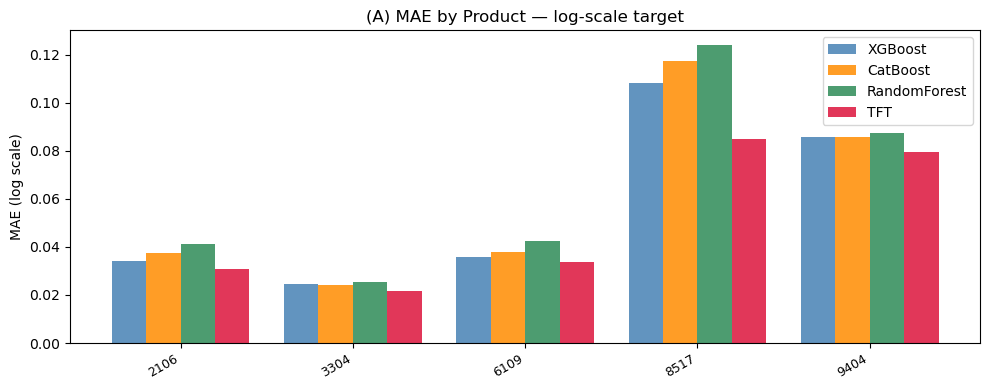

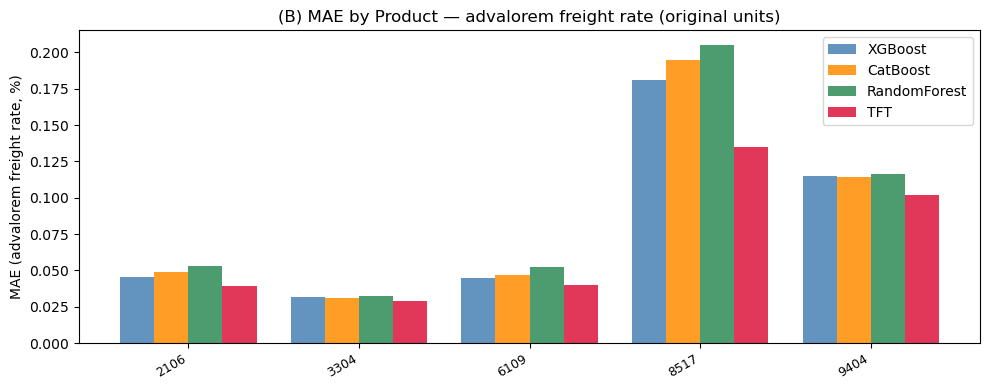

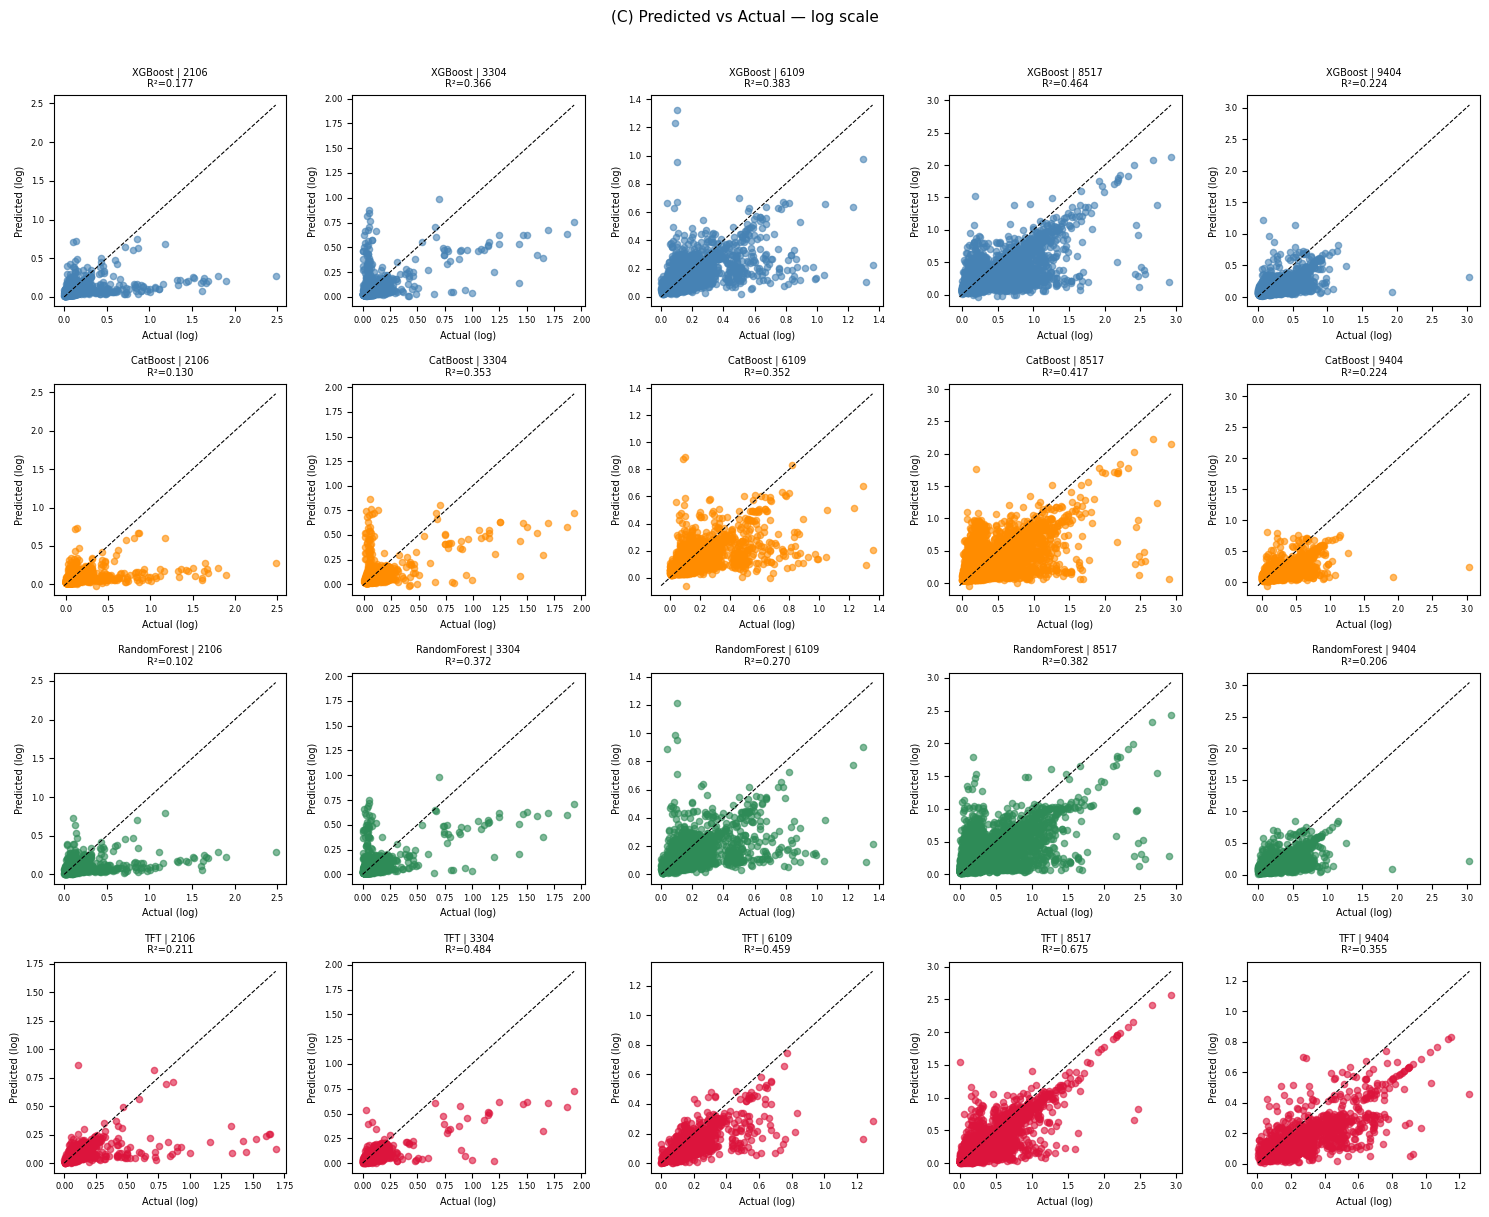

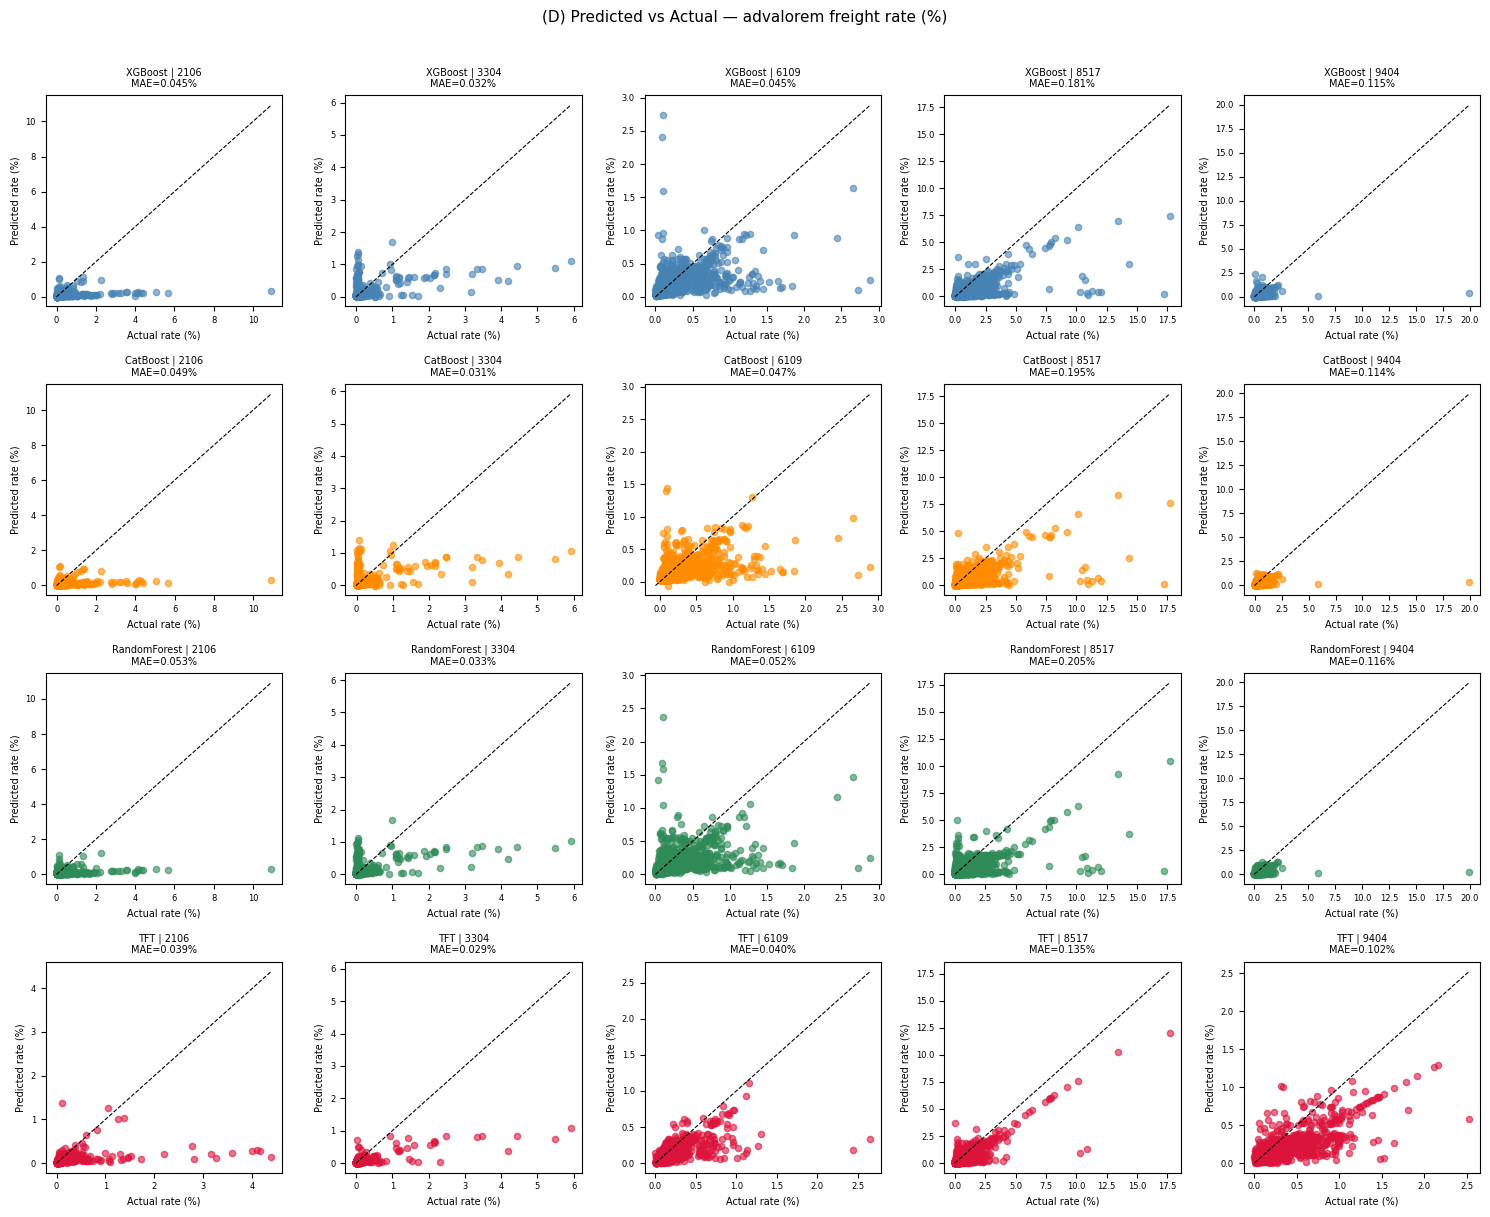

In [58]:
# ── Comparison Plots ──────────────────────────────────────────────────────────
products_with_tft = [p for p in PRODUCTS if p in tft_results and tft_results[p] is not None]
n_prod = len(PRODUCTS)


def _get_yt_yp(mname, prod, scale="log"):
    """Return (y_test, y_pred) for a given model/product, in log or advalorem scale."""
    if mname == "TFT":
        r = tft_results.get(prod)
        if r is None:
            return None, None
        y_t, y_p = r["y_test"], r["y_pred"]
    else:
        r = pipeline_results.get(prod, {}).get(mname)
        if r is None:
            return None, None
        y_t, y_p = r["y_test"], r["y_pred"]
    if scale == "advalorem":
        y_t, y_p = np.expm1(y_t), np.expm1(y_p)
    return y_t, y_p


# ─── (A) MAE bar chart — log scale ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(10, n_prod * 1.5), 4))
x, bar_w = np.arange(n_prod), 0.2

for i, mname in enumerate(ALL_MODELS):
    col = f"{mname}_MAE_log"
    maes = [df_all.loc[p, col] if col in df_all.columns and not pd.isna(df_all.loc[p, col])
            else float("nan") for p in PRODUCTS]
    ax.bar(x + i * bar_w, maes, bar_w, label=mname, color=MODEL_COLORS[mname], alpha=0.85)

ax.set_xticks(x + bar_w * 1.5)
ax.set_xticklabels(PRODUCTS, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("MAE (log scale)")
ax.set_title("(A) MAE by Product — log-scale target")
ax.legend()
plt.tight_layout()
plt.show()

# ─── (B) MAE bar chart — advalorem freight rate (original units) ─────────────
fig, ax = plt.subplots(figsize=(max(10, n_prod * 1.5), 4))

for i, mname in enumerate(ALL_MODELS):
    col = f"{mname}_MAE_advalorem"
    maes = [df_all.loc[p, col] if col in df_all.columns and not pd.isna(df_all.loc[p, col])
            else float("nan") for p in PRODUCTS]
    ax.bar(x + i * bar_w, maes, bar_w, label=mname, color=MODEL_COLORS[mname], alpha=0.85)

ax.set_xticks(x + bar_w * 1.5)
ax.set_xticklabels(PRODUCTS, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("MAE (advalorem freight rate, %)")
ax.set_title("(B) MAE by Product — advalorem freight rate (original units)")
ax.legend()
plt.tight_layout()
plt.show()

# ─── (C) Predicted-vs-actual scatter — log scale ─────────────────────────────
n_rows = len(ALL_MODELS)
fig, axes = plt.subplots(n_rows, n_prod, figsize=(n_prod * 3, n_rows * 3),
                         sharey=False, sharex=False)
if n_rows == 1:
    axes = [axes]
if n_prod == 1:
    axes = [[a] for a in axes]

for row_i, mname in enumerate(ALL_MODELS):
    for col_j, prod in enumerate(PRODUCTS):
        ax = axes[row_i][col_j]
        y_t, y_p = _get_yt_yp(mname, prod, scale="log")
        if y_t is None:
            ax.set_visible(False)
            continue
        ax.scatter(y_t, y_p, alpha=0.6, s=20, color=MODEL_COLORS[mname])
        lo, hi = min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())
        ax.plot([lo, hi], [lo, hi], "k--", linewidth=0.8)
        ax.set_title(f"{mname} | {prod}\nR²={r2_score(y_t, y_p):.3f}", fontsize=7)
        ax.set_xlabel("Actual (log)", fontsize=7)
        ax.set_ylabel("Predicted (log)", fontsize=7)
        ax.tick_params(labelsize=6)

plt.suptitle("(C) Predicted vs Actual — log scale", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

# ─── (D) Predicted-vs-actual scatter — advalorem freight rate ────────────────
fig, axes = plt.subplots(n_rows, n_prod, figsize=(n_prod * 3, n_rows * 3),
                         sharey=False, sharex=False)
if n_rows == 1:
    axes = [axes]
if n_prod == 1:
    axes = [[a] for a in axes]

for row_i, mname in enumerate(ALL_MODELS):
    for col_j, prod in enumerate(PRODUCTS):
        ax = axes[row_i][col_j]
        y_t, y_p = _get_yt_yp(mname, prod, scale="advalorem")
        if y_t is None:
            ax.set_visible(False)
            continue
        ax.scatter(y_t, y_p, alpha=0.6, s=20, color=MODEL_COLORS[mname])
        lo, hi = min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())
        ax.plot([lo, hi], [lo, hi], "k--", linewidth=0.8)
        mae_adv = mean_absolute_error(y_t, y_p)
        ax.set_title(f"{mname} | {prod}\nMAE={mae_adv:.3f}%", fontsize=7)
        ax.set_xlabel("Actual rate (%)", fontsize=7)
        ax.set_ylabel("Predicted rate (%)", fontsize=7)
        ax.tick_params(labelsize=6)

plt.suptitle("(D) Predicted vs Actual — advalorem freight rate (%)", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

In [3]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")

False
No GPU detected


## Step 7 — Simple TFT Demo Prediction

This demo randomly selects one route-product combination that exists in **2022**, trains a temporary TFT model for that product using data up to **2021**, and predicts the **2022** advalorem freight rate for that sampled route.

In [66]:
DEMO_YEAR = 2022
DEMO_RANDOM_SEED = 42
DEMO_EPOCHS = min(TFT_N_EPOCHS, 3)
DEMO_MIN_ENCODER = max(2, TFT_MAX_ENCODER // 2)
demo_rng = np.random.default_rng(DEMO_RANDOM_SEED)


def _extract_prediction_array(pred_output):
    if hasattr(pred_output, "prediction"):
        pred_output = pred_output.prediction
    elif hasattr(pred_output, "output"):
        pred_output = pred_output.output
    if torch.is_tensor(pred_output):
        pred_output = pred_output.detach().cpu().numpy()
    else:
        pred_output = np.asarray(pred_output)
    if pred_output.ndim == 1:
        pred_output = pred_output[:, None]
    return pred_output


demo_source = tmp.copy()
demo_source["group_id"] = (
    demo_source["Origin_Label"].astype(str) + "||" + demo_source["Destination_Label"].astype(str)
)

real_2022_candidates = []
for demo_product in sorted(demo_source["Product_Code"].dropna().unique()):
    demo_sub = demo_source[demo_source["Product_Code"] == demo_product].copy()
    hist_counts = demo_sub[
        (demo_sub[TIME_COL] < DEMO_YEAR) & demo_sub[TARGET].notna()
    ].groupby("group_id").size()
    year_rows = demo_sub[demo_sub[TIME_COL] == DEMO_YEAR][
        ["group_id", "Origin_Label", "Destination_Label"]
    ].drop_duplicates()
    for _, route_row in year_rows.iterrows():
        group_id = route_row["group_id"]
        if hist_counts.get(group_id, 0) >= DEMO_MIN_ENCODER:
            real_2022_candidates.append({
                "Product_Code": demo_product,
                "group_id": group_id,
                "Origin_Label": route_row["Origin_Label"],
                "Destination_Label": route_row["Destination_Label"],
                "history_rows": int(hist_counts.get(group_id, 0)),
                "has_real_2022": True,
            })

synthetic_2022_candidates = []
if not real_2022_candidates:
    for demo_product in sorted(demo_source["Product_Code"].dropna().unique()):
        demo_sub = demo_source[demo_source["Product_Code"] == demo_product].copy()
        history = demo_sub[demo_sub[TARGET].notna()].copy()
        if history.empty:
            continue
        route_summary = history.groupby("group_id").agg(
            history_rows=(TARGET, "count"),
            last_year=(TIME_COL, "max"),
            Origin_Label=("Origin_Label", "last"),
            Destination_Label=("Destination_Label", "last"),
        ).reset_index()
        route_summary = route_summary[
            (route_summary["history_rows"] >= DEMO_MIN_ENCODER) &
            (route_summary["last_year"] < DEMO_YEAR)
        ]
        for _, route_row in route_summary.iterrows():
            synthetic_2022_candidates.append({
                "Product_Code": demo_product,
                "group_id": route_row["group_id"],
                "Origin_Label": route_row["Origin_Label"],
                "Destination_Label": route_row["Destination_Label"],
                "history_rows": int(route_row["history_rows"]),
                "has_real_2022": False,
            })

demo_candidates = real_2022_candidates or synthetic_2022_candidates
if not demo_candidates:
    raise ValueError(
        f"No route was found with at least {DEMO_MIN_ENCODER} historical observations for a TFT demo."
    )

demo_choice = demo_candidates[int(demo_rng.integers(len(demo_candidates)))]
demo_product = demo_choice["Product_Code"]
demo_group_id = demo_choice["group_id"]
print("Selected random demo route:")
print(f"  Product_Code      : {demo_product}")
print(f"  Origin_Label      : {demo_choice['Origin_Label']}")
print(f"  Destination_Label : {demo_choice['Destination_Label']}")
print(f"  Forecast Year     : {DEMO_YEAR}")
print(f"  Historical rows   : {demo_choice['history_rows']}")
print(f"  2022 source row   : {'real row' if demo_choice['has_real_2022'] else 'synthetic carry-forward row'}")

demo_df = demo_source[demo_source["Product_Code"] == demo_product].copy()
demo_min_year = int(demo_df[TIME_COL].min())
demo_df["time_idx"] = (demo_df[TIME_COL] - demo_min_year).astype(int)

demo_train_df = demo_df[
    (demo_df[TIME_COL] <= DEMO_YEAR - 1) & demo_df[TARGET].notna()
].copy()
if demo_train_df.empty:
    raise ValueError("No observed training rows are available up to 2021 for the sampled product.")

demo_exclude = {
    TARGET, "group_id", "time_idx", TIME_COL,
    "Origin_Label", "Destination_Label", "Product_Code",
    "origin_enc", "dest_enc", "product_enc",
    "target_lag_1", "target_lag_2", "target_lag_3",
    "target_rolling_mean_3",
}
demo_real_covariates = [c for c in FEATURE_COLS if c in demo_df.columns and c not in demo_exclude]

demo_training_ds = TimeSeriesDataSet(
    demo_train_df,
    time_idx="time_idx",
    target=TARGET,
    group_ids=["group_id"],
    min_encoder_length=DEMO_MIN_ENCODER,
    max_encoder_length=TFT_MAX_ENCODER,
    min_prediction_length=1,
    max_prediction_length=1,
    static_categoricals=["group_id"],
    time_varying_known_reals=["time_idx"],
    time_varying_unknown_reals=[TARGET] + demo_real_covariates,
    target_normalizer=GroupNormalizer(groups=["group_id"], transformation="softplus"),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

demo_route_history = demo_df[
    (demo_df["group_id"] == demo_group_id) &
    (demo_df[TIME_COL] < DEMO_YEAR) &
    demo_df[TARGET].notna()
].copy()
demo_route_history = demo_route_history.sort_values(TIME_COL).reset_index(drop=True)

demo_route_2022 = demo_df[
    (demo_df["group_id"] == demo_group_id) & (demo_df[TIME_COL] == DEMO_YEAR)
].copy()

if demo_route_2022.empty:
    demo_route_2022 = demo_route_history.tail(1).copy()
    if demo_route_2022.empty:
        raise ValueError("The sampled route does not have enough history to create a 2022 demo row.")
    demo_route_2022[TIME_COL] = DEMO_YEAR
    demo_route_2022["time_idx"] = DEMO_YEAR - demo_min_year
    demo_route_2022[TARGET] = np.nan
    if "post_covid" in demo_route_2022.columns:
        demo_route_2022["post_covid"] = 1

demo_route_df = pd.concat([demo_route_history, demo_route_2022], ignore_index=True)
demo_route_df = demo_route_df.sort_values(TIME_COL).reset_index(drop=True)

demo_route_pred_df = demo_route_df.copy()
used_target_placeholder = False
target_placeholder_value = None
if demo_route_pred_df[TARGET].isna().any():
    last_observed_target = float(demo_route_history[TARGET].iloc[-1])
    demo_route_pred_df[TARGET] = demo_route_pred_df[TARGET].fillna(last_observed_target)
    used_target_placeholder = True
    target_placeholder_value = last_observed_target

demo_input_cols = [
    "Origin_Label", "Destination_Label", "Product_Code",
    TIME_COL, "time_idx", "group_id"
 ] + [c for c in demo_real_covariates if c in demo_route_pred_df.columns]
demo_input_cols = list(dict.fromkeys([c for c in demo_input_cols if c in demo_route_pred_df.columns]))
demo_input_row = demo_route_pred_df.loc[demo_route_pred_df[TIME_COL] == DEMO_YEAR, demo_input_cols].reset_index(drop=True)

demo_pred_ds = TimeSeriesDataSet.from_dataset(
    demo_training_ds,
    demo_route_pred_df,
    predict=True,
    stop_randomization=True,
    allow_missing_timesteps=True,
)
demo_pred_loader = demo_pred_ds.to_dataloader(train=False, batch_size=1, num_workers=0, shuffle=False)

demo_model = TemporalFusionTransformer.from_dataset(
    demo_training_ds,
    loss=QuantileLoss(),
    **TFT_PARAMS,
)
demo_trainer = pl.Trainer(
    max_epochs=DEMO_EPOCHS,
    enable_model_summary=False,
    enable_progress_bar=False,
    logger=False,
    accelerator="auto",
    devices=1,
    enable_checkpointing=False,
    deterministic=True,
    gradient_clip_val=0.1,
)
demo_trainer.fit(
    demo_model,
    train_dataloaders=demo_training_ds.to_dataloader(train=True, batch_size=TFT_BATCH_SIZE, num_workers=0, shuffle=True),
)

demo_pred_output = demo_model.predict(
    demo_pred_loader,
    mode="prediction",
    return_index=True,
    trainer_kwargs={
        "accelerator": "auto",
        "logger": False,
        "enable_progress_bar": False,
    },
)
demo_pred_array = _extract_prediction_array(demo_pred_output)
demo_pred_log = float(demo_pred_array[0, -1])
demo_pred_rate = float(np.expm1(demo_pred_log))

print("\nX inputs used for the 2022 TFT prediction:")
display(demo_input_row)
if used_target_placeholder:
    print(f"Target placeholder used only for dataset construction: {target_placeholder_value:.4f} (log scale)")

print("\nTFT demo prediction for the sampled 2022 route:")
print(f"  Predicted log-rate : {demo_pred_log:.4f}")
print(f"  Predicted rate (%) : {demo_pred_rate:.4f}")

if TARGET in demo_route_2022.columns and demo_route_2022[TARGET].notna().any():
    demo_actual_log = float(demo_route_2022.loc[demo_route_2022[TARGET].notna(), TARGET].iloc[-1])
    demo_actual_rate = float(np.expm1(demo_actual_log))
    print(f"  Actual log-rate    : {demo_actual_log:.4f}")
    print(f"  Actual rate (%)    : {demo_actual_rate:.4f}")
    print(f"  Absolute error (%) : {abs(demo_pred_rate - demo_actual_rate):.4f}")
else:
    print("  Actual 2022 rate   : unavailable; this demo used a synthetic carry-forward 2022 feature row")

demo_history_cols = [
    TIME_COL, TARGET, "historical_mean_rate", "dist_km",
    "lsbci", "fuel_vlsfo_avg", "post_covid"
 ]
demo_history_cols = [col for col in demo_history_cols if col in demo_route_df.columns]
display(demo_route_df[demo_history_cols].tail(TFT_MAX_ENCODER + 1))

Selected random demo route:
  Product_Code      : 2106
  Origin_Label      : Japan
  Destination_Label : Niger
  Forecast Year     : 2022
  Historical rows   : 2
  2022 source row   : synthetic carry-forward row


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer.fit` stopped: `max_epochs=3` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



X inputs used for the 2022 TFT prediction:


,Origin_Label,Destination_Label,Product_Code,Year,time_idx,group_id,Source_CPI_Annual_average_growth_rate_Value,Destination_CPI_Annual_average_growth_rate_Value,Source_GDP_US_at_current_prices_in_millions_Value,Destination_GDP_US_at_current_prices_in_millions_Value,Source_GNI_US_dollars_at_current_prices_in_millions_Value,Destination_GNI_US_dollars_at_current_prices_in_millions_Value,lsbci,dist_km,fuel_vlsfo_avg,lsci_o,lsci_d,lsci_sum,lsci_gap,origin_teu,dest_teu,teu_log_product,origin_loaded_kt,origin_discharged_kt,dest_loaded_kt,dest_discharged_kt,trade_imbalance,origin_vessel_pct,dest_vessel_pct,fleet_supply,historical_mean_rate,historical_mean_rate_is_imputed,lsci_asymmetry,lsci_product,lsbci_per_km,trade_intensity,port_pressure,directional_imbalance,distance_lsci_interaction,distance_fleet_interaction,capacity_gap,trade_exists,post_covid,product_cat
0,Japan,Niger,2106,2022,6,Japan||Niger,0.99,2.75,5040881.0,12446.0,5135479.0,12659.0,0.3,12564.6,576.846774,400.2775,87.1525,304.3775,141.5375,23424446.0,0.0,0.0,168893.0,762539.0,264.0,568.0,0.996879,1.88,0.0,1.88,0.118,0,141.5375,11790.931625,0.000051,0.013647,0.031397,168325.0,1801.13128,23621.448,0.565166,1,1,0


Target placeholder used only for dataset construction: 0.1284 (log scale)

TFT demo prediction for the sampled 2022 route:
  Predicted log-rate : 0.0976
  Predicted rate (%) : 0.1025
  Actual 2022 rate   : unavailable; this demo used a synthetic carry-forward 2022 feature row


,Year,y_log,historical_mean_rate,dist_km,lsbci,fuel_vlsfo_avg,post_covid
0,2017,0.094401,0.118,12564.6,0.3,576.846774,0
1,2018,0.128393,0.118,12564.6,0.3,576.846774,0
2,2022,NaN,0.118,12564.6,0.3,576.846774,1


## Hyperparameter tunings on TFT

### Step 1: Set the Tone — Learning Rate (LR)

Building TFT datasets for product 2106 (LR study)...


Seed set to 42


  Training with LRs [0.01, 0.001, 0.0001] × 10 epochs each

▶ LR = 0.01


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

...

  ✓ Epoch 10 — Train Loss: 0.0018  |  Val Loss: 0.0375

▶ LR = 0.0001


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


  ✓ Epoch 10 — Train Loss: 0.0029  |  Val Loss: 0.0345



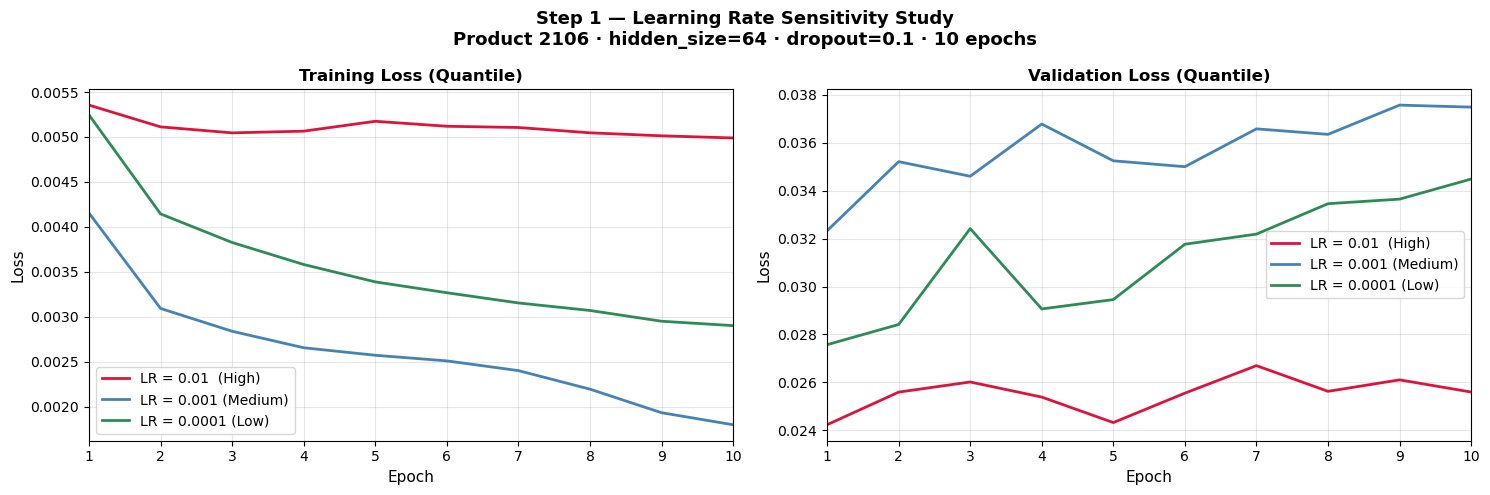

DECISION GUIDE — choose the LR with the smoothest,
lowest-descending Validation Loss curve.
LR              Train Loss (ep.50)    Val Loss (ep.50)
-------------------------------------------------------
0.01                        0.0050              0.0256
0.001                       0.0018              0.0375
0.0001                      0.0029              0.0345


In [56]:

import warnings
warnings.filterwarnings("ignore")
import lightning.pytorch as pl                      # must match pytorch-forecasting's internal lightning
from lightning.pytorch.callbacks import Callback

# ── Configuration ─────────────────────────────────────────────────────────────
LR_STUDY_EPOCHS  = 10
LR_STUDY_LRS     = [0.01, 0.001, 0.0001]
LR_STUDY_PRODUCT = PRODUCTS[0]          # representative product for LR sweep

LR_COLORS = {0.01: "crimson", 0.001: "steelblue", 0.0001: "seagreen"}
LR_LABELS = {
    0.01:   "LR = 0.01  (High)",
    0.001:  "LR = 0.001 (Medium)",
    0.0001: "LR = 0.0001 (Low)",
}

# Fixed architectural params (kept constant across all LR trials)
LR_STUDY_PARAMS = dict(
    hidden_size            = 64,
    attention_head_size    = 4,
    dropout                = 0.1,
    hidden_continuous_size = 32,
    output_size            = 7,
    log_interval           = -1,
    reduce_on_plateau_patience = 6,
)

# ── Dataset builder (mirrors train_tft_product logic) ─────────────────────────
def _build_tft_datasets_for_lr_study(product_code):
    df_p = df_model[df_model["Product_Code"] == product_code].copy()
    df_p = df_p.sort_values([TIME_COL])
    df_p["group_id"] = (df_p["Origin_Label"] + "||" + df_p["Destination_Label"]).astype(str)
    min_year  = int(df_p[TIME_COL].min())
    df_p["time_idx"] = (df_p[TIME_COL] - min_year).astype(int)

    slen = df_p.groupby("group_id")["time_idx"].count()
    valid_groups = slen[slen >= TFT_MIN_LEN].index
    df_p = df_p[df_p["group_id"].isin(valid_groups)].copy()

    post_split = df_p[df_p[TIME_COL] > split_year].groupby("group_id").size()
    groups_with_test = post_split[post_split >= 1].index
    df_p = df_p[df_p["group_id"].isin(groups_with_test)].copy()

    training_cutoff = int(df_p[df_p[TIME_COL] <= split_year]["time_idx"].max())

    exclude = {TARGET, "group_id", "time_idx", TIME_COL,
               "Origin_Label", "Destination_Label", "Product_Code",
               "origin_enc", "dest_enc", "product_enc",
               "target_lag_1", "target_lag_2", "target_lag_3",
               "target_rolling_mean_3"}
    real_covariates = [c for c in FEATURE_COLS if c in df_p.columns and c not in exclude]

    df_train = df_p[df_p["time_idx"] <= training_cutoff].copy()
    training_ds = TimeSeriesDataSet(
        df_train,
        time_idx="time_idx",
        target=TARGET,
        group_ids=["group_id"],
        min_encoder_length=max(1, TFT_MAX_ENCODER // 2),
        max_encoder_length=TFT_MAX_ENCODER,
        min_prediction_length=TFT_MAX_PRED,
        max_prediction_length=TFT_MAX_PRED,
        static_categoricals=["group_id"],
        time_varying_known_reals=["time_idx"],
        time_varying_unknown_reals=[TARGET] + real_covariates,
        target_normalizer=GroupNormalizer(groups=["group_id"], transformation="softplus"),
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
        allow_missing_timesteps=True,
    )
    validation_ds = TimeSeriesDataSet.from_dataset(
        training_ds, df_p, predict=True, stop_randomization=True,
        allow_missing_timesteps=True,
    )
    train_loader = training_ds.to_dataloader(
        train=True, batch_size=TFT_BATCH_SIZE, num_workers=0, shuffle=True
    )
    val_loader = validation_ds.to_dataloader(
        train=False, batch_size=TFT_BATCH_SIZE, num_workers=0, shuffle=False
    )
    return training_ds, train_loader, val_loader


# ── Per-epoch loss collector callback ─────────────────────────────────────────
class EpochLossLogger(Callback):
    """Records train_loss and val_loss at the end of every epoch."""

    def __init__(self):
        self.train_losses = []
        self.val_losses   = []

    def on_train_epoch_end(self, trainer, pl_module):
        m = trainer.callback_metrics
        for key in ("train_loss_epoch", "train_loss"):
            if key in m:
                self.train_losses.append(float(m[key]))
                return

    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.sanity_checking:
            return                          # skip the initial sanity-check pass
        m = trainer.callback_metrics
        for key in ("val_loss_epoch", "val_loss"):
            if key in m:
                self.val_losses.append(float(m[key]))
                return


# ── Build the shared dataset once ─────────────────────────────────────────────
print(f"Building TFT datasets for product {LR_STUDY_PRODUCT} (LR study)...")
training_ds_lr, train_loader_lr, val_loader_lr = _build_tft_datasets_for_lr_study(LR_STUDY_PRODUCT)
print(f"  Training with LRs {LR_STUDY_LRS} × {LR_STUDY_EPOCHS} epochs each\n")

# ── Train one model per learning rate ─────────────────────────────────────────
lr_study_results = {}

for lr in LR_STUDY_LRS:
    print(f"▶ LR = {lr}")
    pl.seed_everything(42, workers=True)

    model = TemporalFusionTransformer.from_dataset(
        training_ds_lr,
        loss=QuantileLoss(),
        learning_rate=lr,
        **LR_STUDY_PARAMS,
    )

    epoch_logger = EpochLossLogger()

    trainer = pl.Trainer(
        max_epochs          = LR_STUDY_EPOCHS,
        enable_model_summary= False,
        enable_progress_bar = True,
        logger              = False,
        accelerator         = "auto",
        devices             = 1,
        callbacks           = [epoch_logger],
        gradient_clip_val   = 0.1,
        enable_checkpointing= False,
    )
    trainer.fit(model, train_dataloaders=train_loader_lr, val_dataloaders=val_loader_lr)

    lr_study_results[lr] = {
        "train": epoch_logger.train_losses,
        "val":   epoch_logger.val_losses,
    }
    t_last = epoch_logger.train_losses[-1] if epoch_logger.train_losses else float("nan")
    v_last = epoch_logger.val_losses[-1]   if epoch_logger.val_losses   else float("nan")
    print(f"  ✓ Epoch {LR_STUDY_EPOCHS} — Train Loss: {t_last:.4f}  |  Val Loss: {v_last:.4f}\n")


# ── Plot: epoch vs Training Loss  /  epoch vs Validation Loss ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    f"Step 1 — Learning Rate Sensitivity Study\n"
    f"Product {LR_STUDY_PRODUCT} · hidden_size=64 · dropout=0.1 · {LR_STUDY_EPOCHS} epochs",
    fontsize=13, fontweight="bold"
)

for lr in LR_STUDY_LRS:
    data  = lr_study_results[lr]
    color = LR_COLORS[lr]
    label = LR_LABELS[lr]

    if data["train"]:
        axes[0].plot(range(1, len(data["train"]) + 1), data["train"],
                     color=color, linewidth=2, label=label)
    if data["val"]:
        axes[1].plot(range(1, len(data["val"]) + 1), data["val"],
                     color=color, linewidth=2, label=label)

for ax, title in zip(axes, ["Training Loss (Quantile)", "Validation Loss (Quantile)"]):
    ax.set_xlabel("Epoch", fontsize=11)
    ax.set_ylabel("Loss", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1, LR_STUDY_EPOCHS)

plt.tight_layout()
plt.show()

# ── Decision summary ──────────────────────────────────────────────────────────
print("=" * 60)
print("DECISION GUIDE — choose the LR with the smoothest,")
print("lowest-descending Validation Loss curve.")
print("=" * 60)
print(f"{'LR':<12}  {'Train Loss (ep.50)':>20}  {'Val Loss (ep.50)':>18}")
print("-" * 55)
for lr in LR_STUDY_LRS:
    d = lr_study_results[lr]
    t = d["train"][-1] if d["train"] else float("nan")
    v = d["val"][-1]   if d["val"]   else float("nan")
    print(f"{lr:<12}  {t:>20.4f}  {v:>18.4f}")


### Step 2: Adjust Capacity — Hidden Size

Seed set to 42


▶ hidden_size=32  (LR=0.001)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


  ✓ Epoch 10 — Train Loss: 0.0020  |  Val Loss: 0.0313



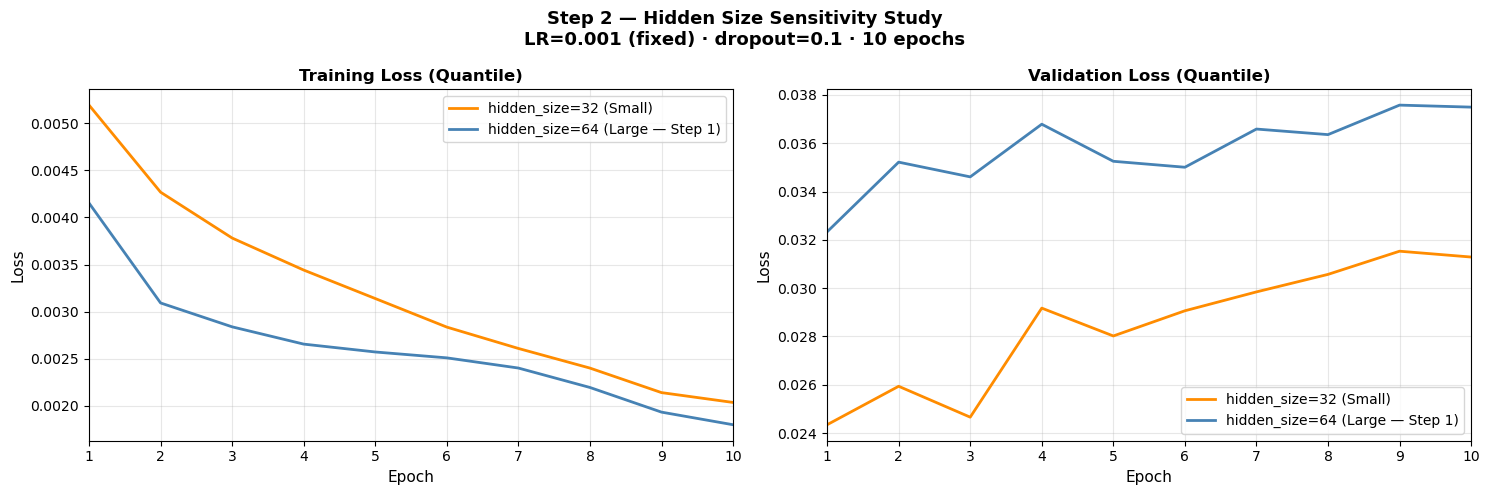

DECISION GUIDE — choose the hidden_size with the smoothest,
lowest Validation Loss. Larger = more capacity but slower.
hidden_size        Train Loss (ep.50)    Val Loss (ep.50)
----------------------------------------------------------
32 (Small)                     0.0020              0.0313  ← trained this step
64 (Large)                     0.0018              0.0375  ← reused from Step 1


In [58]:

# ── Step 2: Adjust Capacity — Hidden Size ─────────────────────────────────────
# Fixed LR = 0.001 (best from Step 1). Compare hidden_size=32 vs hidden_size=64.
# The hidden_size=64 curve is already stored in lr_study_results[0.001] from Step 1.

HS_STUDY_LR       = 0.001
HS_STUDY_EPOCHS   = 10
HS_STUDY_SIZES    = [32, 64]                  # 64 is reused from Step 1
HS_COLORS         = {32: "darkorange", 64: "steelblue"}
HS_LABELS         = {32: "hidden_size=32 (Small)", 64: "hidden_size=64 (Large — Step 1)"}

# ── Shared params (same as Step 1, only hidden_size varies) ───────────────────
HS_STUDY_BASE_PARAMS = dict(
    attention_head_size    = 4,
    dropout                = 0.1,
    hidden_continuous_size = 32,   # will be overridden for hidden_size=32 run
    output_size            = 7,
    log_interval           = -1,
    reduce_on_plateau_patience = 6,
)

# ── Train hidden_size=32 (hidden_size=64 already done in Step 1) ──────────────
hs_study_results = {}

# Reuse Step 1 result for hidden_size=64
hs_study_results[64] = {
    "train": lr_study_results[HS_STUDY_LR]["train"],
    "val":   lr_study_results[HS_STUDY_LR]["val"],
}

print(f"▶ hidden_size=32  (LR={HS_STUDY_LR})")
pl.seed_everything(42, workers=True)

model_hs32 = TemporalFusionTransformer.from_dataset(
    training_ds_lr,
    loss=QuantileLoss(),
    learning_rate=HS_STUDY_LR,
    hidden_size=32,
    hidden_continuous_size=16,     # kept proportional (half of hidden_size)
    **{k: v for k, v in HS_STUDY_BASE_PARAMS.items()
       if k not in ("hidden_continuous_size",)},
)

epoch_logger_hs32 = EpochLossLogger()

trainer_hs32 = pl.Trainer(
    max_epochs          = HS_STUDY_EPOCHS,
    enable_model_summary= False,
    enable_progress_bar = True,
    logger              = False,
    accelerator         = "auto",
    devices             = 1,
    callbacks           = [epoch_logger_hs32],
    gradient_clip_val   = 0.1,
    enable_checkpointing= False,
)
trainer_hs32.fit(model_hs32, train_dataloaders=train_loader_lr, val_dataloaders=val_loader_lr)

hs_study_results[32] = {
    "train": epoch_logger_hs32.train_losses,
    "val":   epoch_logger_hs32.val_losses,
}
t32 = epoch_logger_hs32.train_losses[-1] if epoch_logger_hs32.train_losses else float("nan")
v32 = epoch_logger_hs32.val_losses[-1]   if epoch_logger_hs32.val_losses   else float("nan")
print(f"  ✓ Epoch {HS_STUDY_EPOCHS} — Train Loss: {t32:.4f}  |  Val Loss: {v32:.4f}\n")

# ── Side-by-side convergence plot: hidden_size=32 vs hidden_size=64 ───────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    f"Step 2 — Hidden Size Sensitivity Study\n"
    f"LR={HS_STUDY_LR} (fixed) · dropout=0.1 · {HS_STUDY_EPOCHS} epochs",
    fontsize=13, fontweight="bold"
)

for hs in HS_STUDY_SIZES:
    data  = hs_study_results[hs]
    color = HS_COLORS[hs]
    label = HS_LABELS[hs]
    if data["train"]:
        axes[0].plot(range(1, len(data["train"]) + 1), data["train"],
                     color=color, linewidth=2, label=label)
    if data["val"]:
        axes[1].plot(range(1, len(data["val"]) + 1), data["val"],
                     color=color, linewidth=2, label=label)

for ax, title in zip(axes, ["Training Loss (Quantile)", "Validation Loss (Quantile)"]):
    ax.set_xlabel("Epoch", fontsize=11)
    ax.set_ylabel("Loss", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1, HS_STUDY_EPOCHS)

plt.tight_layout()
plt.show()

# ── Decision summary ──────────────────────────────────────────────────────────
t64 = hs_study_results[64]["train"][-1] if hs_study_results[64]["train"] else float("nan")
v64 = hs_study_results[64]["val"][-1]   if hs_study_results[64]["val"]   else float("nan")

print("=" * 65)
print("DECISION GUIDE — choose the hidden_size with the smoothest,")
print("lowest Validation Loss. Larger = more capacity but slower.")
print("=" * 65)
print(f"{'hidden_size':<15}  {'Train Loss (ep.50)':>20}  {'Val Loss (ep.50)':>18}")
print("-" * 58)
print(f"{'32 (Small)':<15}  {t32:>20.4f}  {v32:>18.4f}  ← trained this step")
print(f"{'64 (Large)':<15}  {t64:>20.4f}  {v64:>18.4f}  ← reused from Step 1")


### Step 3: Control Memory — Dropout

Seed set to 42


▶ dropout=0.3  (LR=0.001, hidden_size=32)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


...

  ✓ Epoch 10 — Train Loss: 0.0025  |  Val Loss: 0.0342

▶ dropout=0.5  (LR=0.001, hidden_size=32)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


  ✓ Epoch 10 — Train Loss: 0.0028  |  Val Loss: 0.0323



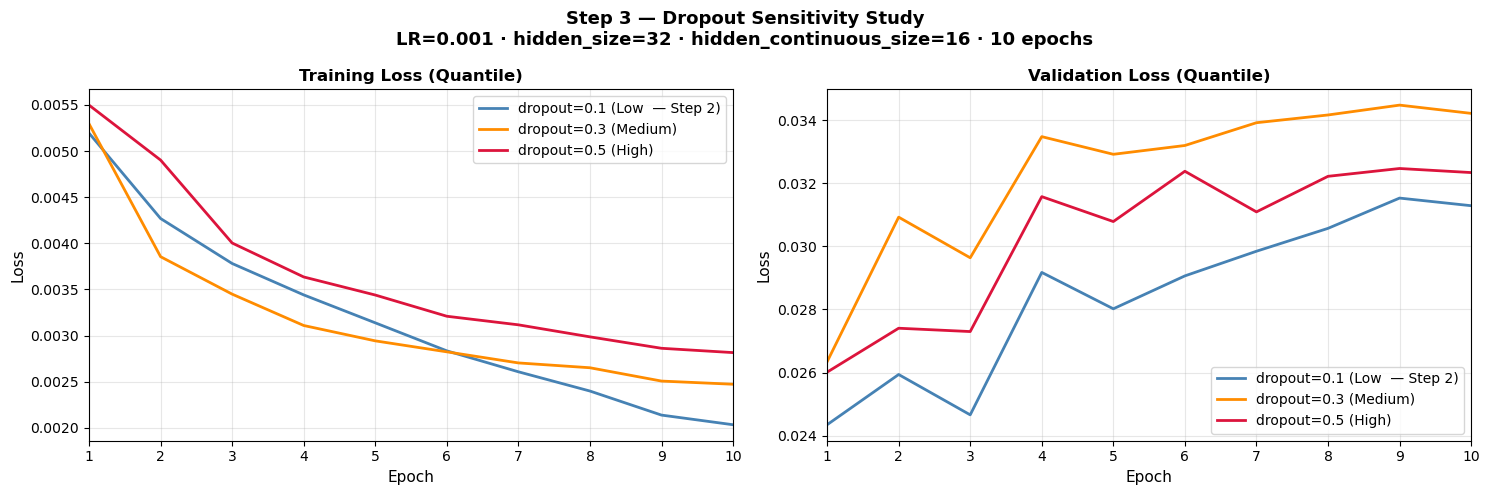

DECISION GUIDE — choose the dropout with the lowest, stable
Validation Loss. Higher dropout = more regularisation (less overfit).
dropout         Train Loss (ep.50)    Val Loss (ep.50)  Note
----------------------------------------------------------------------
0.1                         0.0020              0.0313  ← reused from Step 2
0.3                         0.0025              0.0342  
0.5                         0.0028              0.0323  


In [60]:

# ── Step 3: Control Memory — Dropout ──────────────────────────────────────────
# Fixed: LR=0.001, hidden_size=32, hidden_continuous_size=16
# Vary: dropout = 0.1 (reused from Step 2), 0.3, 0.5

DO_STUDY_LR          = 0.001
DO_STUDY_EPOCHS      = 10
DO_STUDY_DROPOUTS    = [0.1, 0.3, 0.5]
DO_COLORS            = {0.1: "steelblue", 0.3: "darkorange", 0.5: "crimson"}
DO_LABELS            = {
    0.1: "dropout=0.1 (Low  — Step 2)",
    0.3: "dropout=0.3 (Medium)",
    0.5: "dropout=0.5 (High)",
}

# ── Fixed model params shared across all dropout trials ───────────────────────
DO_FIXED_PARAMS = dict(
    hidden_size            = 32,
    hidden_continuous_size = 16,
    attention_head_size    = 4,
    output_size            = 7,
    log_interval           = -1,
    reduce_on_plateau_patience = 6,
)

# ── Storage — seed with Step 2 result for dropout=0.1 ─────────────────────────
do_study_results = {
    0.1: {
        "train": hs_study_results[32]["train"],
        "val":   hs_study_results[32]["val"],
    }
}

# ── Train dropout=0.3 and dropout=0.5 ─────────────────────────────────────────
for dropout_val in [0.3, 0.5]:
    print(f"▶ dropout={dropout_val}  (LR={DO_STUDY_LR}, hidden_size=32)")
    pl.seed_everything(42, workers=True)

    model_do = TemporalFusionTransformer.from_dataset(
        training_ds_lr,
        loss=QuantileLoss(),
        learning_rate=DO_STUDY_LR,
        dropout=dropout_val,
        **DO_FIXED_PARAMS,
    )

    epoch_logger_do = EpochLossLogger()

    trainer_do = pl.Trainer(
        max_epochs          = DO_STUDY_EPOCHS,
        enable_model_summary= False,
        enable_progress_bar = True,
        logger              = False,
        accelerator         = "auto",
        devices             = 1,
        callbacks           = [epoch_logger_do],
        gradient_clip_val   = 0.1,
        enable_checkpointing= False,
    )
    trainer_do.fit(model_do, train_dataloaders=train_loader_lr, val_dataloaders=val_loader_lr)

    do_study_results[dropout_val] = {
        "train": epoch_logger_do.train_losses,
        "val":   epoch_logger_do.val_losses,
    }
    t_do = epoch_logger_do.train_losses[-1] if epoch_logger_do.train_losses else float("nan")
    v_do = epoch_logger_do.val_losses[-1]   if epoch_logger_do.val_losses   else float("nan")
    print(f"  ✓ Epoch {DO_STUDY_EPOCHS} — Train Loss: {t_do:.4f}  |  Val Loss: {v_do:.4f}\n")

# ── Convergence plot: 3 dropout values × 2 panels ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    f"Step 3 — Dropout Sensitivity Study\n"
    f"LR={DO_STUDY_LR} · hidden_size=32 · hidden_continuous_size=16 · {DO_STUDY_EPOCHS} epochs",
    fontsize=13, fontweight="bold"
)

for do in DO_STUDY_DROPOUTS:
    data  = do_study_results[do]
    color = DO_COLORS[do]
    label = DO_LABELS[do]
    if data["train"]:
        axes[0].plot(range(1, len(data["train"]) + 1), data["train"],
                     color=color, linewidth=2, label=label)
    if data["val"]:
        axes[1].plot(range(1, len(data["val"]) + 1), data["val"],
                     color=color, linewidth=2, label=label)

for ax, title in zip(axes, ["Training Loss (Quantile)", "Validation Loss (Quantile)"]):
    ax.set_xlabel("Epoch", fontsize=11)
    ax.set_ylabel("Loss", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1, DO_STUDY_EPOCHS)

plt.tight_layout()
plt.show()

# ── Decision summary ───────────────────────────────────────────────────────────
print("=" * 70)
print("DECISION GUIDE — choose the dropout with the lowest, stable")
print("Validation Loss. Higher dropout = more regularisation (less overfit).")
print("=" * 70)
print(f"{'dropout':<12}  {'Train Loss (ep.50)':>20}  {'Val Loss (ep.50)':>18}  Note")
print("-" * 70)
for do in DO_STUDY_DROPOUTS:
    d  = do_study_results[do]
    t  = d["train"][-1] if d["train"] else float("nan")
    v  = d["val"][-1]   if d["val"]   else float("nan")
    note = "← reused from Step 2" if do == 0.1 else ""
    print(f"{do:<12}  {t:>20.4f}  {v:>18.4f}  {note}")


### Comparison after hypermeter training 

Seed set to 42



  Model 1 (LR=3e-3, ep=5)
  Product 2106 ... 

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=5` reached.


MAE(log)=0.0353
  Product 3304 ... 

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=5` reached.


...

MAE(log)=0.0308
  Product 8517 ... 

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=3` reached.


MAE(log)=0.0975
  Product 9404 ... 

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=3` reached.


MAE(log)=0.0765


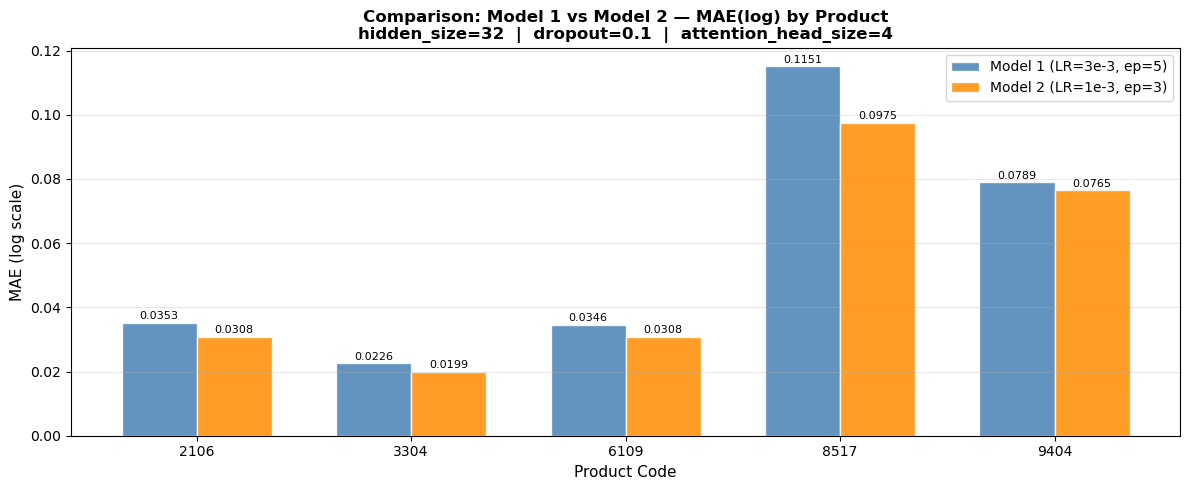


Product          Model 1 MAE(log)     Model 2 MAE(log)  Winner
-----------------------------------------------------------------
2106                       0.0353               0.0308  Model 2
3304                       0.0226               0.0199  Model 2
6109                       0.0346               0.0308  Model 2
8517                       0.1151               0.0975  Model 2
9404                       0.0789               0.0765  Model 2
Model 1 (LR=3e-3, ep=5) — Mean MAE(log): 0.0573
Model 2 (LR=1e-3, ep=3) — Mean MAE(log): 0.0511


In [61]:

# ── Comparison after hyperparameter tuning ────────────────────────────────────
# Model 1 (baseline): LR=3e-3, hidden_size=32, dropout=0.1, epochs=5
# Model 2 (tuned):    LR=1e-3, hidden_size=32, dropout=0.1, epochs=3
# All other params from Step 3: attention_head_size=4, hidden_continuous_size=16

COMP_CONFIGS = {
    "Model 1\n(LR=3e-3, ep=5)": {
        "tft_params": dict(
            learning_rate          = 3e-3,
            hidden_size            = 32,
            dropout                = 0.1,
            attention_head_size    = 4,
            hidden_continuous_size = 16,
            output_size            = 7,
            log_interval           = -1,
            reduce_on_plateau_patience = 6,
        ),
        "n_epochs": 5,
        "color": "steelblue",
    },
    "Model 2\n(LR=1e-3, ep=3)": {
        "tft_params": dict(
            learning_rate          = 1e-3,
            hidden_size            = 32,
            dropout                = 0.1,
            attention_head_size    = 4,
            hidden_continuous_size = 16,
            output_size            = 7,
            log_interval           = -1,
            reduce_on_plateau_patience = 6,
        ),
        "n_epochs": 3,
        "color": "darkorange",
    },
}

# ── Save and restore the original TFT globals ─────────────────────────────────
_saved_TFT_PARAMS   = TFT_PARAMS.copy()
_saved_TFT_N_EPOCHS = TFT_N_EPOCHS

# ── Train each configuration across all products ──────────────────────────────
comp_results = {}   # label -> {product_code -> mae_log}

for label, cfg in COMP_CONFIGS.items():
    short = label.replace("\n", " ")
    print(f"\n{'='*58}\n  {short}\n{'='*58}")

    # Temporarily override globals used by train_tft_product
    TFT_PARAMS   = cfg["tft_params"]
    TFT_N_EPOCHS = cfg["n_epochs"]

    pl.seed_everything(42, workers=True)
    mae_by_product = {}
    for prod in PRODUCTS:
        print(f"  Product {prod} ...", end=" ", flush=True)
        res = train_tft_product(prod)
        if res is not None:
            mae = res["metrics"]["mae_log"]
            mae_by_product[prod] = mae
            print(f"MAE(log)={mae:.4f}")
        else:
            mae_by_product[prod] = float("nan")
            print("skipped")
    comp_results[label] = mae_by_product

# Restore original globals
TFT_PARAMS   = _saved_TFT_PARAMS
TFT_N_EPOCHS = _saved_TFT_N_EPOCHS

# ── Grouped bar chart: MAE(log) by product, grouped by model ──────────────────
comp_labels = list(COMP_CONFIGS.keys())
comp_colors = [COMP_CONFIGS[l]["color"] for l in comp_labels]

x     = np.arange(len(PRODUCTS))
width = 0.35
offsets = [-width / 2, width / 2]

fig, ax = plt.subplots(figsize=(12, 5))

for i, (label, color) in enumerate(zip(comp_labels, comp_colors)):
    maes = [comp_results[label].get(p, float("nan")) for p in PRODUCTS]
    bars = ax.bar(x + offsets[i], maes, width,
                  label=label.replace("\n", " "),
                  color=color, alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, maes):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.0005,
                    f"{v:.4f}", ha="center", va="bottom", fontsize=8)

ax.set_xlabel("Product Code", fontsize=11)
ax.set_ylabel("MAE (log scale)", fontsize=11)
ax.set_title(
    "Comparison: Model 1 vs Model 2 — MAE(log) by Product\n"
    "hidden_size=32  |  dropout=0.1  |  attention_head_size=4",
    fontsize=12, fontweight="bold"
)
ax.set_xticks(x)
ax.set_xticklabels([str(p) for p in PRODUCTS], fontsize=10)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print(f"{'Product':<12} {'Model 1 MAE(log)':>20} {'Model 2 MAE(log)':>20}  Winner")
print("-" * 65)
for prod in PRODUCTS:
    m1 = comp_results[comp_labels[0]].get(prod, float("nan"))
    m2 = comp_results[comp_labels[1]].get(prod, float("nan"))
    if np.isnan(m1) and np.isnan(m2):
        winner = "—"
    elif np.isnan(m1):
        winner = "Model 2"
    elif np.isnan(m2):
        winner = "Model 1"
    else:
        winner = "Model 1" if m1 <= m2 else "Model 2"
    print(f"{prod:<12} {m1:>20.4f} {m2:>20.4f}  {winner}")

print("=" * 65)
for label in comp_labels:
    vals = [v for v in comp_results[label].values() if not np.isnan(v)]
    mean_mae = np.mean(vals) if vals else float("nan")
    print(f"{label.replace(chr(10), ' ')} — Mean MAE(log): {mean_mae:.4f}")


## Save Model and Training_ds to a file

In [63]:
import os
import torch
from pytorch_forecasting import TemporalFusionTransformer

# ── Model 2 hyperparameters ───────────────────────────────────────────────────
MODEL2_PARAMS = dict(
    learning_rate          = 1e-3,
    hidden_size            = 32,
    dropout                = 0.1,
    attention_head_size    = 4,
    hidden_continuous_size = 16,
    output_size            = 7,
    log_interval           = -1,
    reduce_on_plateau_patience = 6,
)
MODEL2_EPOCHS = 3
SAVE_DIR      = "saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Build one combined dataset across ALL products ────────────────────────────
print("Building combined dataset for all products ...")
df_all = df_model.copy()
df_all = df_all.sort_values([TIME_COL])

# Include product code in group_id so routes across different products are distinct
df_all["group_id"] = (
    df_all["Origin_Label"] + "||" +
    df_all["Destination_Label"] + "||" +
    df_all["Product_Code"].astype(str)
).astype(str)

# Single global time index anchored to the earliest year in the dataset
min_year_all     = int(df_all[TIME_COL].min())
df_all["time_idx"] = (df_all[TIME_COL] - min_year_all).astype(int)

# Drop series that are too short
slen         = df_all.groupby("group_id")["time_idx"].count()
valid_groups = slen[slen >= TFT_MIN_LEN].index
df_all       = df_all[df_all["group_id"].isin(valid_groups)].copy()

# Drop series with no post-split observations (nothing to validate against)
post_split       = df_all[df_all[TIME_COL] > split_year].groupby("group_id").size()
groups_with_test = post_split[post_split >= 1].index
df_all           = df_all[df_all["group_id"].isin(groups_with_test)].copy()

training_cutoff_all = int(df_all[df_all[TIME_COL] <= split_year]["time_idx"].max())

exclude = {TARGET, "group_id", "time_idx", TIME_COL,
           "Origin_Label", "Destination_Label", "Product_Code",
           "origin_enc", "dest_enc", "product_enc",
           "target_lag_1", "target_lag_2", "target_lag_3",
           "target_rolling_mean_3"}
real_covariates_all = [c for c in FEATURE_COLS if c in df_all.columns and c not in exclude]

df_train_all = df_all[df_all["time_idx"] <= training_cutoff_all].copy()
training_ds_all = TimeSeriesDataSet(
    df_train_all,
    time_idx               = "time_idx",
    target                 = TARGET,
    group_ids              = ["group_id"],
    min_encoder_length     = max(1, TFT_MAX_ENCODER // 2),
    max_encoder_length     = TFT_MAX_ENCODER,
    min_prediction_length  = TFT_MAX_PRED,
    max_prediction_length  = TFT_MAX_PRED,
    static_categoricals    = ["group_id"],
    time_varying_known_reals   = ["time_idx"],
    time_varying_unknown_reals = [TARGET] + real_covariates_all,
    target_normalizer      = GroupNormalizer(groups=["group_id"], transformation="softplus"),
    add_relative_time_idx  = True,
    add_target_scales      = True,
    add_encoder_length     = True,
    allow_missing_timesteps= True,
)
validation_ds_all = TimeSeriesDataSet.from_dataset(
    training_ds_all, df_all,
    predict=True, stop_randomization=True, allow_missing_timesteps=True,
)

print(f"  Groups (route × product): {df_all['group_id'].nunique()}")
print(f"  Training samples        : {len(training_ds_all)}")
print(f"  Validation samples      : {len(validation_ds_all)}")

train_loader_all = training_ds_all.to_dataloader(
    train=True, batch_size=TFT_BATCH_SIZE, num_workers=0, shuffle=True
)
val_loader_all = validation_ds_all.to_dataloader(
    train=False, batch_size=TFT_BATCH_SIZE, num_workers=0, shuffle=False
)

# ── Train ONE model on all products combined ──────────────────────────────────
print(f"\n▶ Training one Model 2 (all products combined, {MODEL2_EPOCHS} epochs) ...")
pl.seed_everything(42, workers=True)

model_m2_all = TemporalFusionTransformer.from_dataset(
    training_ds_all,
    loss=QuantileLoss(),
    **MODEL2_PARAMS,
)

ckpt_path_all = os.path.join(SAVE_DIR, "tft_model2_all_products.ckpt")

trainer_m2_all = pl.Trainer(
    max_epochs          = MODEL2_EPOCHS,
    enable_model_summary= False,
    enable_progress_bar = True,
    logger              = False,
    accelerator         = "auto",
    devices             = 1,
    gradient_clip_val   = 0.1,
    enable_checkpointing= False,
)
trainer_m2_all.fit(model_m2_all, train_dataloaders=train_loader_all, val_dataloaders=val_loader_all)

# Checkpoint (required by load_from_checkpoint)
trainer_m2_all.save_checkpoint(ckpt_path_all)

# Bundle: checkpoint path + fitted training_ds (carries the normalizer + schema)
bundle_path_all = os.path.join(SAVE_DIR, "tft_model2_all_products_bundle.pt")
torch.save({
    "model_ckpt":  ckpt_path_all,
    "training_ds": training_ds_all,
    "products":    PRODUCTS,
    "min_year":    min_year_all,
    "hparams":     MODEL2_PARAMS,
    "n_epochs":    MODEL2_EPOCHS,
}, bundle_path_all)

print(f"\n✓ Checkpoint : {ckpt_path_all}")
print(f"✓ Bundle     : {bundle_path_all}")

# ── Verify: reload bundle and predict without retraining ─────────────────────
print("\n── Verifying load ──")
bundle_loaded      = torch.load(bundle_path_all, weights_only=False)
training_ds_loaded = bundle_loaded["training_ds"]
model_loaded       = TemporalFusionTransformer.load_from_checkpoint(bundle_loaded["model_ckpt"])
model_loaded.eval()

# df_all already has the correct group_id / time_idx schema
val_ds_verify     = TimeSeriesDataSet.from_dataset(
    training_ds_loaded, df_all,
    predict=True, stop_randomization=True, allow_missing_timesteps=True,
)
val_loader_verify = val_ds_verify.to_dataloader(train=False, batch_size=64, num_workers=0)

preds = model_loaded.predict(
    val_loader_verify,
    mode="prediction",
    trainer_kwargs={"accelerator": "auto", "logger": False, "enable_progress_bar": False},
)
print(f"  ✓ Predictions shape: {preds.shape}  (no retraining)")
print(f"  First 5 predictions (log scale): {preds[:5, -1].tolist()}")


Building combined dataset for all products ...


Seed set to 42


  Groups (route × product): 25020
  Training samples        : 125100
  Validation samples      : 25020

▶ Training one Model 2 (all products combined, 3 epochs) ...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

`Trainer.fit` stopped: `max_epochs=3` reached.


`weights_only` was not set, defaulting to `False`.



✓ Checkpoint : saved_models\tft_model2_all_products.ckpt
✓ Bundle     : saved_models\tft_model2_all_products_bundle.pt

── Verifying load ──
  ✓ Predictions shape: torch.Size([25020, 1])  (no retraining)
  First 5 predictions (log scale): [0.07060234248638153, 0.06111682206392288, 0.2327730655670166, 0.6067565679550171, 0.09342741966247559]


## Save df_model to a parquet file 

In [78]:

SAVE_DIR = "saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

df_model_path = os.path.join(SAVE_DIR, "df_model.parquet")
df_model.to_parquet(df_model_path, index=False)

## Demo to Load model and Make a prediction of Year 2022

In [72]:
import numpy as np

# ── Step 1: Load bundle & model from disk ─────────────────────────────────────
print("Loading saved bundle ...")
bundle          = torch.load(bundle_path_all, weights_only=False)
tft_inf         = TemporalFusionTransformer.load_from_checkpoint(bundle["model_ckpt"])
tft_inf.eval()

training_ds_inf = bundle["training_ds"]
min_yr_inf      = bundle["min_year"]

print(f"  Checkpoint : {bundle['model_ckpt']}")
print(f"  Products   : {bundle['products']}")

# ── Step 2: Get groups the model was trained on ────────────────────────────────
known_groups = set(df_all["group_id"].unique())
print(f"  Known routes in model : {len(known_groups)}")

# ── Step 3: Build inference df with consistent group_id ───────────────────────
FORECAST_YEAR = 2022

df_inf = df_model.copy()
df_inf["group_id"] = (
    df_inf["Origin_Label"] + "||" +
    df_inf["Destination_Label"] + "||" +
    df_inf["Product_Code"].astype(str)
).astype(str)
df_inf[TIME_COL] = df_inf[TIME_COL].astype(int)

# ── Step 4: Pick a route known to the model with history ending at FORECAST_YEAR-1
DEMO_PRODUCT, DEMO_ROUTE = None, None
for p in PRODUCTS:
    grp_mask   = (df_inf["Product_Code"] == p) & (df_inf["group_id"].isin(known_groups))
    valid_mask = grp_mask & (df_inf[TIME_COL] == FORECAST_YEAR - 1)
    candidates = df_inf[valid_mask]["group_id"].unique()
    if len(candidates) > 0:
        DEMO_PRODUCT = p
        DEMO_ROUTE   = candidates[0]
        break

if DEMO_ROUTE is None:
    max_yr = int(df_inf[df_inf["group_id"].isin(known_groups)][TIME_COL].max())
    raise ValueError(
        f"No known route has history up to {FORECAST_YEAR - 1}. "
        f"Latest year in known routes: {max_yr}"
    )

origin, destination, _ = DEMO_ROUTE.split("||")
print(f"\n  Selected product : {DEMO_PRODUCT}")
print(f"  Selected route   : {origin}  →  {destination}")
print(f"  Forecasting year : {FORECAST_YEAR}")

# ── Step 5: Build inference dataframe + synthetic forecast row ─────────────────
df_demo = df_inf[df_inf["group_id"] == DEMO_ROUTE].copy()
df_demo["time_idx"] = (df_demo[TIME_COL] - min_yr_inf).astype(int)
df_demo = df_demo.sort_values("time_idx").reset_index(drop=True)

print(f"\n  Historical years for this route : {sorted(df_demo[TIME_COL].tolist())}")

# Append a synthetic row for FORECAST_YEAR.
# TimeSeriesDataSet rejects NaN targets even in predict mode, so we carry the
# last known target forward as a placeholder — the model ignores this value
# during inference; only the encoder context (prior years) drives the prediction.
last_row             = df_demo.iloc[[-1]].copy()
last_row[TIME_COL]   = FORECAST_YEAR
last_row["time_idx"] = int(FORECAST_YEAR - min_yr_inf)
# TARGET stays as the carried-forward value from iloc[-1] (already copied above)

df_demo = (
    pd.concat([df_demo, last_row], ignore_index=True)
    .sort_values("time_idx")
    .reset_index(drop=True)
)

# ── Step 6: Build inference TimeSeriesDataSet ──────────────────────────────────
demo_ds = TimeSeriesDataSet.from_dataset(
    training_ds_inf, df_demo,
    predict=True, stop_randomization=True, allow_missing_timesteps=True,
)
demo_loader = demo_ds.to_dataloader(train=False, batch_size=64, num_workers=0)

# ── Step 7: Predict ────────────────────────────────────────────────────────────
pred_median = tft_inf.predict(
    demo_loader,
    mode="prediction",
    trainer_kwargs={"accelerator": "auto", "logger": False, "enable_progress_bar": False},
)
median_log  = float(pred_median[-1, -1])
median_orig = float(np.expm1(median_log))

pred_q = tft_inf.predict(
    demo_loader,
    mode="quantiles",
    trainer_kwargs={"accelerator": "auto", "logger": False, "enable_progress_bar": False},
)
QUANTILE_NAMES = ["q10", "q20", "q30", "q50", "q70", "q80", "q90"]
q_log_vals = pred_q[-1, -1, :].tolist()

# ── Step 8: Display forecast ───────────────────────────────────────────────────
print(f"\n{'='*62}")
print(f"  TFT Forecast  |  {origin}  →  {destination}")
print(f"  Product Code : {DEMO_PRODUCT}   |   Forecast Year : {FORECAST_YEAR}")
print(f"{'='*62}")
print(f"  {'Quantile':<10} {'Log-scale':>12} {'Original scale':>16}")
print(f"  {'-'*42}")
for qname, qval in zip(QUANTILE_NAMES, q_log_vals):
    tag = "  ◄ median" if qname == "q50" else ""
    print(f"  {qname:<10} {qval:>12.4f} {np.expm1(qval):>16.2f}{tag}")

print(f"\n  (No ground truth for {FORECAST_YEAR} — this is a genuine out-of-sample forecast)")


Loading saved bundle ...
  Checkpoint : saved_models\tft_model2_all_products.ckpt
  Products   : [np.int64(2106), np.int64(3304), np.int64(6109), np.int64(8517), np.int64(9404)]
  Known routes in model : 25020

  Selected product : 2106
  Selected route   : Albania  →  French Polynesia
  Forecasting year : 2022

  Historical years for this route : [2016, 2017, 2018, 2019, 2020, 2021]

  TFT Forecast  |  Albania  →  French Polynesia
  Product Code : 2106   |   Forecast Year : 2022
  Quantile      Log-scale   Original scale
  ------------------------------------------
  q10              0.0248             0.03
  q20              0.0251             0.03
  q30              0.0255             0.03
  q50              0.0256             0.03  ◄ median
  q70              0.0264             0.03
  q80              0.0268             0.03
  q90              0.0278             0.03

  (No ground truth for 2022 — this is a genuine out-of-sample forecast)


## make a prediction on the following route of year 2021
raw data: "Afghanistan","Eswatini",6109,"T-shirts, singlets and other vests; knitted or crocheted",,,0.248,0.245,,
the following will demo how to predict 2021 of this product in this route

In [80]:
import os
import numpy as np
import pandas as pd

# Reuse the loaded model from the 2022 demo if it is already in memory.
# Fallback to disk only if that section has not been run in this kernel.
if "tft_inf" not in globals() or "training_ds_inf" not in globals() or "min_yr_inf" not in globals():
    print("Loaded model not found in memory; loading bundle from disk ...")
    bundle = torch.load(bundle_path_all, weights_only=False)
    tft_inf = TemporalFusionTransformer.load_from_checkpoint(bundle["model_ckpt"])
    tft_inf.eval()
    training_ds_inf = bundle["training_ds"]
    min_yr_inf = bundle["min_year"]
else:
    print("Using loaded TFT model from the 2022 demo section ...")

REQ_ORIGIN = "Afghanistan"
REQ_DESTINATION = "Eswatini"
REQ_PRODUCT = 6109
PREDICT_YEAR = 2021
CONTEXT_END_YEAR = PREDICT_YEAR - 1
REQ_GROUP_ID = f"{REQ_ORIGIN}||{REQ_DESTINATION}||{REQ_PRODUCT}"

# Optional: if the exact route is unseen by the loaded model, use the first known
# route with the same origin/product as a proxy instead of crashing.
USE_PROXY_IF_UNSEEN = True

# Load the saved model dataframe from disk and use it as the source of x inputs.
SAVE_DIR = "saved_models"
df_model_parquet_path = os.path.join(SAVE_DIR, "df_model.parquet")
if not os.path.exists(df_model_parquet_path):
    raise FileNotFoundError(
        f"Could not find {df_model_parquet_path}. Save df_model to parquet first."
    )

df_model_disk = pd.read_parquet(df_model_parquet_path).copy()
df_model_disk[TIME_COL] = df_model_disk[TIME_COL].astype(int)
df_model_disk["group_id"] = (
    df_model_disk["Origin_Label"] + "||" +
    df_model_disk["Destination_Label"] + "||" +
    df_model_disk["Product_Code"].astype(str)
).astype(str)

# This dataframe is now the canonical source for the 2021 x inputs.
df_inf = df_model_disk.copy()

# Routes known to the loaded model still come from the TFT training subset.
if "known_groups" not in globals():
    known_groups = set(df_all["group_id"].unique())

route_all = df_inf[df_inf["group_id"] == REQ_GROUP_ID].copy()
route_all = route_all.sort_values(TIME_COL).reset_index(drop=True)

print(f"Requested route : {REQ_ORIGIN} → {REQ_DESTINATION}")
print(f"Product code    : {REQ_PRODUCT}")
print(f"df_model source : {os.path.abspath(df_model_parquet_path)}")

if route_all.empty:
    raise ValueError(f"No rows found in df_model parquet for route {REQ_GROUP_ID}.")

requested_years = sorted(route_all[TIME_COL].astype(int).unique().tolist())
print(f"Requested route years : {requested_years}")

active_group_id = REQ_GROUP_ID
active_origin = REQ_ORIGIN
active_destination = REQ_DESTINATION
prediction_note = "Exact requested route"

if REQ_GROUP_ID not in known_groups:
    candidate_routes = df_inf[
        (df_inf["Product_Code"] == REQ_PRODUCT) &
        (df_inf["Origin_Label"] == REQ_ORIGIN) &
        (df_inf["group_id"].isin(known_groups))
    ][["Origin_Label", "Destination_Label", "Product_Code", "group_id"]].drop_duplicates()

    print("\nRequested route was not part of TFT training.")
    print("The loaded model cannot score an unseen route-level group_id exactly.")

    if candidate_routes.empty or not USE_PROXY_IF_UNSEEN:
        print("\nKnown routes for the same origin/product:")
        print(candidate_routes[["Origin_Label", "Destination_Label", "Product_Code"]].to_string(index=False))
        print("\nSet USE_PROXY_IF_UNSEEN = True to run a proxy prediction on one known route.")
        raise SystemExit("Stopped without prediction because exact route is unseen by the loaded model.")

    proxy_group_id = None
    for gid in candidate_routes["group_id"].tolist():
        tmp = df_inf[df_inf["group_id"] == gid]
        yrs = set(tmp[TIME_COL].astype(int).tolist())
        if CONTEXT_END_YEAR in yrs and PREDICT_YEAR in yrs:
            proxy_group_id = gid
            break
    if proxy_group_id is None:
        proxy_group_id = candidate_routes["group_id"].iloc[0]

    active_group_id = proxy_group_id
    active_origin, active_destination, _ = active_group_id.split("||")
    prediction_note = "Proxy route used because requested route is unseen by model"

    print(f"Using proxy route : {active_origin} → {active_destination}")
    print("Interpretation    : this is NOT a true prediction for Eswatini; it is only a proxy using the closest available support in the saved model.")

route_all = df_inf[df_inf["group_id"] == active_group_id].copy()
route_all = route_all.sort_values(TIME_COL).reset_index(drop=True)
available_years = sorted(route_all[TIME_COL].astype(int).unique().tolist())
print(f"Model route years : {available_years}")

if CONTEXT_END_YEAR not in available_years:
    raise ValueError(
        f"Cannot predict {PREDICT_YEAR} because the active route has no {CONTEXT_END_YEAR} row for encoder context. "
        f"Available years: {available_years}"
    )
if PREDICT_YEAR not in available_years:
    raise ValueError(
        f"No actual {PREDICT_YEAR} row exists for the active route, so comparison is not possible. "
        f"Available years: {available_years}"
    )

route_hist = route_all[route_all[TIME_COL] <= CONTEXT_END_YEAR].copy()
route_hist["time_idx"] = (route_hist[TIME_COL] - min_yr_inf).astype(int)
route_hist = route_hist.sort_values("time_idx").reset_index(drop=True)

if len(route_hist) < max(1, TFT_MAX_ENCODER // 2):
    raise ValueError(
        f"Not enough history to build a TFT encoder window. "
        f"Need at least {max(1, TFT_MAX_ENCODER // 2)} rows, found {len(route_hist)}."
    )

# Pull the 2021 x inputs directly from the saved df_model parquet.
actual_2021 = route_all[route_all[TIME_COL] == PREDICT_YEAR].iloc[0].copy()
placeholder_row = route_hist.iloc[[-1]].copy()
placeholder_row[TIME_COL] = PREDICT_YEAR
placeholder_row["time_idx"] = int(PREDICT_YEAR - min_yr_inf)

# Replace all non-target columns with the observed 2021 x inputs from parquet.
for col in route_all.columns:
    if col in placeholder_row.columns and col != TARGET:
        placeholder_row.iloc[0, placeholder_row.columns.get_loc(col)] = actual_2021[col]
placeholder_row.iloc[0, placeholder_row.columns.get_loc(TARGET)] = route_hist[TARGET].iloc[-1]

route_pred_df = (
    pd.concat([route_hist, placeholder_row], ignore_index=True)
    .sort_values("time_idx")
    .reset_index(drop=True)
)

demo_ds = TimeSeriesDataSet.from_dataset(
    training_ds_inf,
    route_pred_df,
    predict=True,
    stop_randomization=True,
    allow_missing_timesteps=True,
)
demo_loader = demo_ds.to_dataloader(train=False, batch_size=64, num_workers=0)

pred_median = tft_inf.predict(
    demo_loader,
    mode="prediction",
    trainer_kwargs={"accelerator": "auto", "logger": False, "enable_progress_bar": False},
)
pred_q = tft_inf.predict(
    demo_loader,
    mode="quantiles",
    trainer_kwargs={"accelerator": "auto", "logger": False, "enable_progress_bar": False},
)

pred_log = float(pred_median[-1, -1])
pred_orig = float(np.expm1(pred_log))
actual_log = float(actual_2021[TARGET])
actual_orig = float(np.expm1(actual_log))
q_log_vals = pred_q[-1, -1, :].tolist()
QUANTILE_NAMES = ["q10", "q20", "q30", "q50", "q70", "q80", "q90"]

print(f"\n{'='*72}")
print("TFT prediction for 2021 using loaded all-products model")
print(f"Requested route : {REQ_ORIGIN} → {REQ_DESTINATION}")
print(f"Model route     : {active_origin} → {active_destination}")
print(f"Product code    : {REQ_PRODUCT}")
print(f"Note            : {prediction_note}")
print(f"X input source  : {os.path.abspath(df_model_parquet_path)}")
print(f"Context used    : years {sorted(route_hist[TIME_COL].astype(int).tolist())}")
print(f"{'='*72}")
print(f"{'Quantile':<10} {'Log-scale':>12} {'Original scale':>16}")
print(f"{'-'*44}")
for qname, qval in zip(QUANTILE_NAMES, q_log_vals):
    tag = "  ◄ median" if qname == "q50" else ""
    print(f"{qname:<10} {qval:>12.4f} {np.expm1(qval):>16.2f}{tag}")

print(f"\n{'Actual 2021':<10} {actual_log:>12.4f} {actual_orig:>16.2f}")
print(f"{'Pred 2021':<10} {pred_log:>12.4f} {pred_orig:>16.2f}")
print(f"\nAbsolute error (original scale) : {abs(pred_orig - actual_orig):.2f}")
if actual_orig != 0:
    print(f"Relative error (%)              : {100 * abs(pred_orig - actual_orig) / actual_orig:.1f}%")


Using loaded TFT model from the 2022 demo section ...
Requested route : Afghanistan → Eswatini
Product code    : 6109
df_model source : g:\My Drive\NUS\IS5126\Final Project\saved_models\df_model.parquet
Requested route years : [2018, 2019]

Requested route was not part of TFT training.
The loaded model cannot score an unseen route-level group_id exactly.
Using proxy route : Afghanistan → Austria
Interpretation    : this is NOT a true prediction for Eswatini; it is only a proxy using the closest available support in the saved model.
Model route years : [2016, 2017, 2018, 2019, 2020, 2021]

TFT prediction for 2021 using loaded all-products model
Requested route : Afghanistan → Eswatini
Model route     : Afghanistan → Austria
Product code    : 6109
Note            : Proxy route used because requested route is unseen by model
X input source  : g:\My Drive\NUS\IS5126\Final Project\saved_models\df_model.parquet
Context used    : years [2016, 2017, 2018, 2019, 2020]
Quantile      Log-scale   

In [87]:
df_inf[(df_inf["Origin_Label"] == "Afghanistan") & (df_inf["Destination_Label"] == "Eswatini") & (df_inf["Product_Code"] == 6109)]

,Origin_Label,Destination_Label,Product_Code,Year,Source_CPI_Annual_average_growth_rate_Value,Destination_CPI_Annual_average_growth_rate_Value,Source_GDP_US_at_current_prices_in_millions_Value,Destination_GDP_US_at_current_prices_in_millions_Value,Source_GNI_US_dollars_at_current_prices_in_millions_Value,Destination_GNI_US_dollars_at_current_prices_in_millions_Value,lsbci,dist_km,fuel_vlsfo_avg,lsci_o,lsci_d,lsci_sum,lsci_gap,origin_teu,dest_teu,teu_log_product,origin_loaded_kt,origin_discharged_kt,dest_loaded_kt,dest_discharged_kt,trade_imbalance,origin_vessel_pct,dest_vessel_pct,fleet_supply,historical_mean_rate,historical_mean_rate_is_imputed,lsci_asymmetry,lsci_product,lsbci_per_km,trade_intensity,port_pressure,directional_imbalance,distance_lsci_interaction,distance_fleet_interaction,capacity_gap,trade_exists,post_covid,product_cat,y_log,origin_enc,dest_enc,product_enc,target_lag_1,target_lag_2,target_lag_3,target_rolling_mean_3,group_id
59,Afghanistan,Eswatini,6109,2018,0.63,4.82,18856.0,4647.0,18610.0,4345.0,0.3,7837.531,576.846774,140.435,87.1525,304.3775,141.5375,0.0,0.0,0.0,1388.0,6255.0,833.0,684.0,0.249887,0.0,0.0,0.0,0.2465,0,141.5375,11790.931625,0.000051,0.013647,0.031397,704.0,1801.13128,0.0,0.565166,1,0,2,0.221542,0,51,2,0.070458,0.069526,0.069526,0.072321,Afghanistan||Eswatini||6109
60,Afghanistan,Eswatini,6109,2019,2.30,2.60,19372.0,4617.0,19205.0,4018.0,0.3,7837.531,576.846774,140.435,87.1525,304.3775,141.5375,0.0,0.0,0.0,1482.0,9226.0,981.0,718.0,0.203410,0.0,0.0,0.0,0.2465,0,141.5375,11790.931625,0.000051,0.013647,0.031397,764.0,1801.13128,0.0,0.565166,1,0,2,0.219136,0,51,2,0.221542,0.069526,0.069526,0.221542,Afghanistan||Eswatini||6109


In [88]:
import numpy as np

# ── Step 1: Load bundle & model from disk ─────────────────────────────────────
print("Loading saved bundle ...")
bundle          = torch.load(bundle_path_all, weights_only=False)
tft_inf         = TemporalFusionTransformer.load_from_checkpoint(bundle["model_ckpt"])
tft_inf.eval()

training_ds_inf = bundle["training_ds"]
min_yr_inf      = bundle["min_year"]

print(f"  Checkpoint : {bundle['model_ckpt']}")
print(f"  Products   : {bundle['products']}")

# ── Step 2: Get groups the model was trained on ────────────────────────────────
known_groups = set(df_all["group_id"].unique())
print(f"  Known routes in model : {len(known_groups)}")

# ── Step 3: Build inference df with consistent group_id ───────────────────────
FORECAST_YEAR = 2020

df_inf = df_model.copy()
df_inf["group_id"] = (
    df_inf["Origin_Label"] + "||" +
    df_inf["Destination_Label"] + "||" +
    df_inf["Product_Code"].astype(str)
).astype(str)
df_inf[TIME_COL] = df_inf[TIME_COL].astype(int)

# ── Step 4: Pick a route known to the model with history ending at FORECAST_YEAR-1
DEMO_PRODUCT, DEMO_ROUTE = None, None
for p in PRODUCTS:
    grp_mask   = (df_inf["Product_Code"] == p) & (df_inf["group_id"].isin(known_groups))
    valid_mask = grp_mask & (df_inf[TIME_COL] == FORECAST_YEAR - 1)
    candidates = df_inf[valid_mask]["group_id"].unique()
    if len(candidates) > 0:
        DEMO_PRODUCT = p
        DEMO_ROUTE   = candidates[0]
        break

if DEMO_ROUTE is None:
    max_yr = int(df_inf[df_inf["group_id"].isin(known_groups)][TIME_COL].max())
    raise ValueError(
        f"No known route has history up to {FORECAST_YEAR - 1}. "
        f"Latest year in known routes: {max_yr}"
    )

origin, destination, _ = DEMO_ROUTE.split("||")
print(f"\n  Selected product : {DEMO_PRODUCT}")
print(f"  Selected route   : {origin}  →  {destination}")
print(f"  Forecasting year : {FORECAST_YEAR}")

# ── Step 5: Build inference dataframe + synthetic forecast row ─────────────────
df_demo = df_inf[df_inf["group_id"] == DEMO_ROUTE].copy()
df_demo["time_idx"] = (df_demo[TIME_COL] - min_yr_inf).astype(int)
df_demo = df_demo.sort_values("time_idx").reset_index(drop=True)

print(f"\n  Historical years for this route : {sorted(df_demo[TIME_COL].tolist())}")

# Append a synthetic row for FORECAST_YEAR.
# TimeSeriesDataSet rejects NaN targets even in predict mode, so we carry the
# last known target forward as a placeholder — the model ignores this value
# during inference; only the encoder context (prior years) drives the prediction.
last_row             = df_demo.iloc[[-1]].copy()
last_row[TIME_COL]   = FORECAST_YEAR
last_row["time_idx"] = int(FORECAST_YEAR - min_yr_inf)
# TARGET stays as the carried-forward value from iloc[-1] (already copied above)

df_demo = (
    pd.concat([df_demo, last_row], ignore_index=True)
    .sort_values("time_idx")
    .reset_index(drop=True)
)

# ── Step 6: Build inference TimeSeriesDataSet ──────────────────────────────────
demo_ds = TimeSeriesDataSet.from_dataset(
    training_ds_inf, df_demo,
    predict=True, stop_randomization=True, allow_missing_timesteps=True,
)
demo_loader = demo_ds.to_dataloader(train=False, batch_size=64, num_workers=0)

# ── Step 7: Predict ────────────────────────────────────────────────────────────
pred_median = tft_inf.predict(
    demo_loader,
    mode="prediction",
    trainer_kwargs={"accelerator": "auto", "logger": False, "enable_progress_bar": False},
)
median_log  = float(pred_median[-1, -1])
median_orig = float(np.expm1(median_log))

pred_q = tft_inf.predict(
    demo_loader,
    mode="quantiles",
    trainer_kwargs={"accelerator": "auto", "logger": False, "enable_progress_bar": False},
)
QUANTILE_NAMES = ["q10", "q20", "q30", "q50", "q70", "q80", "q90"]
q_log_vals = pred_q[-1, -1, :].tolist()

# ── Step 8: Display forecast ───────────────────────────────────────────────────
print(f"\n{'='*62}")
print(f"  TFT Forecast  |  {origin}  →  {destination}")
print(f"  Product Code : {DEMO_PRODUCT}   |   Forecast Year : {FORECAST_YEAR}")
print(f"{'='*62}")
print(f"  {'Quantile':<10} {'Log-scale':>12} {'Original scale':>16}")
print(f"  {'-'*42}")
for qname, qval in zip(QUANTILE_NAMES, q_log_vals):
    tag = "  ◄ median" if qname == "q50" else ""
    print(f"  {qname:<10} {qval:>12.4f} {np.expm1(qval):>16.2f}{tag}")

print(f"\n  (No ground truth for {FORECAST_YEAR} — this is a genuine out-of-sample forecast)")


Loading saved bundle ...
  Checkpoint : saved_models\tft_model2_all_products.ckpt
  Products   : [np.int64(2106), np.int64(3304), np.int64(6109), np.int64(8517), np.int64(9404)]
  Known routes in model : 25020

  Selected product : 2106
  Selected route   : Albania  →  French Polynesia
  Forecasting year : 2020

  Historical years for this route : [2016, 2017, 2018, 2019, 2020, 2021]

  TFT Forecast  |  Albania  →  French Polynesia
  Product Code : 2106   |   Forecast Year : 2020
  Quantile      Log-scale   Original scale
  ------------------------------------------
  q10              0.0249             0.03
  q20              0.0252             0.03
  q30              0.0256             0.03
  q50              0.0257             0.03  ◄ median
  q70              0.0264             0.03
  q80              0.0269             0.03
  q90              0.0279             0.03

  (No ground truth for 2020 — this is a genuine out-of-sample forecast)
